# Variáveis globais e parâmetros da análise

Esta célula documenta as configurações usadas por todas as análises do notebook. Para alterar o comportamento, modifique apenas a célula seguinte e execute novamente o notebook.

- `MIN_QUESTAO_RESPOSTAS`: mínimo de respostas para uma questão entrar na análise filtrada.
- `PC3_MIN_OCCURRENCES`: mínimo de ocorrências acumuladas para um PC³ ser analisado; o padrão é 50.
- `TOP_N_PC3`: limita a quantidade de PC³ após o filtro de ocorrência. `None` significa usar todos os PC³ que passaram no mínimo.
- `MIN_CORRELATION_OBSERVATIONS`: mínimo de observações válidas para calcular uma correlação.
- `TOP_MISCONCEPTIONS`: limite opcional das figuras demográficas; `None` usa todos os PC³ aprovados pelo filtro de ocorrências.
- `OUTPUT_DIR` contém as entradas e arquivos intermediários; `RESULTS_DIR` contém somente os resultados finais.
- `PC3_MAP` e `traducao_metricas` traduzem os códigos das colunas para nomes usados nos gráficos e tabelas.

Todas as leituras e escritas textuais do notebook usam explicitamente `encoding="utf-8"`.


In [54]:
# ============================================================
# CONFIGURAÇÕES GLOBAIS DO NOTEBOOK
# ============================================================
from pathlib import Path
import json
import os
import numpy as np

# Diretórios: entradas/intermediários em output; resultados finais em output/resultados.
OUTPUT_DIR = Path("output")
DATASETS_DIR = Path("../DataSets")
RESULTS_DIR = OUTPUT_DIR / "resultados"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Arquivos de entrada e referências das etapas anteriores.
MODULOS_PATH = OUTPUT_DIR / "mapeamento_provas_questoes.json"
QUESTIONS_PATH = OUTPUT_DIR / "dataset_analise_questoes.csv"
MISCONCEPTIONS_PATH = OUTPUT_DIR / "misconceptions_detalhado_por_usuario.csv"
REFERENCES_PATH = Path("../Etapa_2/output/referencias_processamento.json")
EXECUTIONS_PATH = Path("../Etapa_4/codebench-analytics-full/output/metrics/executions_by_student.csv")
ACTIONS_PATH = Path("../Etapa_4/codebench-analytics-full/output/metrics/actions_by_student.csv")
USUARIOS_PATH = REFERENCES_PATH
USER_DATA_PATH = REFERENCES_PATH
OUTPUT_PATH = RESULTS_DIR / "metricas_execucao_por_estudante_questao.csv"
METRICAS_INDIVIDUAIS_PATH = RESULTS_DIR / "metricas_individuais_por_estudante.csv"

# Filtros da análise de questões e PC³.
MIN_QUESTAO_RESPOSTAS = 16
# Parâmetros editoriais usados no texto metodológico do artigo.
# O tamanho dos dados é calculado automaticamente a partir da pasta DataSets.
NUMERO_TURMAS = None  # calculado dinamicamente no manifesto da Etapa 2
PC3_MIN_OCCURRENCES = 0
TOP_N_PC3 = None  # None = todos acima de PC3_MIN_OCCURRENCES; ou um inteiro, como 10.
MIN_CORRELATION_OBSERVATIONS = 5
TOP_MISCONCEPTIONS = None  # None = todos os PC³ que passam PC3_MIN_OCCURRENCES; inteiro = limita os mais frequentes
ALPHA = 0.05  # nível de significância após ajuste de múltiplos testes

# Mapeamento completo dos códigos PC³ presentes no CSV.
PC3_MAP = {code: code for code in (
    'A2', 'A3', 'A4', 'A5', 'B4', 'B6', 'B8', 'B9', 'B10', 'B11', 'B12',
    'C1', 'C2', 'C3', 'C4', 'C8', 'D4', 'E1', 'E2', 'G4', 'G5', 'H1'
)}
PC3_COLUNAS_BASE = list(PC3_MAP)

# Tradução das métricas usadas nas correlações e nos relatórios.
traducao_metricas = {
    'taxa_acerto': 'taxa de acerto', 'num_submissoes': 'submissões',
    'taxa_aceitacao': 'taxa de aceitação', 'num_testes': 'testes',
    'num_consultas': 'consultas', 'num_erros_lgcs': 'erros lógicos',
    'num_errors_stx': 'erros sintaxe', 'num_erros': 'erros totais',
    'num_eventos': 'eventos totais', 'num_eventos_del': 'eventos deleção',
    'tempo_implementacao': 'tempo implementação',
    'qtd_alteracoes_codigo': 'alterações código', 'discriminacao': 'discriminação',
}
METRICAS_POSITIVAS = {'taxa_acerto', 'taxa_aceitacao', 'discriminacao'}
METRICAS_DECIMAIS = {'taxa_acerto', 'taxa_aceitacao', 'discriminacao'}
PADRAO_NOTA = r"[-+]?\d+(?:[.,]\d+)?"


def interpretar_rho(rho):
    """Classifica a força da correlação de Spearman para os relatórios."""
    if rho is None:
        return 'sem correlação'
    valor = abs(float(rho))
    if valor >= 0.70:
        return 'forte'
    if valor >= 0.50:
        return 'moderada'
    if valor >= 0.30:
        return 'fraca'
    return 'muito fraca ou nula'


def benjamini_hochberg(p_values):
    """Retorna p-valores ajustados pelo procedimento de Benjamini-Hochberg."""
    p = np.asarray(p_values, dtype=float)
    adjusted = np.full(p.shape, np.nan, dtype=float)
    valid = np.isfinite(p)
    if not np.any(valid):
        return adjusted
    values = np.clip(p[valid], 0.0, 1.0)
    order = np.argsort(values)
    ordered = values[order]
    m = len(ordered)
    ranks = np.arange(1, m + 1, dtype=float)
    corrected = ordered * m / ranks
    corrected = np.minimum.accumulate(corrected[::-1])[::-1]
    corrected = np.clip(corrected, 0.0, 1.0)
    restored = np.empty_like(corrected)
    restored[order] = corrected
    adjusted[valid] = restored
    return adjusted


# 1 - Caracterização da Amostra

In [55]:
from pathlib import Path
import json
import csv

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def carregar_estrutura_completa():
    with MODULOS_PATH.open('r', encoding='utf-8') as f:
        return json.load(f)


def contar_questoes_totais(estrutura):
    """Questões únicas da base geral de assessments mantida pela Etapa 2."""
    questoes = set()
    for provas in estrutura.get('mapeamento_provas', {}).values():
        for prova_data in provas.values():
            for turma_info in prova_data.values():
                info = turma_info.get('info', {})
                for questoes_lista in info.get('exercises', {}).values():
                    questoes.update(str(q) for q in questoes_lista)
    return len(questoes)


def contar_turmas_referencias(data, ids_usuarios=None):
    """Conta escopos/turmas unicos registrados no manifesto da Etapa 2.

    A Etapa 2 registra cada raiz de usuario como um caminho relativo, normalmente
    no formato ``ano-semestre/turma/users/usuario``. A turma e identificada pelos
    dois primeiros componentes do caminho (periodo, id da turma), evitando contar
    usuarios, assessments ou questoes como turmas.
    """
    escopos = set()
    ids_usuarios = None if ids_usuarios is None else {str(x) for x in ids_usuarios}
    for usuario in data.get('users', []):
        if ids_usuarios is not None and str(usuario.get('id')) not in ids_usuarios:
            continue
        for raiz in usuario.get('roots', []) or []:
            partes = [str(p) for p in Path(str(raiz)).parts if str(p) not in ('', '.')]
            # Formato: dataset/periodo/turma/users/aluno.
            # A turma é periodo + ID da pasta imediatamente antes de users.
            if len(partes) >= 3:
                escopos.add((partes[1], partes[2]))
        # Compatibilidade com manifestos que registram o escopo diretamente.
        for chave in ('scope', 'class_scope', 'turma', 'class_name'):
            valor = usuario.get(chave)
            if valor not in (None, ''):
                escopos.add((str(valor),))
    if not escopos:
        for assessment in data.get('assessments', []):
            for chave in ('scope', 'class_scope', 'turma', 'class_name'):
                valor = assessment.get(chave)
                if valor not in (None, ''):
                    escopos.add((str(valor),))
    return len(escopos)

def _primeiro_valor(registro, chaves, padrao=None):
    for chave in chaves:
        valor = registro.get(chave)
        if valor not in (None, ''):
            return valor
    return padrao


def construir_mapa_auditoria_amostra(data, questoes_filtradas, estudantes_filtrados):
    """Constrói um mapa auditável da amostra final filtrada.

    O mapa preserva caminhos absolutos, associa usuários às turmas, vincula
    assessments às questões e registra os códigos por questão/assessment. Ele
    não altera os manifestos originais.
    """
    questoes_ids = {id_questao(row) for row in questoes_filtradas if id_questao(row)}
    usuarios_filtrados = {str(x) for x in estudantes_filtrados}
    assessments = {}
    for item in data.get('assessments', []):
        aid = str(_primeiro_valor(item, ('id', 'assessment_id', 'assessment'), ''))
        if not aid:
            continue
        qids = {str(q) for q in item.get('question_ids', item.get('questions', []))}
        assessments[aid] = {
            'assessment_id': aid,
            'titulo': _primeiro_valor(item, ('title', 'assessment_title', 'name'), ''),
            'tipo': str(_primeiro_valor(item, ('type', 'assessment_type'), '')).lower(),
            'grupo_tp': _primeiro_valor(item, ('grupo_tp', 'tp_group', 'group', 'tag', 'label'), None),
            'questoes': sorted(qids & questoes_ids, key=str),
            'questoes_manifesto': sorted(qids, key=str),
        }
    turma_map = {}
    for user in data.get('users', []):
        uid = str(user.get('id', ''))
        if uid not in usuarios_filtrados:
            continue
        for raiz in user.get('roots', []) or []:
            caminho = (Path(data['_source_root']) / str(raiz)).resolve()
            partes = [str(x) for x in Path(str(raiz)).parts if str(x) not in ('', '.')]
            # Formato esperado: dataset/periodo/turma/users/aluno.
            # Exemplo: cb_dataset_2016_1_v1.81/2016-1/111/users/1082
            if len(partes) < 3:
                continue
            periodo = partes[1]
            id_turma = partes[2]
            turma_id = f'{periodo}/{id_turma}'
            caminho_turma = caminho.parents[1] if len(caminho.parents) > 1 else caminho
            registro = turma_map.setdefault(turma_id, {
                'turma_id': turma_id,
                'periodo': periodo,
                'id_turma': id_turma,
                'caminho_absoluto': str(caminho_turma),
                'alunos': {},
                'assessments': {},
                'questoes': {},
                'codigos': 0,
            })
            registro['alunos'].setdefault(uid, {'id': uid, 'caminho_absoluto': str(caminho)})
            for item in user.get('files', {}).get('codes', []) or []:
                rel = str(item.get('path', ''))
                caminho_codigo = (Path(data['_source_root']) / rel).resolve()
                nome = caminho_codigo.stem
                partes_nome = nome.split('_')
                aid = str(_primeiro_valor(item, ('assessment_id', 'assessment'), partes_nome[0] if partes_nome else ''))
                qid = str(_primeiro_valor(item, ('question_id', 'question', 'questao'), partes_nome[1] if len(partes_nome) > 1 else ''))
                if qid not in questoes_ids or aid not in assessments:
                    continue
                if assessments[aid].get('tipo') not in ('exam', ''):
                    continue
                registro['codigos'] += 1
                registro['assessments'].setdefault(aid, {
                    **{k: v for k, v in assessments[aid].items() if k not in ('questoes', 'questoes_manifesto')},
                    'grupo_tp': assessments[aid].get('grupo_tp'),
                    'questoes': {},
                })
                qreg = registro['assessments'][aid]['questoes'].setdefault(qid, {'questao': qid, 'codigos': 0, 'arquivos': []})
                qreg['codigos'] += 1
                qreg['arquivos'].append(str(caminho_codigo))
                registro['questoes'].setdefault(qid, {'questao': qid, 'assessments': [], 'codigos': 0})['codigos'] += 1
                if aid not in registro['questoes'][qid]['assessments']:
                    registro['questoes'][qid]['assessments'].append(aid)
    for turma in turma_map.values():
        turma['alunos'] = sorted(turma['alunos'].values(), key=lambda x: x['id'])
        turma['assessments'] = sorted(turma['assessments'].values(), key=lambda x: x['assessment_id'])
        turma['questoes'] = sorted(turma['questoes'].values(), key=lambda x: x['questao'])
    por_questao = {}
    for turma in turma_map.values():
        for q in turma['questoes']:
            item = por_questao.setdefault(q['questao'], {'questao': q['questao'], 'assessments': [], 'turmas': [], 'codigos': 0})
            item['codigos'] += q['codigos']
            item['turmas'].append(turma['turma_id'])
            for aid in q['assessments']:
                if aid not in item['assessments']:
                    item['assessments'].append(aid)
    questoes_verificadas = []
    por_tp = {}
    for qid in sorted(questoes_ids, key=str):
        refs = [a for a in assessments.values() if qid in a['questoes'] and a.get('tipo') in ('exam', '')]
        questoes_verificadas.append({
            'questao': qid,
            'encontrada_em_assessments_exam': bool(refs),
            'assessments': [{
                'assessment_id': a['assessment_id'],
                'titulo': a['titulo'],
                'grupo_tp': a['grupo_tp'],
                'tipo': a['tipo'],
            } for a in refs],
        })
        for a in refs:
            chave = a['grupo_tp'] or 'sem_tag_tp'
            por_tp.setdefault(chave, {'grupo_tp': chave, 'assessments': [], 'questoes': []})
            if a['assessment_id'] not in por_tp[chave]['assessments']:
                por_tp[chave]['assessments'].append(a['assessment_id'])
            if qid not in por_tp[chave]['questoes']:
                por_tp[chave]['questoes'].append(qid)
    return {
        'criterio': 'questões com 16 ou mais respostas; assessments exam mantidos pela Etapa 2',
        'questoes_filtradas': sorted(questoes_ids, key=str),
        'quantidade_questoes_filtradas': len(questoes_ids),
        'quantidade_alunos_filtrados': len(usuarios_filtrados),
        'turmas': sorted(turma_map.values(), key=lambda x: x['turma_id']),
        'quantidade_turmas': len(turma_map),
        'questoes_verificadas': questoes_verificadas,
        'questoes_sem_assessment_exam': [q['questao'] for q in questoes_verificadas if not q['encontrada_em_assessments_exam']],
        'assessments_por_grupo_tp': sorted(por_tp.values(), key=lambda x: x['grupo_tp']),
        'questoes_mapeadas': sorted(por_questao.values(), key=lambda x: x['questao']),
        'quantidade_codigos_mapeados': sum(x['codigos'] for x in por_questao.values()),
        'observacao': 'Cada caminho foi convertido para absoluto com Path.resolve(); nenhum arquivo original foi alterado.',
    }


def carregar_base_geral_exam():
    """Conta a base geral diretamente do manifesto filtrado da Etapa 2."""
    if not REFERENCES_PATH.exists():
        return set(), set(), 0
    data = json.loads(REFERENCES_PATH.read_text(encoding='utf-8'))
    assessments = [a for a in data.get('assessments', [])
                   if str(a.get('type', '')).strip().lower() == 'exam']
    questoes = {str(q) for a in assessments for q in a.get('question_ids', [])}
    estudantes = {str(u.get('id')) for u in data.get('users', []) if u.get('id') is not None}
    codigos = sum(len(u.get('files', {}).get('codes', [])) for u in data.get('users', []))
    return questoes, estudantes, codigos


def carregar_datasets_analise():
    """Carrega as tabelas da Etapa 5 e normaliza a coluna de respostas."""
    questoes = []
    estudantes = set()
    if QUESTIONS_PATH.exists():
        with QUESTIONS_PATH.open('r', encoding='utf-8') as f:
            questoes = list(csv.DictReader(f))
    if MISCONCEPTIONS_PATH.exists():
        with MISCONCEPTIONS_PATH.open('r', encoding='utf-8') as f:
            for row in csv.DictReader(f):
                if row.get('usuario'):
                    estudantes.add(str(row['usuario']))
    return questoes, estudantes


def valor_respostas(row):
    for coluna in ('respostas', 'total_responses', 'num_respostas'):
        valor = row.get(coluna)
        if valor not in (None, ''):
            try:
                return int(float(valor))
            except (TypeError, ValueError):
                return 0
    return 0


def id_questao(row):
    return str(row.get('question') or row.get('questao') or row.get('id') or '')


def contar_estudantes_filtrados(questoes_filtradas):
    ids_questoes = {id_questao(row) for row in questoes_filtradas}
    estudantes = set()
    if MISCONCEPTIONS_PATH.exists():
        with MISCONCEPTIONS_PATH.open('r', encoding='utf-8') as f:
            for row in csv.DictReader(f):
                if id_questao(row) in ids_questoes and row.get('usuario'):
                    estudantes.add(str(row['usuario']))
    return estudantes


def main():
    print("=" * 70)
    print("LEVANTAMENTO DE INFORMAÇÕES — BASE GERAL E FILTRO 16+")
    print("=" * 70)
    print("\n PERÍODO DO LEVANTAMENTO:")
    print("   • Ano/Semestre Inicial: 2016/1")
    print("   • Ano/Semestre Final: 2024/1")
    print("   • Exclusões: 2020-ERE, 2020/1, 2020/2")
    print("   • Assessments: somente os assessments mantidos pela Etapa 2 (exam/TP)")

    try:
        estrutura = carregar_estrutura_completa()
        questoes_estrutura = contar_questoes_totais(estrutura)
    except FileNotFoundError:
        print(f"\n Arquivo não encontrado: {MODULOS_PATH}")
        questoes_estrutura = 0

    questoes_gerais_set, estudantes_gerais, codigos_gerais = carregar_base_geral_exam()
    manifesto_referencias = json.loads(REFERENCES_PATH.read_text(encoding='utf-8')) if REFERENCES_PATH.exists() else {}
    turmas_gerais = contar_turmas_referencias(manifesto_referencias)
    if turmas_gerais == 0 and NUMERO_TURMAS is not None:
        turmas_gerais = int(NUMERO_TURMAS)
    print(f"   • Turmas/escopos únicos calculados no manifesto: {turmas_gerais}")
    if not questoes_gerais_set:
        # Compatibilidade com execuções antigas sem o manifesto da Etapa 2.
        questoes_gerais_set = set(str(q) for q in range(questoes_estrutura))
    questoes, estudantes_csv = carregar_datasets_analise()
    questoes_filtradas = [row for row in questoes if valor_respostas(row) >= MIN_QUESTAO_RESPOSTAS]
    estudantes_filtrados = contar_estudantes_filtrados(questoes_filtradas)
    if not estudantes_gerais:
        estudantes_gerais = estudantes_csv
    if not codigos_gerais:
        codigos_gerais = sum(valor_respostas(row) for row in questoes)
    codigos_filtrados = sum(valor_respostas(row) for row in questoes_filtradas)
    turmas_filtradas = contar_turmas_referencias(manifesto_referencias, estudantes_filtrados)
    # Resolve a raiz física aqui, antes da chamada de main(), pois a função
    # carregar_referencias é definida posteriormente no notebook.
    manifesto_auditoria = dict(manifesto_referencias)
    raiz_manifesto = Path(manifesto_auditoria.get('source_root', '.'))
    if not raiz_manifesto.is_absolute():
        raiz_manifesto = (REFERENCES_PATH.parent / raiz_manifesto).resolve()
    manifesto_auditoria['_source_root'] = str(raiz_manifesto)
    mapa_auditoria_amostra = construir_mapa_auditoria_amostra(
        manifesto_auditoria, questoes_filtradas, estudantes_filtrados
    )
    mapa_auditoria_path = RESULTS_DIR / 'amostra_artigo_mapa_auditoria.json'
    mapa_auditoria_path.write_text(
        json.dumps(mapa_auditoria_amostra, ensure_ascii=False, indent=2), encoding='utf-8'
    )
    print(f"Mapa de auditoria da amostra salvo em: {mapa_auditoria_path}")

    print("\n" + "=" * 70)
    print("DADOS GERAIS — assessments/questões de exam mantidos pela Etapa 2")
    print("=" * 70)
    print(f"   • Questões únicas na base geral (exam): {len(questoes_gerais_set)}")
    print(f"   • Estudantes na base geral: {len(estudantes_gerais)}")
    print(f"   • Códigos analisados na base geral: {codigos_gerais}")
    print(f"   • Turmas na base geral: {turmas_gerais}")

    print("\n" + "=" * 70)
    print("DADOS FILTRADOS — questões com 16 ou mais estudantes")
    print("=" * 70)
    print(f"   • Questões filtradas (16+): {len(questoes_filtradas)}")
    print(f"   • Estudantes filtrados: {len(estudantes_filtrados)}")
    print(f"   • Códigos analisados filtrados: {codigos_filtrados}")
    print(f"   • Turmas filtradas: {turmas_filtradas}")
    print("\n   Observação: estudantes e códigos filtrados são recalculados somente para as questões 16+.")

    # Persiste o contexto amostral usado no artigo, separando base geral e filtro 16+.
    contexto_levantamento = {
        "periodo": {
            "ano_semestre_inicial": "2016/1",
            "ano_semestre_final": "2024/1",
            "exclusoes": ["2020-ERE", "2020/1", "2020/2"]
        },
        "criterios": {
            "assessments": "somente assessments mantidos pela Etapa 2 (exam/TP)",
            "tipo_assessment": "exam",
            "minimo_respostas_por_questao": MIN_QUESTAO_RESPOSTAS
        },
        "base_geral": {
            "questoes_unicas": int(len(questoes_gerais_set)),
            "estudantes": int(len(estudantes_gerais)),
            "codigos_analisados": int(codigos_gerais),
            "turmas": int(turmas_gerais)
        },
        "base_filtrada": {
            "questoes_com_minimo_de_respostas": int(len(questoes_filtradas)),
            "estudantes": int(len(estudantes_filtrados)),
            "codigos_analisados": int(codigos_filtrados),
            "turmas": int(turmas_filtradas)
        },
        "observacao": "Estudantes e códigos filtrados são recalculados somente para questões com o mínimo de respostas definido."
    }
    # Calcula o tamanho total real da pasta DataSets, em GB decimais.
    def calcular_tamanho_pasta_gb(caminho):
        caminho = Path(caminho)
        total_bytes = sum(arquivo.stat().st_size for arquivo in caminho.rglob('*')
                          if arquivo.is_file()) if caminho.exists() else 0
        return total_bytes / 1_000_000_000, total_bytes

    datasets_gb, datasets_bytes = calcular_tamanho_pasta_gb(DATASETS_DIR)
    # Lista bruta de valores usada para montar o texto do artigo.
    amostra_bruta = {
        "dados_totais_gb": round(float(datasets_gb), 2),
        "dados_totais_bytes": int(datasets_bytes),
        # O artigo descreve a amostra final: somente questões com 16+ respostas.
        "questoes_resolvidas": int(len(questoes_filtradas)),
        "estudantes_distintos": int(len(estudantes_filtrados)),
        "codigos_produzidos": int(codigos_filtrados),
        "turmas": int(mapa_auditoria_amostra["quantidade_turmas"]),
        "ambiente": "ambiente controlado de laboratório",
        "supervisao": "sob supervisão de um docente ou de um monitor",
        "criterio_assessments": f"assessments mantidos pela Etapa 2 (exam/TP), questões com {MIN_QUESTAO_RESPOSTAS}+ respostas",
        "periodo": "2016/1 a 2024/1",
        "exclusoes": ["2020-ERE", "2020/1", "2020/2"]
    }
    def formatar_inteiro_artigo(valor):
        """Formata milhares com ponto sem alterar a pontuação da frase."""
        return f"{int(valor):,}".replace(",", ".")

    texto_amostra_artigo = (
        f"A amostra final compreendeu {amostra_bruta['dados_totais_gb']:g} gigabytes de dados totais, "
        f"com {formatar_inteiro_artigo(amostra_bruta['questoes_resolvidas'])} questões resolvidas por "
        f"{formatar_inteiro_artigo(amostra_bruta['estudantes_distintos'])} estudantes distintos, que produziram um total de "
        f"{formatar_inteiro_artigo(amostra_bruta['codigos_produzidos'])} códigos em {amostra_bruta['ambiente']}, "
        f"sob supervisão de um docente ou de um monitor, sendo estes distribuídos em "
        f"{formatar_inteiro_artigo(amostra_bruta['turmas'])} turmas."
    )
    amostra_bruta['texto_artigo'] = texto_amostra_artigo
    amostra_bruta_json = RESULTS_DIR / "amostra_artigo_bruta.json"
    amostra_artigo_txt = RESULTS_DIR / "amostra_artigo_texto.txt"
    amostra_bruta_json.write_text(json.dumps(amostra_bruta, ensure_ascii=False, indent=2), encoding='utf-8')
    amostra_artigo_txt.write_text(texto_amostra_artigo + "\n", encoding='utf-8')
    print(f"Lista bruta da amostra salva em: {amostra_bruta_json}")
    print(f"Texto pronto para o artigo salvo em: {amostra_artigo_txt}")

    contexto_levantamento["amostra_artigo_bruta"] = amostra_bruta

    contexto_json = RESULTS_DIR / "levantamento_informacoes.json"
    contexto_txt = RESULTS_DIR / "levantamento_informacoes.txt"
    contexto_json.write_text(json.dumps(contexto_levantamento, ensure_ascii=False, indent=2), encoding="utf-8")
    linhas_contexto = [
        "LEVANTAMENTO DE INFORMAÇÕES — BASE GERAL E FILTRO 16+",
        "",
        "PERÍODO DO LEVANTAMENTO:",
        "  • Ano/Semestre Inicial: 2016/1",
        "  • Ano/Semestre Final: 2024/1",
        "  • Exclusões: 2020-ERE, 2020/1, 2020/2",
        "  • Assessments: somente os assessments mantidos pela Etapa 2 (exam/TP)",
        "",
        f"  • Tamanho total da pasta DataSets: {datasets_gb:.2f} GB ({datasets_bytes:,} bytes)".replace(',', '.'),
        "DADOS GERAIS — assessments/questões de exam mantidos pela Etapa 2",
        f"  • Questões únicas na base geral (exam): {len(questoes_gerais_set)}",
        f"  • Estudantes na base geral: {len(estudantes_gerais)}",
        f"  • Códigos analisados na base geral: {codigos_gerais}",
        f"  • Turmas na base geral: {turmas_gerais}",
        "",
        f"DADOS FILTRADOS — questões com {MIN_QUESTAO_RESPOSTAS} ou mais estudantes",
        f"  • Questões filtradas ({MIN_QUESTAO_RESPOSTAS}+): {len(questoes_filtradas)}",
        f"  • Estudantes filtrados: {len(estudantes_filtrados)}",
        f"  • Códigos analisados filtrados: {codigos_filtrados}",
        f"  • Turmas filtradas: {turmas_filtradas}",
        "",
        "Observação: estudantes e códigos filtrados são recalculados somente para as questões filtradas."
    ]
    contexto_txt.write_text("\n".join(linhas_contexto) + "\n", encoding="utf-8")
    print(f"\nContexto amostral salvo em: {contexto_json}")
    print(f"Resumo legível salvo em: {contexto_txt}")
    print("=" * 70)

if __name__ == "__main__":
    main()

from pathlib import Path


def carregar_referencias(path):
    references_path = Path(path).resolve()
    data = json.loads(references_path.read_text(encoding='utf-8'))
    source_root = Path(data['source_root'])
    if not source_root.is_absolute():
        source_root = (references_path.parent / source_root).resolve()
    data['_source_root'] = str(source_root)
    data['_references_path'] = str(references_path)
    return data


def iterar_arquivos_usuario(data, user_id, kind, suffix=None):
    source_root = Path(data['_source_root'])
    for record in data.get('users', []):
        if str(record.get('id')) != str(user_id):
            continue
        for item in record.get('files', {}).get(kind, []):
            path = source_root / item['path']
            if path.is_file() and (suffix is None or path.name.endswith(suffix)):
                yield path



LEVANTAMENTO DE INFORMAÇÕES — BASE GERAL E FILTRO 16+

 PERÍODO DO LEVANTAMENTO:
   • Ano/Semestre Inicial: 2016/1
   • Ano/Semestre Final: 2024/1
   • Exclusões: 2020-ERE, 2020/1, 2020/2
   • Assessments: somente os assessments mantidos pela Etapa 2 (exam/TP)
   • Turmas/escopos únicos calculados no manifesto: 112
Mapa de auditoria da amostra salvo em: output/resultados/amostra_artigo_mapa_auditoria.json

DADOS GERAIS — assessments/questões de exam mantidos pela Etapa 2
   • Questões únicas na base geral (exam): 1187
   • Estudantes na base geral: 2982
   • Códigos analisados na base geral: 39957
   • Turmas na base geral: 112

DADOS FILTRADOS — questões com 16 ou mais estudantes
   • Questões filtradas (16+): 770
   • Estudantes filtrados: 2855
   • Códigos analisados filtrados: 29449
   • Turmas filtradas: 112

   Observação: estudantes e códigos filtrados são recalculados somente para as questões 16+.
Lista bruta da amostra salva em: output/resultados/amostra_artigo_bruta.json
Text

# 2 - Análise dos PC³

INICIANDO ANÁLISE DE PC³s
ℹ️ Analisando todos os 22 PC³s com ocorrências.

📊 Gerando gráfico de frequências de PC³s...


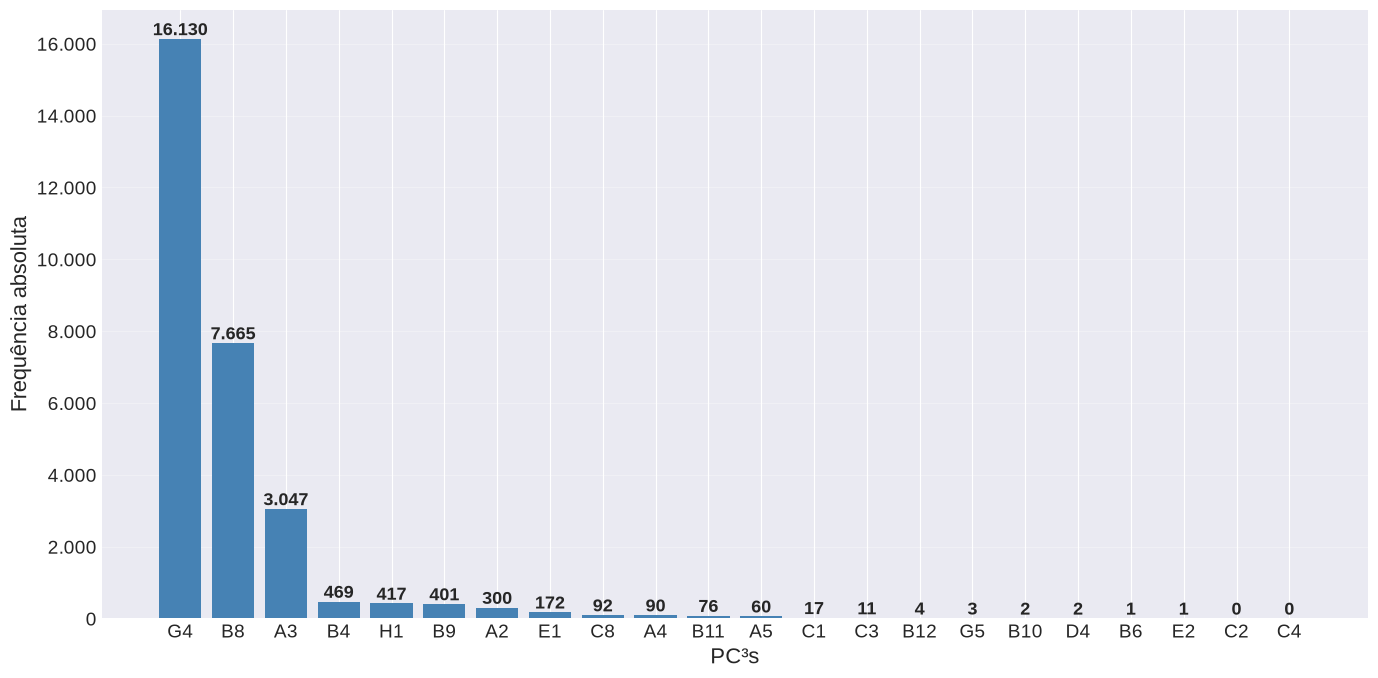


📊 Gerando gráfico de misconception por questão...
⚠️ Coluna 'misconception' não encontrada no dataset.

🔥 Gerando mapa de calor de correlações entre PC³s...


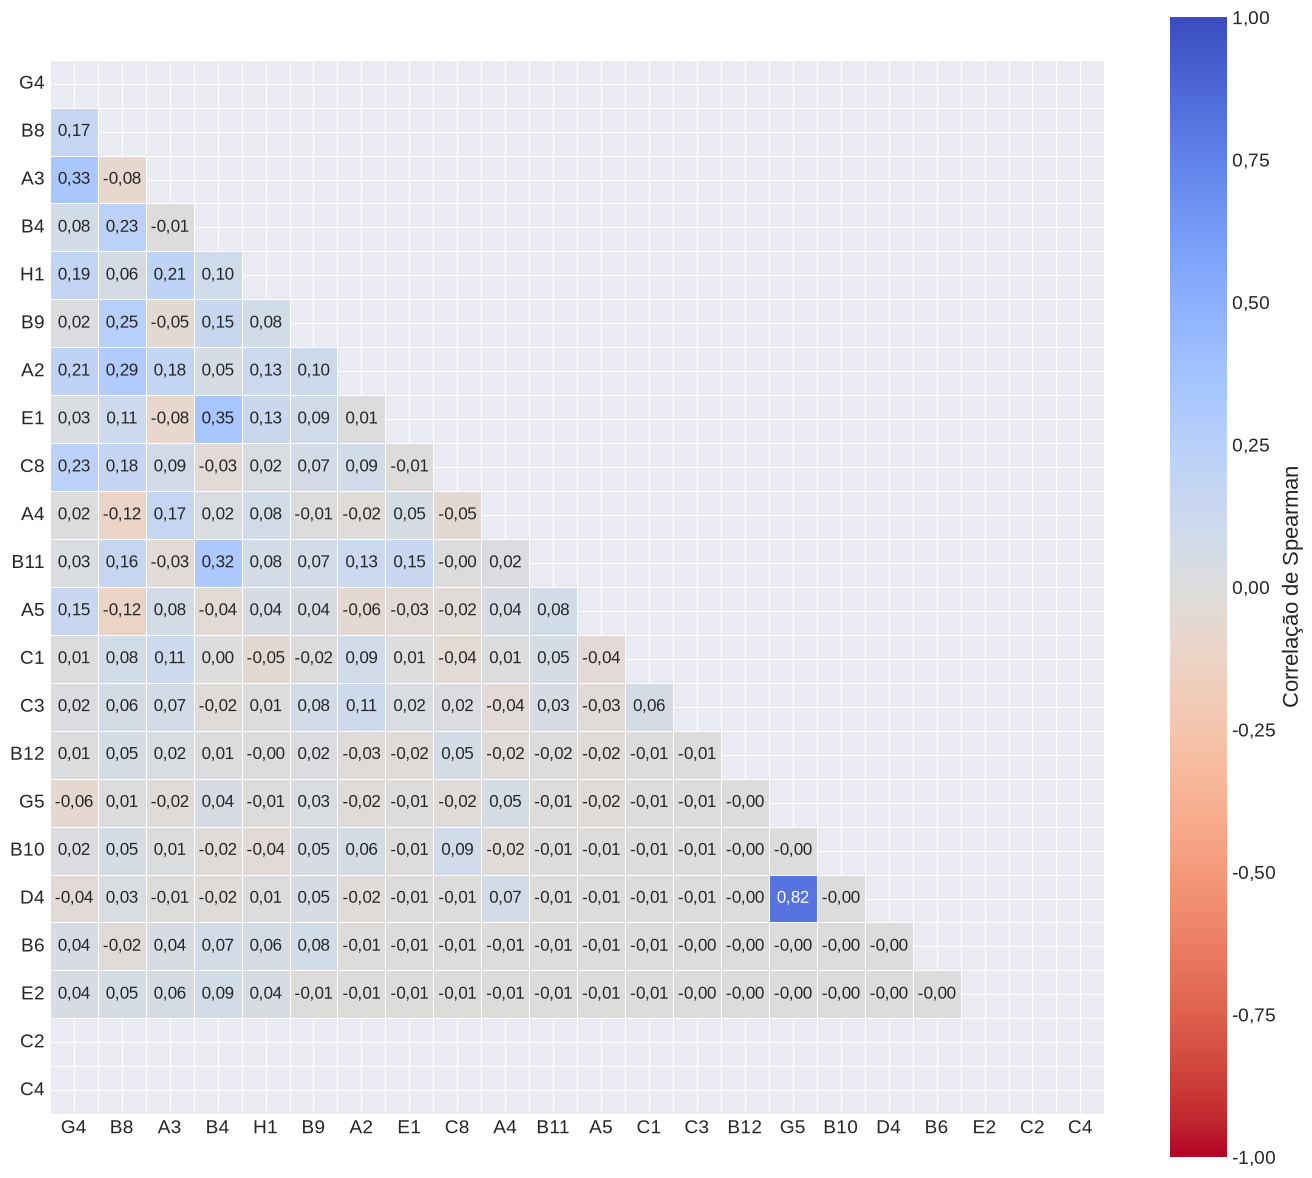


✓ Matriz de correlação gerada com sucesso!


,G4,B8,A3,B4,H1,B9,A2,E1,C8,A4,...,C1,C3,B12,G5,B10,D4,B6,E2,C2,C4
G4,1.000000,0.171395,0.329682,0.082919,0.187801,0.018829,0.210852,0.025631,0.228983,0.015523,...,0.009191,0.017500,0.011264,-0.064005,0.018838,-0.037102,0.040504,0.040504,NaN,NaN
B8,0.171395,1.000000,-0.081539,0.229620,0.057820,0.251031,0.292203,0.113626,0.178341,-0.118328,...,0.082683,0.057708,0.050343,0.008733,0.050655,0.026489,-0.022331,0.053200,NaN,NaN
A3,0.329682,-0.081539,1.000000,-0.006120,0.205400,-0.050821,0.182345,-0.078129,0.088996,0.168703,...,0.112848,0.070446,0.023692,-0.023373,0.010865,-0.014853,0.035775,0.061340,NaN,NaN
B4,0.082919,0.229620,-0.006120,1.000000,0.099225,0.149736,0.048075,0.348447,-0.033874,0.024772,...,0.000434,-0.021637,0.013493,0.035015,-0.022368,-0.022368,0.074352,0.085859,NaN,NaN
H1,0.187801,0.057820,0.205400,0.099225,1.000000,0.084281,0.126695,0.133372,0.024139,0.084705,...,-0.046891,0.013009,-0.004637,-0.008550,-0.037268,0.008169,0.061354,0.037881,NaN,NaN
B9,0.018829,0.251031,-0.050821,0.149736,0.084281,1.000000,0.103424,0.086143,0.066175,-0.005060,...,-0.015313,0.076513,0.017772,0.029079,0.046081,0.046081,0.079951,-0.014825,NaN,NaN
A2,0.210852,0.292203,0.182345,0.048075,0.126695,0.103424,1.000000,0.011923,0.085177,-0.021330,...,0.087762,0.106990,-0.025743,-0.022279,0.058612,-0.018179,-0.012846,-0.012846,NaN,NaN
E1,0.025631,0.113626,-0.078129,0.348447,0.133372,0.086143,0.011923,1.000000,-0.013641,0.050015,...,0.005546,0.024245,-0.016684,-0.014440,-0.011782,-0.011782,-0.008326,-0.008326,NaN,NaN
C8,0.228983,0.178341,0.088996,-0.033874,0.024139,0.066175,0.085177,-0.013641,1.000000,-0.047822,...,-0.039991,0.016461,0.054871,-0.016646,0.091081,-0.013582,-0.009598,-0.009598,NaN,NaN
A4,0.015523,-0.118328,0.168703,0.024772,0.084705,-0.005060,-0.021330,0.050015,-0.047822,1.000000,...,0.013533,-0.035960,-0.022654,0.051905,-0.015998,0.071528,-0.011305,-0.011305,NaN,NaN


In [56]:
from pathlib import Path
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import numpy as np
import locale

# Configurar locale para formatação brasileira
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')
except:
    pass

# --- CONFIGURAÇÕES GERAIS ---

# Configurações de fonte global
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Mapeamento de Colunas para Nomes Legíveis

# Lista base (será filtrada dinamicamente)

def formatar_numero(valor):
    """Formata número com separador de milhares (.) e decimais com vírgula"""
    if valor >= 1000:
        return f"{int(valor):,}".replace(',', '.')
    return str(int(valor))

def formatar_decimal(valor):
    """Formata decimal com vírgula"""
    return f"{valor:.2f}".replace('.', ',')

def carregar_dados():
    """Carrega os dados do CSV e trata colunas inexistentes"""
    try:
        df = pd.read_csv(QUESTIONS_PATH)
        # Garante que todas as colunas de interesse existam no DF (preenche com 0 se faltar)
        for col in PC3_COLUNAS_BASE:
            if col not in df.columns:
                df[col] = 0
        return df
    except FileNotFoundError:
        print(f"❌ Erro: Arquivo '{QUESTIONS_PATH}' não encontrado.")
        return None

def obter_colunas_ordenadas(df, top_n=TOP_N_PC3):
    """
    1. Calcula a frequência total.
    2. Remove colunas zeradas (ex: A4, H1).
    3. Ordena do mais frequente para o menos frequente.
    4. Retorna a lista de colunas cortada pelo top_n.
    """
    totais = {}
    
    # Calcula totais
    for col in PC3_COLUNAS_BASE:
        soma = df[col].sum()
        totais[col] = soma

    # Filtra quem tem 0 ocorrências (Remove A4 e H1 automaticamente se estiverem vazios)
    totais_ativos = {k: v for k, v in totais.items() if v >= PC3_MIN_OCCURRENCES}
    
    # Identifica quem foi removido
    removidos = set(PC3_COLUNAS_BASE) - set(totais_ativos.keys())
    if removidos:
        nomes_removidos = [PC3_MAP[c] for c in removidos]
        print(f"⚠️ PC³s vazios removidos da análise de correlação: {', '.join(nomes_removidos)}")

    # Ordena dicionário por valor (decrescente)
    ordenados = sorted(totais_ativos.items(), key=lambda x: x[1], reverse=True)
    
    # Pega apenas as chaves (nomes das colunas)
    colunas_ordenadas = [item[0] for item in ordenados]
    
    # Aplica o corte top_n se solicitado
    if top_n and top_n < len(colunas_ordenadas):
        print(f"ℹ️ Selecionando os Top {top_n} PC³s mais frequentes.")
        colunas_ordenadas = colunas_ordenadas[:top_n]
    else:
        print(f"ℹ️ Analisando todos os {len(colunas_ordenadas)} PC³s com ocorrências.")
        
    return colunas_ordenadas, totais

def plotar_frequencia(totais, colunas_ordenadas):
    """Plota gráfico de barras seguindo a ordem definida"""
    
    nomes = [PC3_MAP[col] for col in colunas_ordenadas]
    valores = [totais[col] for col in colunas_ordenadas]
    
    fig, ax = plt.subplots(figsize=(14, 7))
    bars = ax.bar(nomes, valores, color='steelblue')
    
    # Adiciona valores no topo com formatação brasileira
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                formatar_numero(height),
                ha='center', va='bottom', fontsize=13, fontweight='bold')
    
    ax.set_xlabel('PC³s', fontsize=16)
    ax.set_ylabel('Frequência absoluta', fontsize=16)
    #ax.set_title('PC³s mais frequentes', fontsize=18, fontweight='bold')
    plt.xticks(rotation=0, ha='center')  # Nomes retos e centralizados
    
    # Formata eixo Y com separador de milhares
    from matplotlib.ticker import FuncFormatter
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_numero(x)))
    
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plotar_misconception(df, colunas_ordenadas):
    """Plota gráfico de misconception por questão (em azul)"""
    
    # Verifica se a coluna 'misconception' existe
    if 'misconception' not in df.columns:
        print("⚠️ Coluna 'misconception' não encontrada no dataset.")
        return
    
    # Agrupa por questão e soma misconceptions
    if 'questao' in df.columns:
        misc_por_questao = df.groupby('questao')['misconception'].sum().sort_values(ascending=False)
    elif 'id' in df.columns:
        misc_por_questao = df.groupby('id')['misconception'].sum().sort_values(ascending=False)
    else:
        print("⚠️ Coluna 'questao' ou 'id' não encontrada.")
        return
    
    # Limita aos top 15 para melhor visualização
    top_questoes = misc_por_questao.head(15)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    bars = ax.bar(range(len(top_questoes)), top_questoes.values, color='steelblue')
    
    # Adiciona valores no topo
    for i, (bar, val) in enumerate(zip(bars, top_questoes.values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                formatar_numero(val),
                ha='center', va='bottom', fontsize=13, fontweight='bold')
    
    ax.set_xlabel('questão', fontsize=16)
    ax.set_ylabel('frequência de misconception', fontsize=16)
    ax.set_title('misconception por questão', fontsize=18, fontweight='bold')
    ax.set_xticks(range(len(top_questoes)))
    plt.xticks(range(len(top_questoes)), top_questoes.index, rotation=0, ha='center')
    
    # Formata eixo Y com separador de milhares
    from matplotlib.ticker import FuncFormatter
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_numero(x)))
    
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def calcular_e_plotar_correlacao(df, colunas_ordenadas):
    """
    Calcula correlação apenas para as colunas selecionadas e ordenadas.
    """
    # Filtra apenas questões relevantes (respostas >= 16, se coluna existir)
    if 'respostas' in df.columns:
        df_corr = df[df['respostas'] >= MIN_QUESTAO_RESPOSTAS].copy()
    else:
        df_corr = df.copy()

    # Seleciona subconjunto de dados JÁ ORDENADO por frequência
    df_subset = df_corr[colunas_ordenadas]
    
    # Renomeia para nomes curtos (C1, B4...) para o gráfico ficar bonito
    df_subset.columns = [PC3_MAP[col] for col in colunas_ordenadas]
    
    # Calcula Spearman
    corr_df = df_subset.corr(method='spearman')
    
    # Plotagem com fonte maior
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Máscara para triângulo superior
    mask = np.triu(np.ones_like(corr_df, dtype=bool))
    
    # Cria anotações formatadas com vírgula
    annot_data = corr_df.map(lambda x: formatar_decimal(x))
    
    # MUDANÇA: inverte o colormap - agora azul é positivo e vermelho é negativo
    heatmap = sns.heatmap(
        corr_df,
        mask=mask,
        annot=annot_data,
        fmt='',
        cmap='coolwarm_r',  # INVERTIDO: adiciona _r para reverter as cores
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Correlação de Spearman'},
        ax=ax,
        annot_kws={'fontsize': 12}
    )
    
    # Formata a barra de cores com vírgula nos decimais
    from matplotlib.ticker import FuncFormatter
    colorbar = heatmap.collections[0].colorbar
    colorbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_decimal(x)))
    
    #ax.set_title('matriz de correlação de PC³s (ordenada por frequência)',              fontsize=18, fontweight='bold', pad=20)
    
    # Ajusta labels para ficarem retos e centralizados
    plt.xticks(rotation=0, ha='center')
    plt.yticks(rotation=0, va='center')
    
    plt.tight_layout()
    plt.show()
    
    return corr_df

def gerar_relatorio(top_n=TOP_N_PC3):
    """
    Função Principal de Controle.
    
    Parâmetros:
      top_n (int ou None): Número de PC³s a analisar. 
                           Ex: 10 para os top 10, None para todos.
    """
    print("=" * 60)
    print("INICIANDO ANÁLISE DE PC³s")
    print("=" * 60)
    
    df = carregar_dados()
    if df is None: return

    # 1. Processamento e Ordenação
    colunas_finais, totais_brutos = obter_colunas_ordenadas(df, top_n=top_n)
    
    if not colunas_finais:
        print("Nenhum dado encontrado para gerar relatórios.")
        return

    # 2. Plotar Frequências de PC³s (Barras)
    print("\n📊 Gerando gráfico de frequências de PC³s...")
    plotar_frequencia(totais_brutos, colunas_finais)
    
    # 3. Plotar Misconception por Questão (Barras Azuis)
    print("\n📊 Gerando gráfico de misconception por questão...")
    plotar_misconception(df, colunas_finais)
    
    # 4. Correlação (Heatmap)
    print("\n🔥 Gerando mapa de calor de correlações entre PC³s...")
    corr_df = calcular_e_plotar_correlacao(df, colunas_finais)
    
    # 5. Exibir informação
    print("\n✓ Matriz de correlação gerada com sucesso!")
    print("=" * 60)
    
    return corr_df


# VERSÃO NOTEBOOK - Chama a função diretamente
gerar_relatorio(top_n=TOP_N_PC3)  # top_n para a quantidade de PC³s a analisar

# 3 - Análise das métricas de dificuldade

ANÁLISE DAS MÉTRICAS DE DIFICULDADE

1. Carregando dados...
   Total de questões no arquivo: 770

2. Métricas de dificuldade identificadas: 13
   MD1: taxa_acerto → taxa de acerto
   MD2: num_submissoes → submissões
   MD3: taxa_aceitacao → taxa de aceitação
   MD4: num_testes → testes
   MD5: num_consultas → consultas
   MD6: num_erros_lgcs → erros lógicos
   MD7: num_errors_stx → erros sintaxe
   MD8: num_erros → erros totais
   MD9: num_eventos → eventos totais
   MD10: num_eventos_del → eventos deleção
   MD11: tempo_implementacao → tempo implementação
   MD12: qtd_alteracoes_codigo → alterações código
   MD13: discriminacao → discriminação

3. Filtrando questões com 16 ou mais respostas...
   Questões com 16+ respostas: 679
   Questões excluídas: 91

4. Calculando estatísticas descritivas...

TABELA: Medidas de tendência central e dispersão das métricas de dificuldade
Questões com 16 ou mais respostas
            Métrica   n Média Desvio-padrão    Min Mediana   Max
     taxa de ac

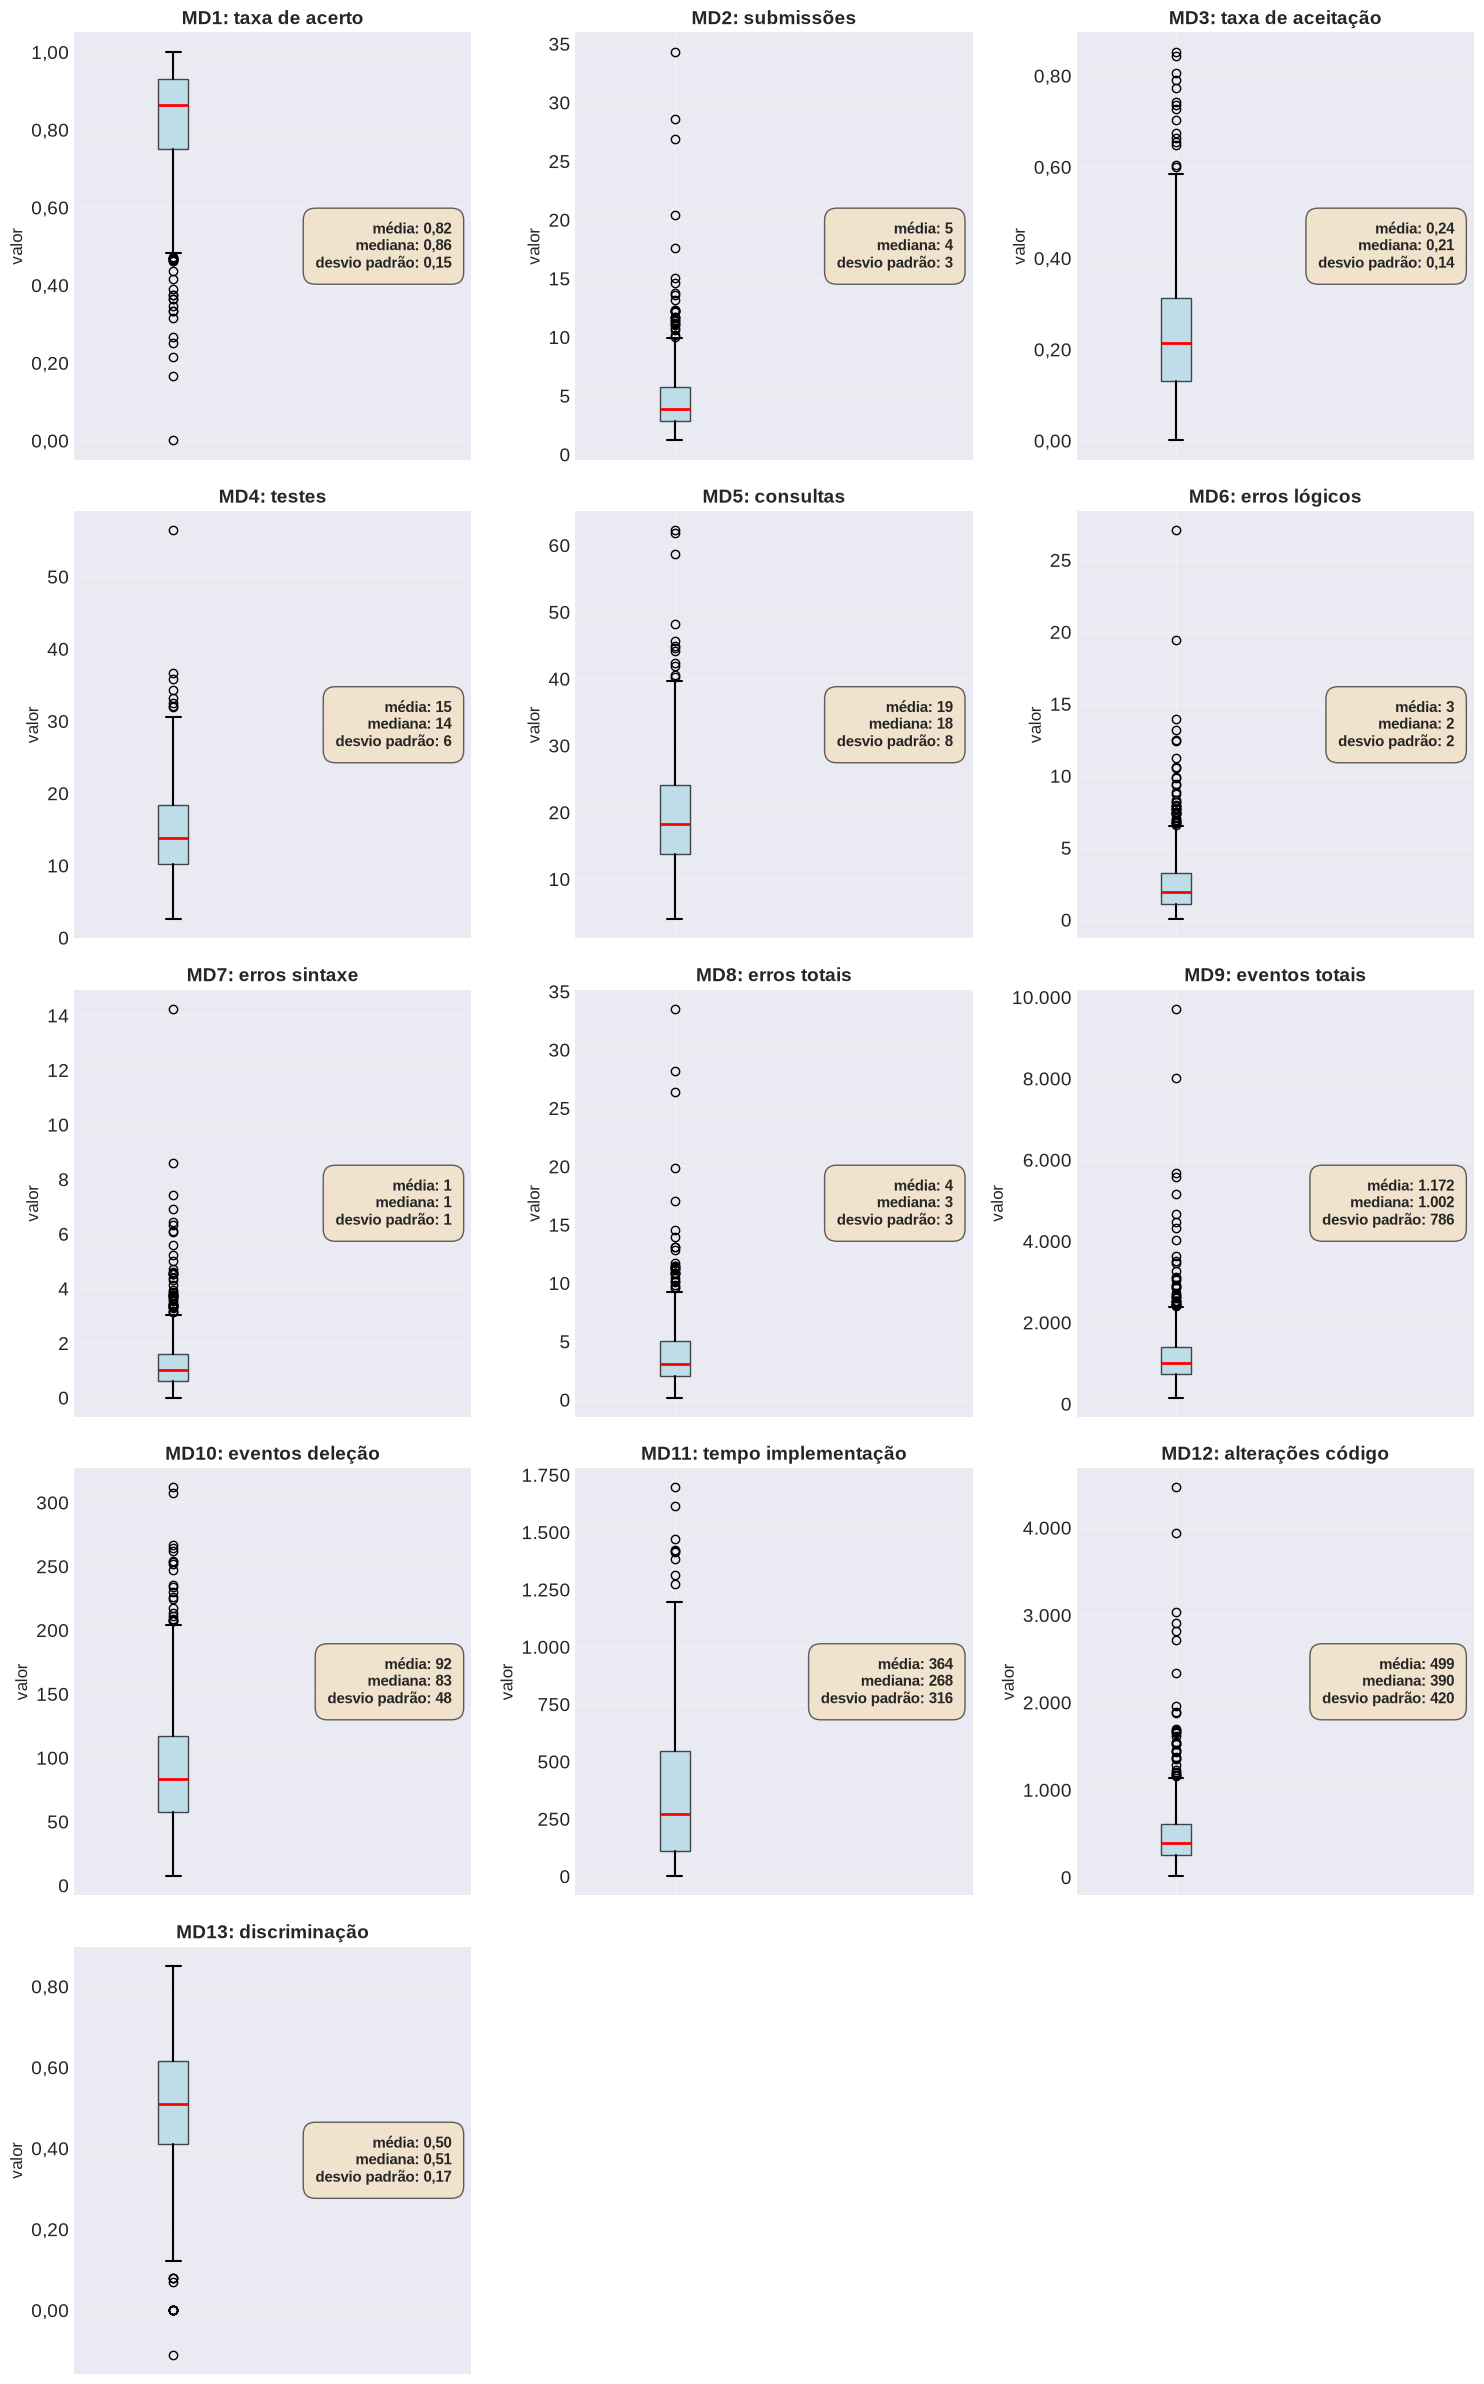

✓ Boxplots com dados originais exibidos

5b. Gerando boxplots com z-score (dados normalizados, mesma escala)...
   Escala global do eixo Y: [-6,24, 11,73]


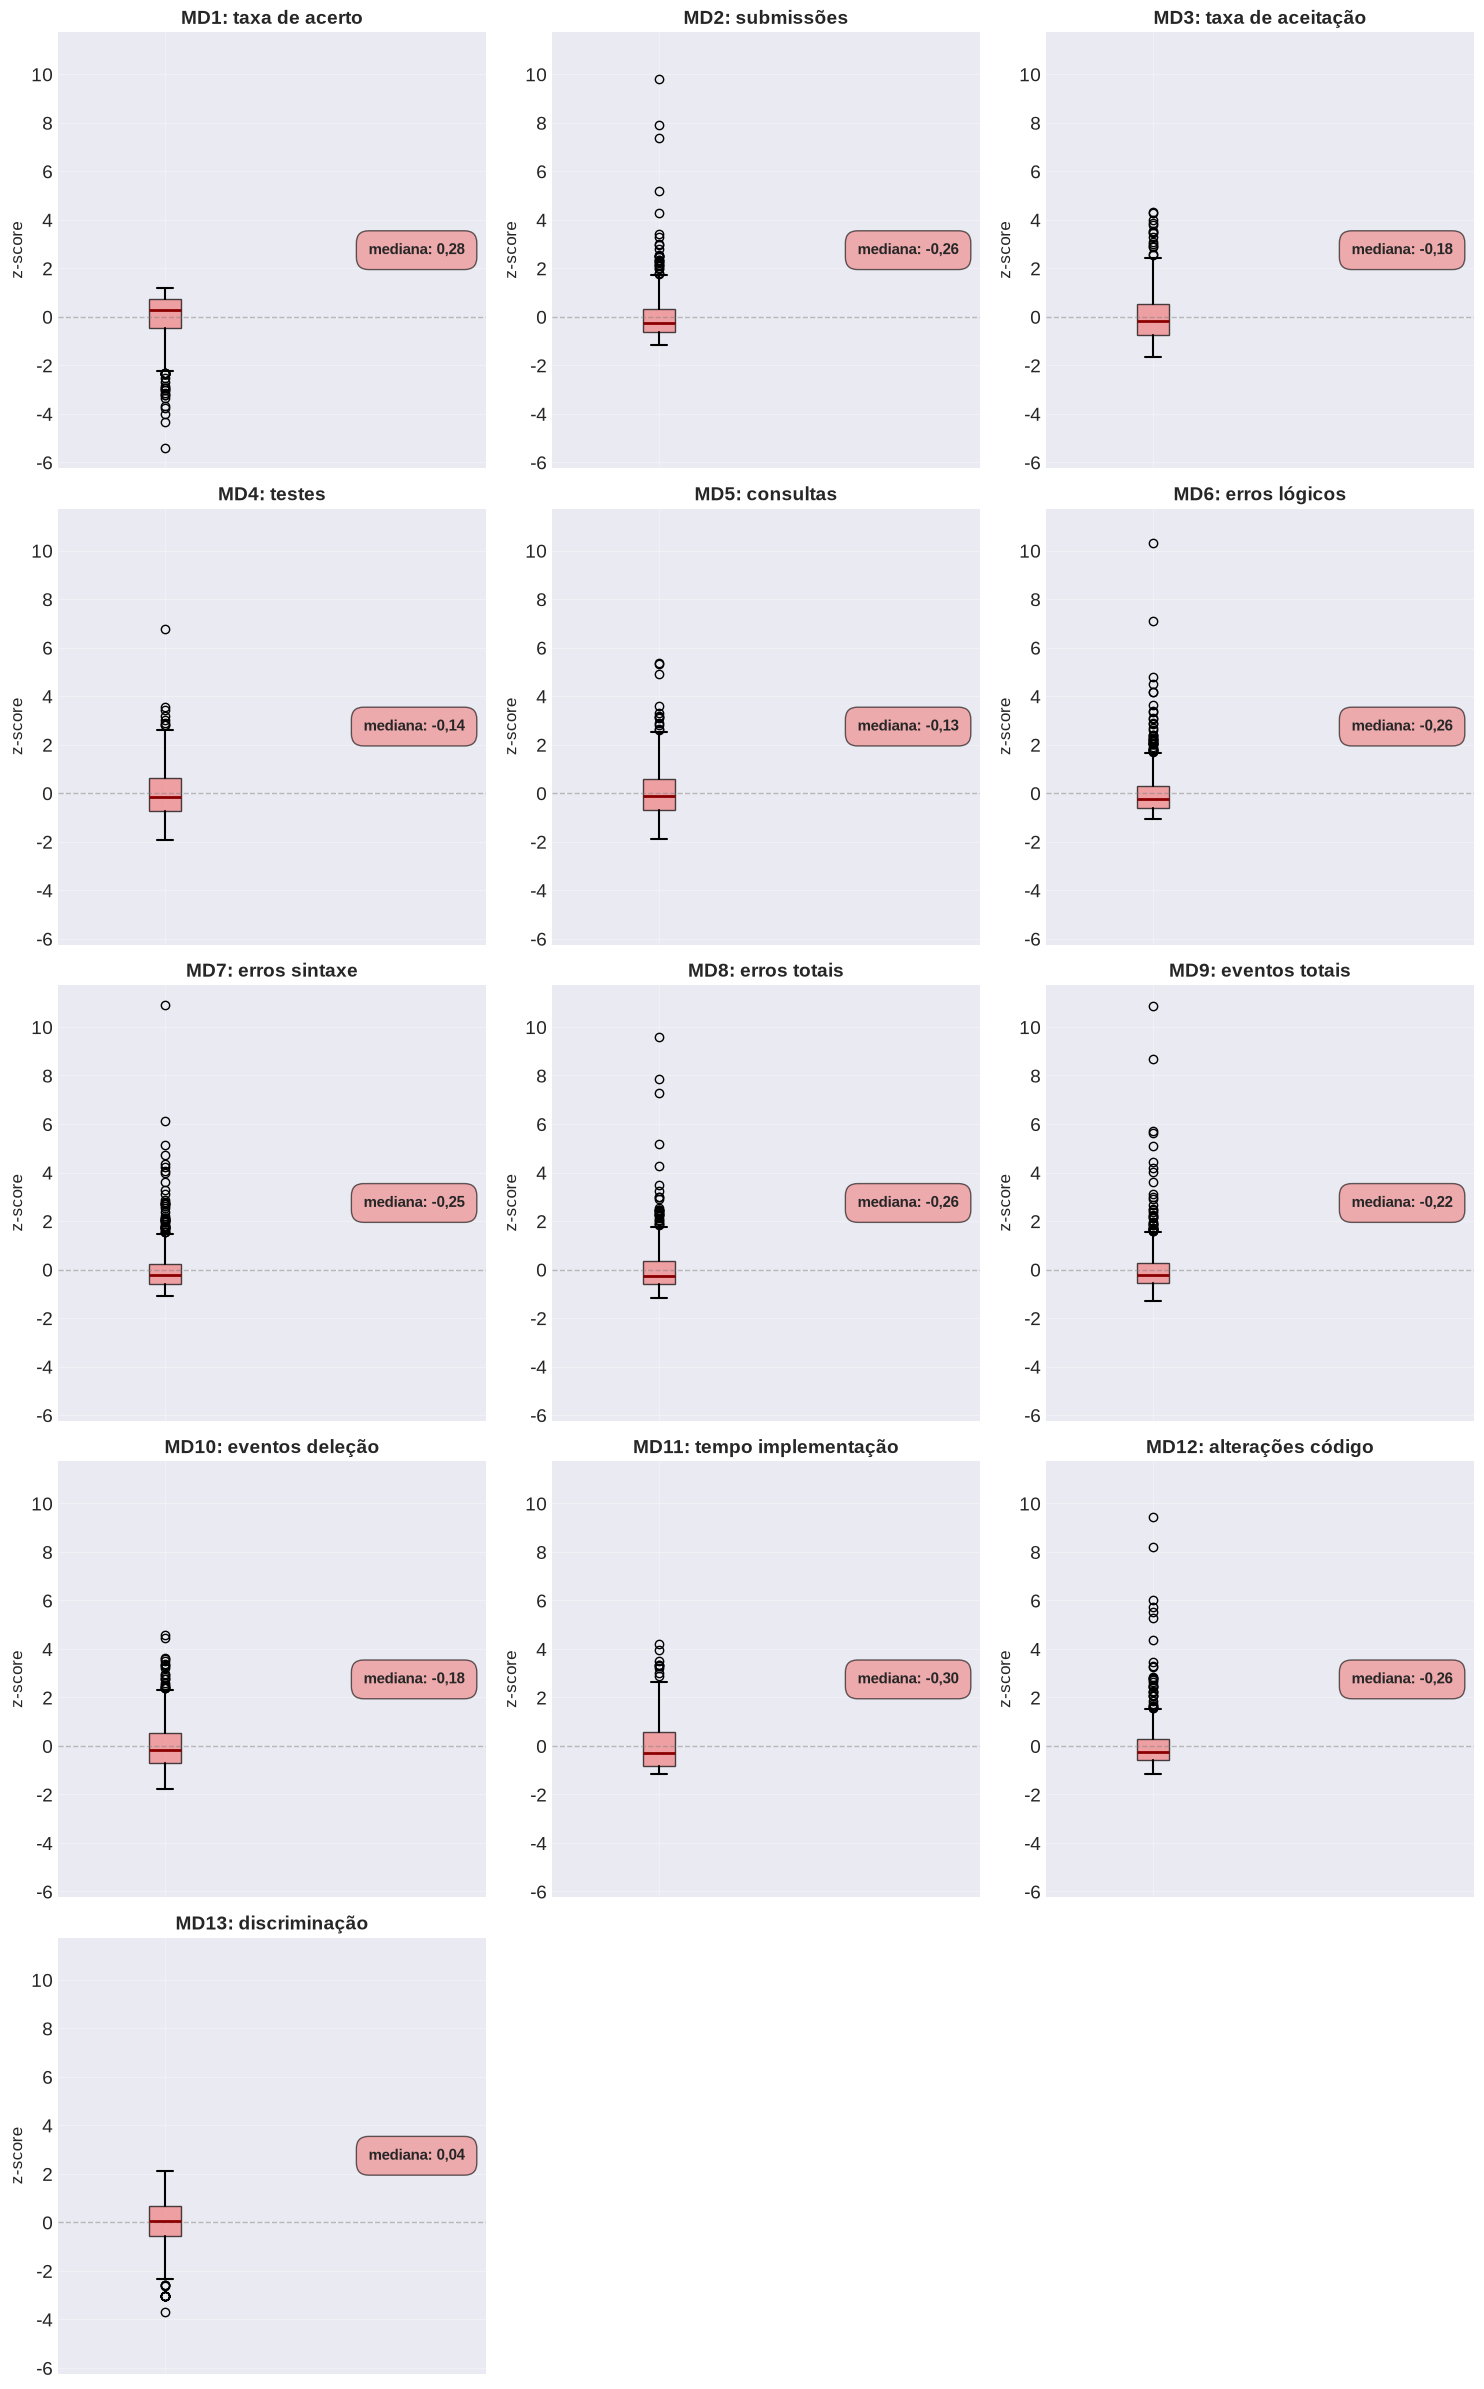

✓ Boxplots com z-score exibidos (escala unificada)

6. Calculando correlação de Spearman entre métricas...

MATRIZ DE CORRELAÇÃO DE SPEARMAN (forma de escada - TEXTO)

Métrica                    taxa de acer    submissões  taxa de acei        testes     consultas  erros lógico  erros sintax  erros totais  eventos tota  eventos dele  tempo implem  alterações c  discriminaçã
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
taxa de acerto                     1,00                                                                                                                                                                        
submissões                        -0,55          1,00                                                                                                                                                          


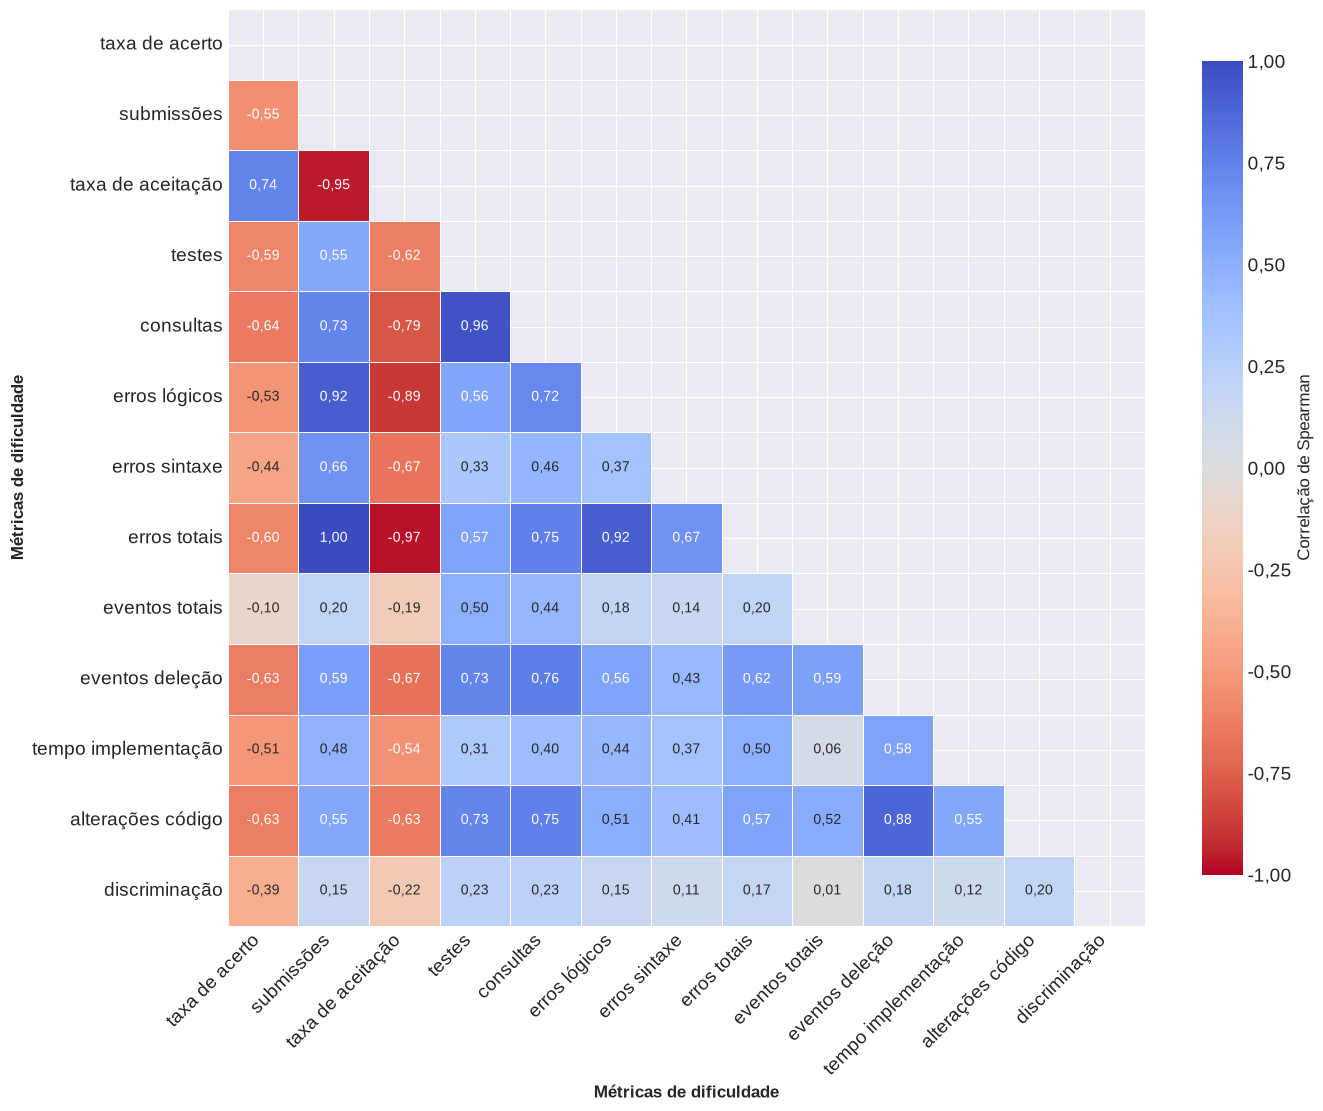

✓ Heatmap exibido

8. Análise de correlações fortes...

PARES DE MÉTRICAS COM CORRELAÇÃO FORTE (|ρ| > 0,7)
        Métrica 1         Métrica 2     ρ
taxa de aceitação    taxa de acerto  0,74
taxa de aceitação        submissões -0,95
        consultas        submissões  0,73
        consultas taxa de aceitação -0,79
        consultas            testes  0,96
    erros lógicos        submissões  0,92
    erros lógicos taxa de aceitação -0,89
    erros lógicos         consultas  0,72
     erros totais        submissões  1,00
     erros totais taxa de aceitação -0,97
     erros totais         consultas  0,75
     erros totais     erros lógicos  0,92
  eventos deleção            testes  0,73
  eventos deleção         consultas  0,76
alterações código            testes  0,73
alterações código         consultas  0,75
alterações código   eventos deleção  0,88

PARES DE MÉTRICAS COM CORRELAÇÃO MODERADA (0,5 < |ρ| ≤ 0,7)
          Métrica 1           Métrica 2     ρ
         submissões      taxa 

In [57]:
from pathlib import Path
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configurações

# Configurações de fonte global
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Mapeamento de Colunas para Nomes Legíveis

# ============================================================================
# MAPEAMENTO DAS MÉTRICAS DE DIFICULDADE
# Colunas reais do CSV → nomes legíveis
# 'dificuldade' é ignorada conforme instrução
# ============================================================================
# M1:  taxa_acerto           = num_correct / num_students_interactions
# M2:  num_submissoes        = num_submissions / num_students_interactions
# M3:  taxa_aceitacao        = num_correct / num_submissions
# M4:  num_testes            = num_tests / num_students_interactions
# M5:  num_consultas         = (num_submissions + num_tests) / num_students_interactions
# M6:  num_erros_lgcs        = num_logic_errors / num_students_interactions
# M7:  num_errors_stx        = num_syntax_errors / num_students_interactions
# M8:  num_erros             = num_errors / num_students_interactions
# M9:  num_eventos           = num_events / num_students_interactions
# M10: num_eventos_del       = num_deletes / num_students_interactions
# M11: tempo_implementacao   = code_time / num_correct
# M12: qtd_alteracoes_codigo = amount_of_change / num_students_interactions
# M13: discriminacao         (fórmula própria - já calculada)


# Métricas onde valores menores = questão mais difícil (positivas invertidas)
# Usadas apenas para referência semântica

# Métricas com casas decimais (as demais são exibidas como inteiros)

def formatar_numero(valor):
    """Formata número com separador de milhares (.) e sem decimais"""
    if pd.isna(valor):
        return 'N/A'
    try:
        v = float(valor)
        if v >= 1000 or v <= -1000:
            return f"{int(round(v)):,}".replace(',', '.')
        return str(int(round(v)))
    except:
        return 'N/A'

def formatar_decimal(valor, casas=3):
    """Formata decimal com vírgula como separador"""
    if pd.isna(valor):
        return 'N/A'
    try:
        formato = f"{{:.{casas}f}}"
        return formato.format(float(valor)).replace('.', ',')
    except:
        return 'N/A'

def formatar_metrica(valor, nome_coluna, casas=2):
    """Formata valor de acordo com o tipo da métrica"""
    if pd.isna(valor):
        return 'N/A'
    if nome_coluna in METRICAS_DECIMAIS:
        return formatar_decimal(valor, casas)
    else:
        return formatar_numero(valor)

# Configuração de estilo para gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("ANÁLISE DAS MÉTRICAS DE DIFICULDADE")
print("=" * 80)

# 1. CARREGAR DADOS
print("\n1. Carregando dados...")
df = pd.read_csv(QUESTIONS_PATH)
print(f"   Total de questões no arquivo: {formatar_numero(len(df))}")

# 2. IDENTIFICAR MÉTRICAS DE DIFICULDADE DISPONÍVEIS NO CSV
# Apenas as colunas que existem no arquivo E estão no dicionário de tradução
difficulty_metrics = [col for col in traducao_metricas.keys() if col in df.columns]

print(f"\n2. Métricas de dificuldade identificadas: {len(difficulty_metrics)}")
for i, metric in enumerate(difficulty_metrics, 1):
    print(f"   MD{i}: {metric} → {traducao_metricas[metric]}")

# 3. FILTRAR QUESTÕES COM 16+ RESPOSTAS
print("\n3. Filtrando questões com 16 ou mais respostas...")
pc3_columns = [col for col in list(PC3_MAP.keys()) if col in df.columns]
df['total_responses'] = df[pc3_columns].sum(axis=1)
df_filtered = df[df['total_responses'] >= MIN_QUESTAO_RESPOSTAS].copy()
print(f"   Questões com 16+ respostas: {formatar_numero(len(df_filtered))}")
print(f"   Questões excluídas: {formatar_numero(len(df) - len(df_filtered))}")

# Converter métricas para numérico
for metric in difficulty_metrics:
    df_filtered[metric] = pd.to_numeric(df_filtered[metric], errors='coerce')

# 4. CALCULAR ESTATÍSTICAS DESCRITIVAS
print("\n4. Calculando estatísticas descritivas...")
print("\n" + "=" * 80)
print("TABELA: Medidas de tendência central e dispersão das métricas de dificuldade")
print("Questões com 16 ou mais respostas")
print("=" * 80)

stats_list = []
valid_metrics = []

for metric in difficulty_metrics:
    values = df_filtered[metric].dropna()
    if len(values) > 0:
        stats = {
            'Métrica': traducao_metricas.get(metric, metric),
            'n': formatar_numero(len(values)),
            'Média': formatar_metrica(values.mean(), metric, casas=3),
            'Desvio-padrão': formatar_metrica(values.std(), metric, casas=3),
            'Min': formatar_metrica(values.min(), metric, casas=3),
            'Mediana': formatar_metrica(values.median(), metric, casas=3),
            'Max': formatar_metrica(values.max(), metric, casas=3),
        }
        stats_list.append(stats)
        valid_metrics.append(metric)
    else:
        print(f"   ⚠️  Métrica '{metric}' sem valores válidos. Ignorando.")

stats_df = pd.DataFrame(stats_list)
print(stats_df.to_string(index=False))

difficulty_metrics = valid_metrics

# 5. PLOTAR BOXPLOTS - DADOS ORIGINAIS
print("\n5. Gerando boxplots com dados originais...")

n_metrics = len(difficulty_metrics)
n_cols = 3
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.8 * n_rows))
plt.subplots_adjust(top=0.92, hspace=0.6, bottom=0.08)

if n_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

for idx, metric in enumerate(difficulty_metrics):
    ax = axes_flat[idx]
    data = df_filtered[metric].dropna()

    bp = ax.boxplot([data], orientation="vertical", patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))

    ax.set_xlim(0.5, 2.5)
    ax.set_title(f'MD{idx+1}: {traducao_metricas.get(metric, metric)}', fontweight='bold')
    ax.set_ylabel('valor')
    ax.set_xticklabels([''])
    ax.grid(True, alpha=0.3)

    # Formatar eixo Y de acordo com o tipo da métrica
    if metric in METRICAS_DECIMAIS:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_decimal(x, 2)))
    else:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_numero(x)))

    # Texto com estatísticas
    media_fmt   = formatar_metrica(data.mean(),   metric, casas=2)
    mediana_fmt = formatar_metrica(data.median(), metric, casas=2)
    std_fmt     = formatar_metrica(data.std(),    metric, casas=2)
    stats_text = f'média: {media_fmt}\nmediana: {mediana_fmt}\ndesvio padrão: {std_fmt}'

    ax.text(0.95, 0.5, stats_text, transform=ax.transAxes,
            verticalalignment='center', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='wheat', alpha=0.6),
            fontsize=11, fontweight='bold')

for idx in range(n_metrics, len(axes_flat)):
    fig.delaxes(axes_flat[idx])

plt.tight_layout()
plt.show()
print("✓ Boxplots com dados originais exibidos")

# 5b. PLOTAR BOXPLOTS - Z-SCORE (MESMA ESCALA NO EIXO Y)
print("\n5b. Gerando boxplots com z-score (dados normalizados, mesma escala)...")

# Calcular todos os z-scores primeiro para determinar escala global
all_zscores = []
zscores_por_metrica = {}
for metric in difficulty_metrics:
    data = df_filtered[metric].dropna()
    std = data.std()
    z = (data - data.mean()) / std if std != 0 else data * 0
    zscores_por_metrica[metric] = z
    all_zscores.append(z)

# Determinar min e max globais com margem de 5%
z_global_min = min(z.min() for z in all_zscores)
z_global_max = max(z.max() for z in all_zscores)
margem = (z_global_max - z_global_min) * 0.05
y_min = z_global_min - margem
y_max = z_global_max + margem

print(f"   Escala global do eixo Y: [{formatar_decimal(y_min, 2)}, {formatar_decimal(y_max, 2)}]")

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(15, 4.8 * n_rows))
plt.subplots_adjust(top=0.92, hspace=0.6, bottom=0.08)

if n_rows == 1:
    axes2 = axes2.reshape(1, -1)
axes2_flat = axes2.flatten()

def format_zscore(x, p):
    return str(int(x)) if x == int(x) else formatar_decimal(x, 1)

for idx, metric in enumerate(difficulty_metrics):
    ax = axes2_flat[idx]
    z_score = zscores_por_metrica[metric]

    bp = ax.boxplot([z_score], orientation="vertical", patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7),
                    medianprops=dict(color='darkred', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))

    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(y_min, y_max)   # ← mesma escala em todos os subplots
    ax.set_title(f'MD{idx+1}: {traducao_metricas.get(metric, metric)}', fontweight='bold')
    ax.set_ylabel('z-score')
    ax.set_xticklabels([''])
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(FuncFormatter(format_zscore))
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    stats_text = f'mediana: {formatar_decimal(z_score.median(), 2)}'
    ax.text(0.95, 0.5, stats_text, transform=ax.transAxes,
            verticalalignment='center', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='lightcoral', alpha=0.6),
            fontsize=11, fontweight='bold')

for idx in range(n_metrics, len(axes2_flat)):
    fig2.delaxes(axes2_flat[idx])

plt.tight_layout()
plt.show()
print("✓ Boxplots com z-score exibidos (escala unificada)")

# 6. CORRELAÇÃO DE SPEARMAN
print("\n6. Calculando correlação de Spearman entre métricas...")

df_metrics = df_filtered[difficulty_metrics].copy()
corr_df = df_metrics.corr(method='spearman')
corr_matrix = corr_df.values
n_metrics = len(difficulty_metrics)
translated_metrics = [traducao_metricas.get(m, m) for m in difficulty_metrics]

# 7. MATRIZ EM ESCADA (TEXTO)
print("\n" + "=" * 80)
print("MATRIZ DE CORRELAÇÃO DE SPEARMAN (forma de escada - TEXTO)")
print("=" * 80)
print()

header = f"{'Métrica':<25}"
for metric in translated_metrics:
    header += f"{metric[:12]:>14}"
print(header)
print("-" * (25 + 14 * n_metrics))

for i, metric_i in enumerate(translated_metrics):
    line = f"{metric_i:<25}"
    for j in range(n_metrics):
        if j <= i:
            val = corr_matrix[i, j]
            line += f"{formatar_decimal(val, 2) if not np.isnan(val) else 'N/A':>14}"
        else:
            line += f"{'':>14}"
    print(line)

# 8. HEATMAP TRIANGULAR
print("\n7. Gerando heatmap da matriz de correlação...")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
annot_data = corr_df.map(lambda x: formatar_decimal(x, 2))

fig, ax = plt.subplots(figsize=(14, 12))
heatmap = sns.heatmap(corr_df,
            mask=mask,
            annot=annot_data,
            fmt='',
            cmap='coolwarm_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlação de Spearman"},
            xticklabels=translated_metrics,
            yticklabels=translated_metrics,
            vmin=-1, vmax=1,
            ax=ax,
            annot_kws={'fontsize': 10})

colorbar = heatmap.collections[0].colorbar
colorbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_decimal(x, 2)))

ax.set_xlabel('Métricas de dificuldade', fontsize=12, fontweight='bold')
ax.set_ylabel('Métricas de dificuldade', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("✓ Heatmap exibido")

# 9. CORRELAÇÕES FORTES
print("\n8. Análise de correlações fortes...")
print("\n" + "=" * 80)
print("PARES DE MÉTRICAS COM CORRELAÇÃO FORTE (|ρ| > 0,7)")
print("=" * 80)

strong_corr = []
for i in range(n_metrics):
    for j in range(i):
        val = corr_matrix[i, j]
        if not np.isnan(val) and abs(val) > 0.7:
            strong_corr.append({
                'Métrica 1': traducao_metricas.get(difficulty_metrics[i], difficulty_metrics[i]),
                'Métrica 2': traducao_metricas.get(difficulty_metrics[j], difficulty_metrics[j]),
                'ρ': formatar_decimal(val, 2),
            })

if strong_corr:
    print(pd.DataFrame(strong_corr).to_string(index=False))
else:
    print("Nenhuma correlação forte encontrada (|ρ| > 0,7)")

# 10. CORRELAÇÕES MODERADAS
print("\n" + "=" * 80)
print("PARES DE MÉTRICAS COM CORRELAÇÃO MODERADA (0,5 < |ρ| ≤ 0,7)")
print("=" * 80)

moderate_corr = []
for i in range(n_metrics):
    for j in range(i):
        val = corr_matrix[i, j]
        if not np.isnan(val) and 0.5 < abs(val) <= 0.7:
            moderate_corr.append({
                'Métrica 1': traducao_metricas.get(difficulty_metrics[i], difficulty_metrics[i]),
                'Métrica 2': traducao_metricas.get(difficulty_metrics[j], difficulty_metrics[j]),
                'ρ': formatar_decimal(val, 2),
            })

if moderate_corr:
    print(pd.DataFrame(moderate_corr).to_string(index=False))
else:
    print("Nenhuma correlação moderada encontrada")

# 11. RESUMO FINAL
print("\n" + "=" * 80)
print("RESUMO DA ANÁLISE")
print("=" * 80)
print(f"✓ Total de questões analisadas: {formatar_numero(len(df_filtered))}")
print(f"✓ Número de métricas de dificuldade válidas: {len(difficulty_metrics)}")
print(f"✓ Métricas analisadas:")
for i, metric in enumerate(difficulty_metrics, 1):
    print(f"   MD{i}: {metric} → {traducao_metricas[metric]}")
print(f"\n⚠️  Métrica 'dificuldade' ignorada conforme configuração.")
print("\n" + "=" * 80)
print("ANÁLISE CONCLUÍDA COM SUCESSO!")
print("=" * 80)

# 4 - Correlação entre PC³ e métricas de dificuldade



💡 USO: analisar_correlacao_pc3_metricas(top_n=TOP_N_PC3)
   - top_n=10   : após o filtro, limita aos 10 mais frequentes
   - top_n=None : analisa todos os PC³ com o mínimo de ocorrências


ANÁLISE DE CORRELAÇÃO: PC³ vs MÉTRICAS DE DIFICULDADE

1. Carregando dados...
   Total de questões no arquivo: 770

2. Filtrando questões com 16+ respostas...
   Questões com 16+ respostas: 679
   Questões excluídas: 91

3. Identificando PC³ ativos...
   ⚠️ PC³ removidos (sem ocorrências): C2, C4
   ✓ PC³ ativos totais: 20

4. Identificando métricas de dificuldade válidas...
   ✓ Métricas válidas para análise: 13
     MD1: taxa_acerto → taxa de acerto
     MD2: num_submissoes → submissões
     MD3: taxa_aceitacao → taxa de aceitação
     MD4: num_testes → testes
     MD5: num_consultas → consultas
     MD6: num_erros_lgcs → erros lógicos
     MD7: num_errors_stx → erros sintaxe
     MD8: num_erros → erros totais
     MD9: num_eventos → eventos totais
     MD10: num_eventos_del → eventos deleção
   

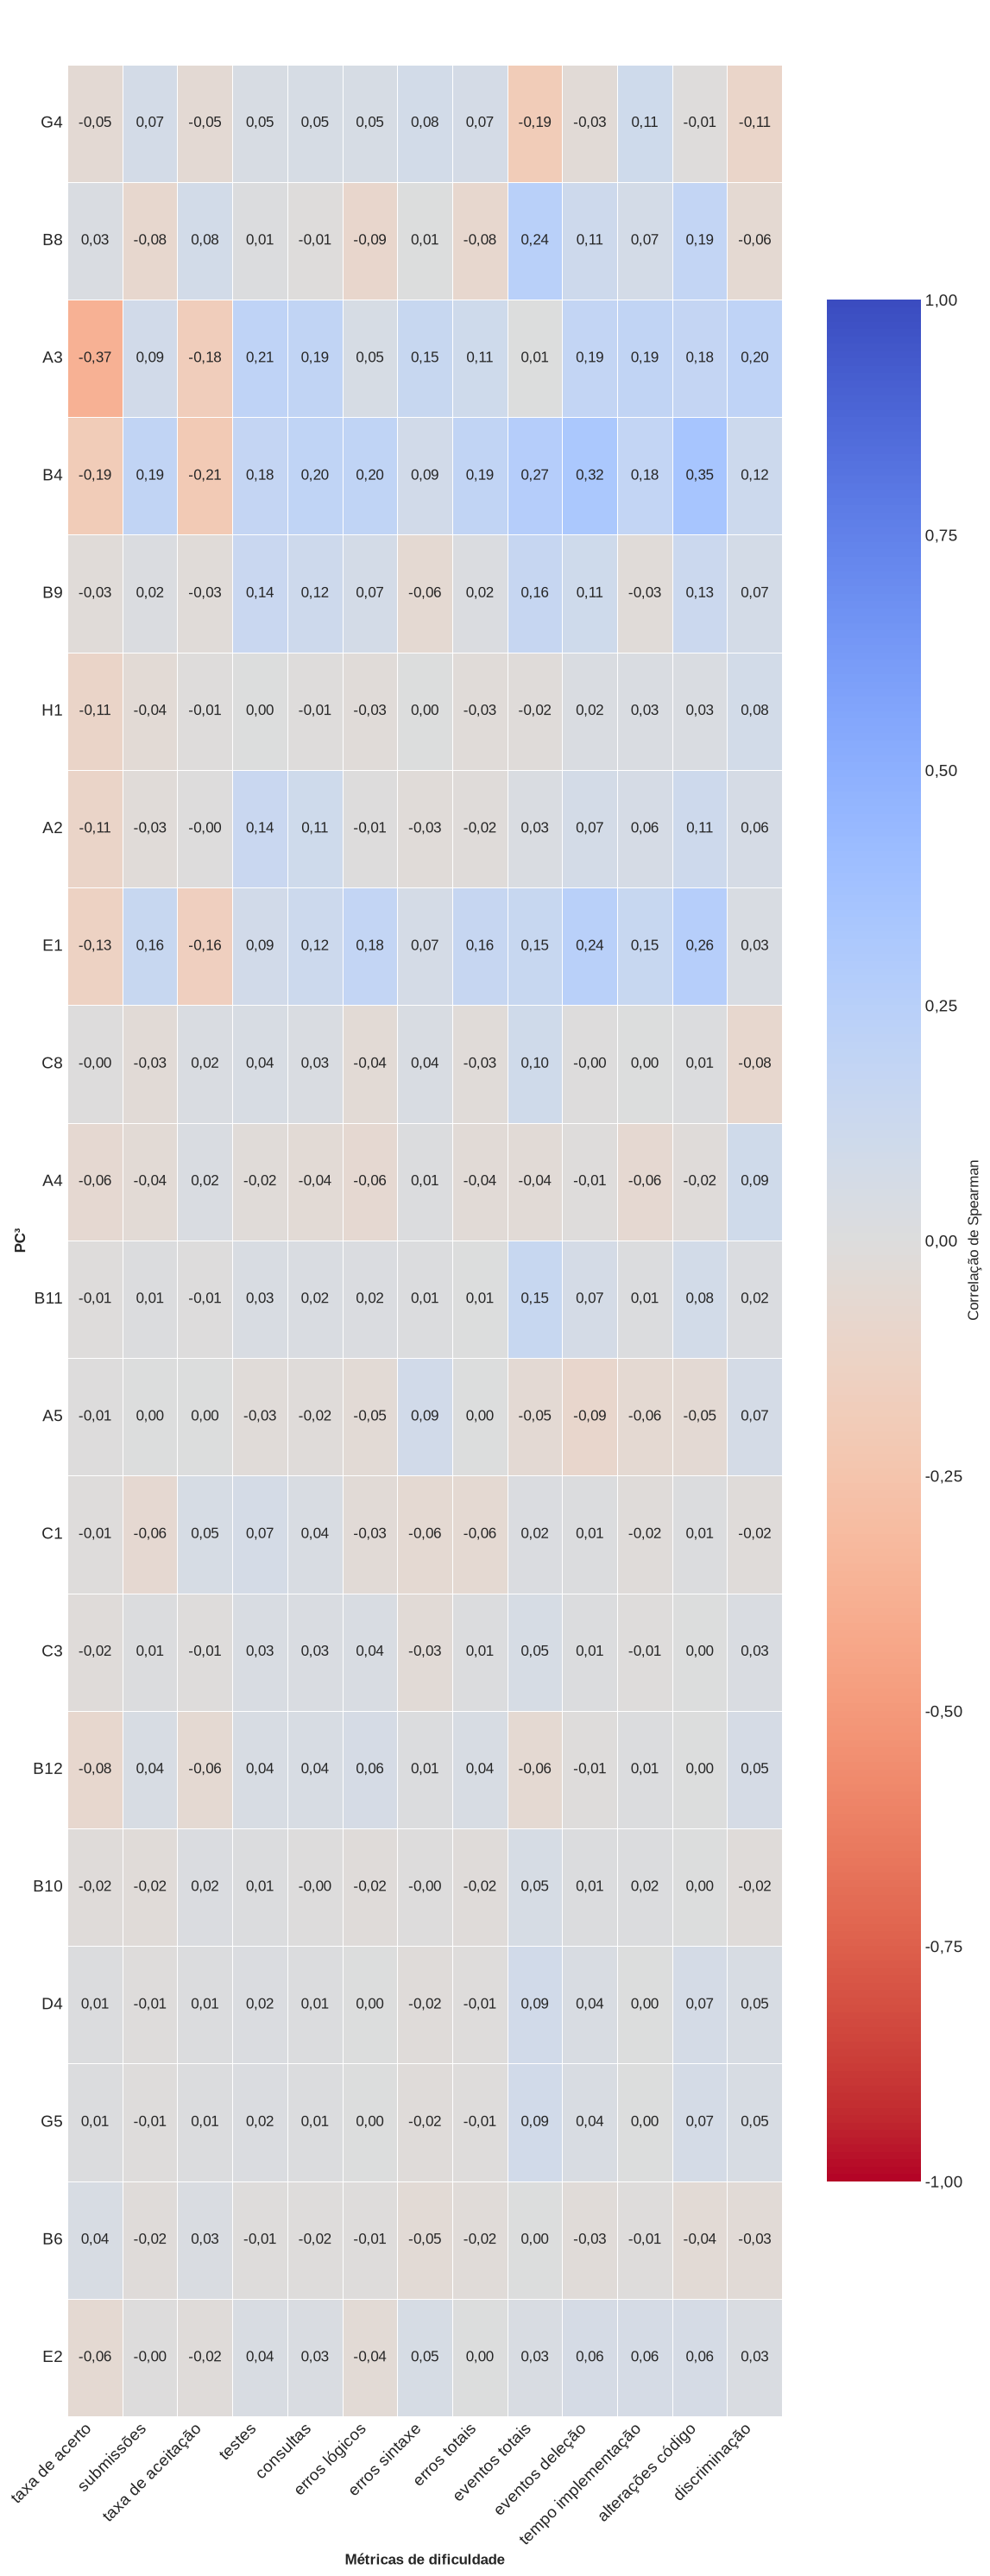

✓ Heatmap exibido

8. Analisando correlações PC³ ↔ Métricas...

CORRELAÇÕES FORTES ENTRE PC³ E MÉTRICAS (|ρ| > 0,7)
Nenhuma correlação forte encontrada entre PC³ e Métricas.

CORRELAÇÕES MODERADAS ENTRE PC³ E MÉTRICAS (0,5 < |ρ| ≤ 0,7)
Nenhuma correlação moderada encontrada.

RESUMO DA ANÁLISE
✓ Total de questões analisadas: 679
✓ PC³ analisados: 20 (Todos)
✓ Métricas de dificuldade analisadas: 13
✓ Dimensão da matriz: 20 PC³ × 13 Métricas
✓ Correlações fortes  (|ρ| > 0,7): 0
✓ Correlações moderadas (0,5 < |ρ| ≤ 0,7): 0

⚠️  Métrica 'dificuldade' ignorada conforme configuração.

ANÁLISE CONCLUÍDA COM SUCESSO!


In [58]:
from pathlib import Path
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configurações

# Mapeamento de Colunas PC³

# ============================================================================
# MAPEAMENTO DAS MÉTRICAS DE DIFICULDADE
# Colunas reais do CSV → nomes legíveis
# 'dificuldade' é ignorada intencionalmente
# M1:  taxa_acerto           = num_correct / num_students_interactions
# M2:  num_submissoes        = num_submissions / num_students_interactions
# M3:  taxa_aceitacao        = num_correct / num_submissions
# M4:  num_testes            = num_tests / num_students_interactions
# M5:  num_consultas         = (num_submissions + num_tests) / num_students_interactions
# M6:  num_erros_lgcs        = num_logic_errors / num_students_interactions
# M7:  num_errors_stx        = num_syntax_errors / num_students_interactions
# M8:  num_erros             = num_errors / num_students_interactions
# M9:  num_eventos           = num_events / num_students_interactions
# M10: num_eventos_del       = num_deletes / num_students_interactions
# M11: tempo_implementacao   = code_time / num_correct
# M12: qtd_alteracoes_codigo = amount_of_change / num_students_interactions
# M13: discriminacao         (fórmula própria - já calculada)
# ============================================================================

def formatar_decimal(valor, casas=2):
    """Formata decimal com vírgula"""
    if pd.isna(valor) or np.isnan(valor):
        return 'N/A'
    formato = f"{{:.{casas}f}}"
    return formato.format(valor).replace('.', ',')

# Configuração de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def analisar_correlacao_pc3_metricas(top_n=TOP_N_PC3):
    """
    Analisa correlação entre PC³ e Métricas de Dificuldade

    Parâmetros:
        top_n (int): Número de PC³ mais frequentes a analisar. Default: 10
                     Use None para analisar todos os PC³ ativos.
    """

    print("=" * 80)
    print("ANÁLISE DE CORRELAÇÃO: PC³ vs MÉTRICAS DE DIFICULDADE")
    print("=" * 80)

    # 1. CARREGAR DADOS
    print("\n1. Carregando dados...")
    df = pd.read_csv(QUESTIONS_PATH)
    print(f"   Total de questões no arquivo: {len(df)}")

    # 2. FILTRAR QUESTÕES COM 16+ RESPOSTAS
    print("\n2. Filtrando questões com 16+ respostas...")
    pc3_columns = [col for col in list(PC3_MAP.keys()) if col in df.columns]
    df['total_responses'] = df[pc3_columns].sum(axis=1)
    df_filtered = df[df['total_responses'] >= MIN_QUESTAO_RESPOSTAS].copy()
    print(f"   Questões com 16+ respostas: {len(df_filtered)}")
    print(f"   Questões excluídas: {len(df) - len(df_filtered)}")

    # 3. IDENTIFICAR COLUNAS PC³ ATIVAS (não vazias)
    print("\n3. Identificando PC³ ativos...")
    pc3_active = []
    pc3_removed = []

    for col in pc3_columns:
        if df_filtered[col].sum() > 0:
            pc3_active.append(col)
        else:
            pc3_removed.append(PC3_MAP[col])

    if pc3_removed:
        print(f"   ⚠️ PC³ removidos (sem ocorrências): {', '.join(pc3_removed)}")
    print(f"   ✓ PC³ ativos totais: {len(pc3_active)}")

    # 4. IDENTIFICAR MÉTRICAS DE DIFICULDADE DISPONÍVEIS NO CSV
    print("\n4. Identificando métricas de dificuldade válidas...")
    difficulty_metrics = []

    for metric in traducao_metricas.keys():
        if metric in df_filtered.columns:
            try:
                df_filtered[metric] = pd.to_numeric(df_filtered[metric], errors='coerce')
                if df_filtered[metric].dropna().shape[0] > 0:
                    difficulty_metrics.append(metric)
            except:
                pass
        else:
            print(f"   ⚠️ Coluna '{metric}' não encontrada no CSV. Ignorando.")

    print(f"   ✓ Métricas válidas para análise: {len(difficulty_metrics)}")
    for i, m in enumerate(difficulty_metrics, 1):
        print(f"     MD{i}: {m} → {traducao_metricas[m]}")

    # 5. ORDENAR PC³ POR FREQUÊNCIA E APLICAR TOP_N
    print("\n5. Ordenando PC³ por frequência...")
    pc3_totals = {col: df_filtered[col].sum() for col in pc3_active}
    pc3_sorted = sorted(pc3_totals.items(), key=lambda x: x[1], reverse=True)
    pc3_sorted = [(col, total) for col, total in pc3_sorted
                  if total >= PC3_MIN_OCCURRENCES]
    print(f"   PC³ com {PC3_MIN_OCCURRENCES} ou mais ocorrências: {len(pc3_sorted)}")

    if top_n is not None and top_n < len(pc3_sorted):
        pc3_sorted = pc3_sorted[:top_n]
        print(f"   ℹ️ Selecionando os Top {top_n} PC³ mais frequentes")
    else:
        print(f"   ℹ️ Analisando todos os {len(pc3_sorted)} PC³ ativos")

    pc3_ordered = [col for col, _ in pc3_sorted]

    print("   Ordem (decrescente por frequência):")
    display_limit = min(10, len(pc3_ordered))
    for i, col in enumerate(pc3_ordered[:display_limit], 1):
        print(f"      {i}. {PC3_MAP[col]}: {int(pc3_totals[col])} ocorrências")
    if len(pc3_ordered) > display_limit:
        print(f"      ... e mais {len(pc3_ordered) - display_limit} PC³")

    # 6. CALCULAR CORRELAÇÃO ENTRE PC³ E MÉTRICAS
    print("\n6. Calculando correlação de Spearman (PC³ vs Métricas)...")

    n_pc3 = len(pc3_ordered)
    n_metrics = len(difficulty_metrics)

    corr_cross = np.zeros((n_pc3, n_metrics))

    for i, pc3_col in enumerate(pc3_ordered):
        for j, metric_col in enumerate(difficulty_metrics):
            valid_mask = df_filtered[pc3_col].notna() & df_filtered[metric_col].notna()
            if valid_mask.sum() > 1:
                corr_val = df_filtered.loc[valid_mask, [pc3_col, metric_col]].corr(method='spearman').iloc[0, 1]
                corr_cross[i, j] = corr_val
            else:
                corr_cross[i, j] = np.nan

    pc3_names = [PC3_MAP[col] for col in pc3_ordered]
    metric_names = [traducao_metricas[m] for m in difficulty_metrics]

    # 7. EXIBIR MATRIZ (TEXTO)
    print("\n" + "=" * 80)
    print("MATRIZ DE CORRELAÇÃO: PC³ (linhas) vs MÉTRICAS (colunas)")
    print("=" * 80)
    print()

    header = f"{'PC³':<20}"
    for name in metric_names:
        header += f"{name[:12]:>14}"
    print(header)
    print("-" * (20 + 14 * n_metrics))

    for i, pc3_name in enumerate(pc3_names):
        line = f"{pc3_name:<20}"
        for j in range(n_metrics):
            val = corr_cross[i, j]
            line += f"{'N/A':>14}" if np.isnan(val) else f"{formatar_decimal(val, 2):>14}"
        print(line)

    # 8. HEATMAP COMPLETO
    print("\n7. Gerando heatmap...")

    plt.figure(figsize=(n_metrics * 0.9, n_pc3 * 1.5))

    corr_df = pd.DataFrame(corr_cross, index=pc3_names, columns=metric_names)
    annot_data = corr_df.map(lambda x: formatar_decimal(x, 2))

    sns.heatmap(corr_df,
                annot=annot_data,
                fmt='',
                cmap='coolwarm_r',
                center=0,
                vmin=-1,
                vmax=1,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8, "label": "Correlação de Spearman"})

    plt.title('\n', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Métricas de dificuldade', fontsize=12, fontweight='bold')
    plt.ylabel('PC³', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    ax = plt.gca()
    colorbar = ax.collections[0].colorbar
    colorbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_decimal(x, 2)))

    plt.tight_layout()
    plt.show()
    print("✓ Heatmap exibido")

    # 9. CORRELAÇÕES FORTES
    print("\n8. Analisando correlações PC³ ↔ Métricas...")
    print("\n" + "=" * 80)
    print("CORRELAÇÕES FORTES ENTRE PC³ E MÉTRICAS (|ρ| > 0,7)")
    print("=" * 80)

    strong_cross = []
    for i in range(n_pc3):
        for j in range(n_metrics):
            val = corr_cross[i, j]
            if not np.isnan(val) and abs(val) > 0.7:
                strong_cross.append({
                    'PC³': pc3_names[i],
                    'Métrica': metric_names[j],
                    'ρ': formatar_decimal(val, 2)
                })

    if strong_cross:
        print(pd.DataFrame(strong_cross).to_string(index=False))
    else:
        print("Nenhuma correlação forte encontrada entre PC³ e Métricas.")

    # 10. CORRELAÇÕES MODERADAS
    print("\n" + "=" * 80)
    print("CORRELAÇÕES MODERADAS ENTRE PC³ E MÉTRICAS (0,5 < |ρ| ≤ 0,7)")
    print("=" * 80)

    moderate_cross = []
    for i in range(n_pc3):
        for j in range(n_metrics):
            val = corr_cross[i, j]
            if not np.isnan(val) and 0.5 < abs(val) <= 0.7:
                moderate_cross.append({
                    'PC³': pc3_names[i],
                    'Métrica': metric_names[j],
                    'ρ': formatar_decimal(val, 2)
                })

    if moderate_cross:
        print(pd.DataFrame(moderate_cross).to_string(index=False))
    else:
        print("Nenhuma correlação moderada encontrada.")

    # 11. RESUMO FINAL
    print("\n" + "=" * 80)
    print("RESUMO DA ANÁLISE")
    print("=" * 80)
    print(f"✓ Total de questões analisadas: {len(df_filtered)}")
    print(f"✓ PC³ analisados: {n_pc3} {'(Top ' + str(top_n) + ')' if top_n else '(Todos)'}")
    print(f"✓ Métricas de dificuldade analisadas: {n_metrics}")
    print(f"✓ Dimensão da matriz: {n_pc3} PC³ × {n_metrics} Métricas")
    print(f"✓ Correlações fortes  (|ρ| > 0,7): {len(strong_cross)}")
    print(f"✓ Correlações moderadas (0,5 < |ρ| ≤ 0,7): {len(moderate_cross)}")
    print(f"\n⚠️  Métrica 'dificuldade' ignorada conforme configuração.")
    print("\n" + "=" * 80)
    print("ANÁLISE CONCLUÍDA COM SUCESSO!")
    print("=" * 80)


# EXECUTAR ANÁLISE
print("\n")
print("💡 USO: analisar_correlacao_pc3_metricas(top_n=TOP_N_PC3)")
print("   - top_n=10   : após o filtro, limita aos 10 mais frequentes")
print("   - top_n=None : analisa todos os PC³ com o mínimo de ocorrências")
print("=" * 80)
print("\n")

analisar_correlacao_pc3_metricas(top_n=TOP_N_PC3)

# 6 - Comparação entre PC³ e fatores demográficos

In [59]:
from pathlib import Path
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import csv
from pathlib import Path

# ============================================================================
# CONFIGURAÇÕES
# ============================================================================


# ============================================================================
# FUNÇÕES
# ============================================================================

def obter_lista_estudantes_catalogados():
    """
    Retorna LISTA de IDs de estudantes catalogados
    
    Similar a contar_estudantes(), mas retorna a LISTA em vez de apenas o count
    
    Retorna:
        set: conjunto de IDs únicos de usuários
    """
    estudantes = set()
    
    try:
        with open(MISCONCEPTIONS_PATH, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            
            for linha in reader:
                if 'usuario' in linha and linha['usuario']:
                    estudantes.add(linha['usuario'])
        
        return estudantes
    except FileNotFoundError:
        print(f"❌ Arquivo {MISCONCEPTIONS_PATH} não encontrado")
        return set()


# ============================================================================
# ANÁLISE PRINCIPAL
# ============================================================================

# 1. OBTER LISTA DE ESTUDANTES CATALOGADOS
print("=" * 70)
print("ANÁLISE DE user.data - APENAS ESTUDANTES CATALOGADOS")
print("=" * 70)

estudantes_catalogados = obter_lista_estudantes_catalogados()
print(f"\n📊 Estudantes catalogados: {len(estudantes_catalogados)}")

# 2. VERIFICAR TOTAL DE PASTAS NO DIRETÓRIO
caminho = REFERENCES_PATH

if not caminho.exists():
    print(f"❌ JSON de referências não encontrado: {caminho}")
    exit()

referencias = carregar_referencias(caminho)
total_pastas_no_disco = len(referencias.get('users', []))
print(f"📁 Total de usuários no índice: {total_pastas_no_disco}")

# 3. BUSCAR APENAS NAS PASTAS DOS ESTUDANTES CATALOGADOS
print(f"\n🔍 Buscando user.data APENAS dos {len(estudantes_catalogados)} estudantes catalogados...\n")

# Categorias para verificar
categorias = {
    'CURRENT DEGREE COURSE': 0,
    'HIGH SCHOOL': 0,
    'PERSONAL COMPUTER': 0,
    'WORK': 0,
    'PREVIOUS DEGREE': 0,
    'OTHER INFORMATION': 0
}

# Total de arquivos processados
total_arquivos_encontrados = 0
total_arquivos_nao_encontrados = 0

# ============================================================================
# ITERAR APENAS PELOS ESTUDANTES CATALOGADOS (não por todas as pastas!)
# ============================================================================

for usuario in estudantes_catalogados:
    # Construir caminho da pasta do usuário
    arquivos_user_data = list(iterar_arquivos_usuario(referencias, usuario, 'user_data', 'user.data'))
    arquivo_user_data = arquivos_user_data[0] if arquivos_user_data else None
    
    if arquivo_user_data is not None:
        total_arquivos_encontrados += 1
        
        # Ler o conteúdo do arquivo
        try:
            with open(arquivo_user_data, 'r', encoding='utf-8') as f:
                conteudo = f.read()
            
            # Verificar presença de cada categoria
            for categoria in categorias.keys():
                if f'-- {categoria}:' in conteudo:
                    categorias[categoria] += 1
                    
        except Exception as e:
            print(f"⚠️  Erro ao ler {arquivo_user_data}: {e}")
    else:
        total_arquivos_nao_encontrados += 1

# ============================================================================
# EXIBIR RESULTADOS
# ============================================================================

print("=" * 70)
print("RESULTADOS")
print("=" * 70)

print(f"\n📊 RESUMO:")
print(f"   • Total de pastas no disco: {total_pastas_no_disco}")
print(f"   • Estudantes catalogados: {len(estudantes_catalogados)}")
print(f"   • Arquivos user.data encontrados: {total_arquivos_encontrados}")
print(f"   • Arquivos user.data NÃO encontrados: {total_arquivos_nao_encontrados}")

if total_arquivos_nao_encontrados > 0:
    porcentagem_faltando = (total_arquivos_nao_encontrados / len(estudantes_catalogados)) * 100
    print(f"\n⚠️  {total_arquivos_nao_encontrados} estudantes catalogados ({porcentagem_faltando:.1f}%) não têm pasta em {caminho.name}")

print(f"\n📈 CONTAGEM POR CATEGORIA:")
print("-" * 70)

for categoria, count in categorias.items():
    if total_arquivos_encontrados > 0:
        porcentagem = (count / total_arquivos_encontrados * 100)
        print(f"-- {categoria:<25}: {count:>4} ({porcentagem:>5.1f}%)")
    else:
        print(f"-- {categoria:<25}: {count:>4}")

print("\n" + "=" * 70)

ANÁLISE DE user.data - APENAS ESTUDANTES CATALOGADOS

📊 Estudantes catalogados: 2855
📁 Total de usuários no índice: 2982

🔍 Buscando user.data APENAS dos 2855 estudantes catalogados...

RESULTADOS

📊 RESUMO:
   • Total de pastas no disco: 2982
   • Estudantes catalogados: 2855
   • Arquivos user.data encontrados: 0
   • Arquivos user.data NÃO encontrados: 2855

⚠️  2855 estudantes catalogados (100.0%) não têm pasta em referencias_processamento.json

📈 CONTAGEM POR CATEGORIA:
----------------------------------------------------------------------
-- CURRENT DEGREE COURSE    :    0
-- HIGH SCHOOL              :    0
-- PERSONAL COMPUTER        :    0
-- WORK                     :    0
-- PREVIOUS DEGREE          :    0
-- OTHER INFORMATION        :    0



In [60]:
from pathlib import Path
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import csv
from pathlib import Path
from collections import defaultdict

# ============================================================================
# CONFIGURAÇÕES
# ============================================================================


# ============================================================================
# FUNÇÕES
# ============================================================================

def obter_lista_estudantes_catalogados():
    """Retorna set de IDs de estudantes catalogados"""
    estudantes = set()
    
    try:
        with open(MISCONCEPTIONS_PATH, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            
            for linha in reader:
                if 'usuario' in linha and linha['usuario']:
                    estudantes.add(linha['usuario'])
        
        return estudantes
    except FileNotFoundError:
        print(f"❌ Arquivo {MISCONCEPTIONS_PATH} não encontrado")
        return set()


def extrair_campos_categoria(conteudo, inicio_categoria, proxima_categoria=None):
    """
    Extrai todos os campos de uma categoria específica
    
    Retorna:
        dict: {campo: valor}
    """
    campos = {}
    
    # Encontrar onde começa a categoria
    if inicio_categoria not in conteudo:
        return campos
    
    inicio = conteudo.find(inicio_categoria)
    
    # Encontrar onde termina (próxima categoria ou fim do arquivo)
    if proxima_categoria:
        fim = conteudo.find(proxima_categoria, inicio)
        if fim == -1:
            fim = len(conteudo)
    else:
        fim = len(conteudo)
    
    # Extrair bloco da categoria
    bloco = conteudo[inicio:fim]
    linhas = bloco.split('\n')
    
    # Processar cada linha que começa com "----"
    for linha in linhas:
        linha = linha.strip()
        if linha.startswith('----'):
            # Remover "----" e espaços
            linha = linha.replace('----', '').strip()
            
            # Separar campo: valor
            if ':' in linha:
                campo, valor = linha.split(':', 1)
                campo = campo.strip()
                valor = valor.strip()
                
                # Se valor está vazio, marcar como "n/a"
                if not valor:
                    valor = "n/a"
                
                campos[campo] = valor
    
    return campos


def analisar_user_data_detalhado():
    """
    Análise DETALHADA de todas as subcategorias dos arquivos user.data
    """
    
    print("=" * 80)
    print("ANÁLISE DETALHADA DE user.data - ESTUDANTES CATALOGADOS")
    print("=" * 80)
    
    # 1. Obter estudantes catalogados
    estudantes_catalogados = obter_lista_estudantes_catalogados()
    print(f"\n📊 Estudantes catalogados: {len(estudantes_catalogados)}")
    
    # 2. Verificar caminho
    if not USER_DATA_PATH.exists():
        print(f"❌ JSON de referências não encontrado: {USER_DATA_PATH}")
        return

    referencias = carregar_referencias(USER_DATA_PATH)
    
    # 3. Estruturas para armazenar contagens
    # categorias[nome_categoria][campo][valor] = count
    categorias = {
        'CURRENT DEGREE COURSE': defaultdict(lambda: defaultdict(int)),
        'HIGH SCHOOL': defaultdict(lambda: defaultdict(int)),
        'PERSONAL COMPUTER': defaultdict(lambda: defaultdict(int)),
        'WORK': defaultdict(lambda: defaultdict(int)),
        'PREVIOUS DEGREE': defaultdict(lambda: defaultdict(int)),
        'OTHER INFORMATION': defaultdict(lambda: defaultdict(int))
    }
    
    total_arquivos_encontrados = 0
    
    # 4. Processar cada estudante catalogado
    print(f"\n🔍 Processando arquivos user.data...\n")
    
    categorias_ordem = [
        'CURRENT DEGREE COURSE',
        'HIGH SCHOOL',
        'PERSONAL COMPUTER',
        'WORK',
        'PREVIOUS DEGREE',
        'OTHER INFORMATION'
    ]
    
    for usuario in estudantes_catalogados:
        arquivos_user_data = list(iterar_arquivos_usuario(referencias, usuario, 'user_data', 'user.data'))
        arquivo_user_data = arquivos_user_data[0] if arquivos_user_data else None
        
        if arquivo_user_data is not None:
            total_arquivos_encontrados += 1
            
            try:
                with open(arquivo_user_data, 'r', encoding='utf-8') as f:
                    conteudo = f.read()
                
                # Processar cada categoria
                for i, categoria in enumerate(categorias_ordem):
                    # Definir próxima categoria (ou None se for a última)
                    proxima = categorias_ordem[i + 1] if i + 1 < len(categorias_ordem) else None
                    
                    # Extrair campos da categoria
                    campos = extrair_campos_categoria(
                        conteudo,
                        f'-- {categoria}:',
                        f'-- {proxima}:' if proxima else None
                    )
                    
                    # Contar cada campo:valor
                    for campo, valor in campos.items():
                        categorias[categoria][campo][valor] += 1
                
            except Exception as e:
                print(f"⚠️  Erro ao processar {arquivo_user_data}: {e}")
    
    # 5. EXIBIR RESULTADOS DETALHADOS
    print("=" * 80)
    print("RESULTADOS DETALHADOS POR CATEGORIA")
    print("=" * 80)
    print(f"\nTotal de arquivos processados: {total_arquivos_encontrados}\n")
    
    for categoria in categorias_ordem:
        campos = categorias[categoria]
        
        if not campos:
            continue
        
        print("\n" + "=" * 80)
        print(f"📋 {categoria}")
        print("=" * 80)
        
        for campo in sorted(campos.keys()):
            valores = campos[campo]
            total_respostas = sum(valores.values())
            
            print(f"\n   🔹 {campo}:")
            print(f"   {'─' * 70}")
            
            # Ordenar valores por frequência (decrescente)
            valores_ordenados = sorted(valores.items(), key=lambda x: x[1], reverse=True)
            
            for valor, count in valores_ordenados:
                porcentagem = (count / total_respostas) * 100
                
                # Truncar valores muito longos
                valor_exibido = valor if len(valor) <= 50 else valor[:47] + "..."
                
                print(f"      • {valor_exibido:<50} : {count:>4} ({porcentagem:>5.1f}%)")
    
    print("\n" + "=" * 80)
    print("ANÁLISE CONCLUÍDA!")
    print("=" * 80)


# ============================================================================
# EXECUTAR
# ============================================================================

if __name__ == "__main__":
    analisar_user_data_detalhado()

ANÁLISE DETALHADA DE user.data - ESTUDANTES CATALOGADOS

📊 Estudantes catalogados: 2855

🔍 Processando arquivos user.data...

RESULTADOS DETALHADOS POR CATEGORIA

Total de arquivos processados: 0


ANÁLISE CONCLUÍDA!


### Tabelas estatísticas compatíveis com o artigo

A célula de análise gera as tabelas LaTeX e CSV de comparação para B4, B8 e B9 em `output/resultados/`, substituindo tabelas renderizadas como imagem. Os PDFs demográficos usam os nomes adotados no artigo.



ANÁLISE DE CONTINGÊNCIA - FIGURAS AGRUPADAS

⚠️  Nenhum dado de usuário foi coletado!
Total de registros carregados : 29.449
Usuários únicos               : 2.855

PC3 analisados (0):

Gerando fingerprints / figuras de agrupamento...

Nenhuma figura foi gerada.

Gerando tabelas LaTeX estruturadas...

 Código LaTeX salvo em: output/resultados/tabelas_latex.tex
PC³ selecionados para tabelas (>= 0 ocorrências): ['B8', 'B4', 'B9']

Tabelas de comparação PC³ salvas em: output/resultados/tabelas_comparacao_pc3.tex


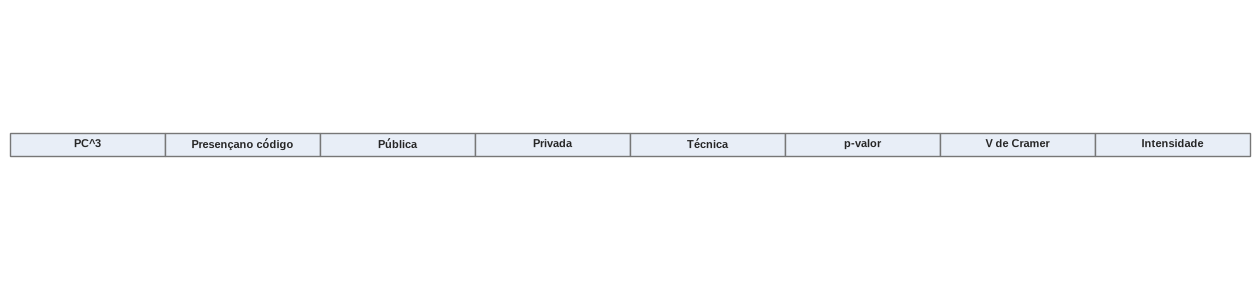

PDFs visuais gerados a partir de output/resultados/tabelas_latex.tex: 1


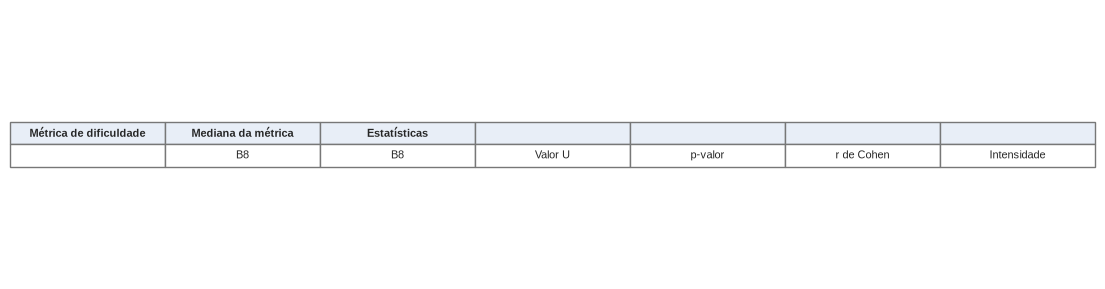

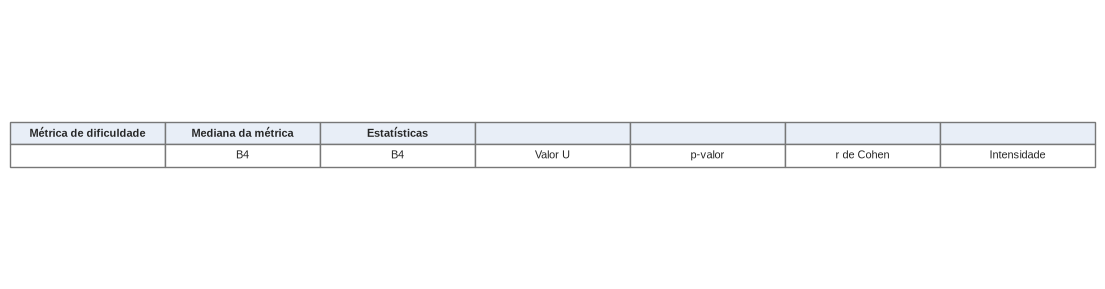

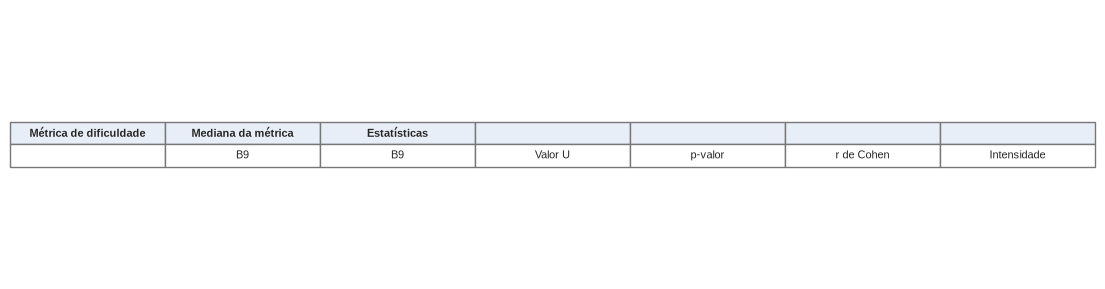

PDFs visuais gerados a partir de output/resultados/tabelas_comparacao_pc3.tex: 3

ANÁLISE FINALIZADA COM SUCESSO


In [61]:
from pathlib import Path
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import csv
from pathlib import Path
from collections import defaultdict
from scipy.stats import chi2_contingency



def formatar_pvalor(p_val):
    if p_val < 1e-16: return '<< 0,001'
    elif p_val < 1e-3: return '< 0,001'
    else: return f"{p_val:.3f}".replace('.', ',')

def formatar_numero(num):
    if isinstance(num, (int, np.integer)):
        return f"{num:,}".replace(',', '.')
    else:
        num_str = f"{num:.3f}"
        partes = num_str.split('.')
        parte_inteira = f"{int(partes[0]):,}".replace(',', '.')
        parte_decimal = partes[1].rstrip('0') if len(partes) > 1 else ''
        return f"{parte_inteira},{parte_decimal}" if parte_decimal else parte_inteira

def extrair_campo_user_data(conteudo, campo_busca):
    linhas = conteudo.split('\n')
    for linha in linhas:
        linha = linha.strip()
        if linha.startswith('----'):
            linha_limpa = linha.replace('----', '').strip()
            if linha_limpa.lower().startswith(campo_busca.lower() + ':'):
                if ':' in linha_limpa:
                    _, valor = linha_limpa.split(':', 1)
                    valor = valor.strip()
                    return valor if valor else None
    return None

def carregar_dados_usuarios():
    usuarios_catalogados = set()
    colunas_padrao = ['usuario', 'school_type', 'previous_experience', 'share_pc', 'worked_interned']

    try:
        with open(MISCONCEPTIONS_PATH, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for linha in reader:
                if 'usuario' in linha and linha['usuario']:
                    usuarios_catalogados.add(linha['usuario'])
    except FileNotFoundError:
        print(f"⚠️  Arquivo {MISCONCEPTIONS_PATH} não encontrado!")
        return pd.DataFrame(columns=colunas_padrao)

    if not USER_DATA_PATH.exists():
        print(f"⚠️  JSON de referências {USER_DATA_PATH} não existe!")
        return pd.DataFrame(columns=colunas_padrao)
    manifest = carregar_referencias(USER_DATA_PATH)

    dados_usuarios = []
    for usuario in usuarios_catalogados:
        arquivos_user_data = list(iterar_arquivos_usuario(manifest, usuario, 'user_data', 'user.data'))
        arquivo_user_data = arquivos_user_data[0] if arquivos_user_data else None

        if arquivo_user_data is not None:
            try:
                with open(arquivo_user_data, 'r', encoding='utf-8') as f:
                    conteudo = f.read()

                school_type     = extrair_campo_user_data(conteudo, "school type")
                previous_exp    = extrair_campo_user_data(conteudo, "previous experience of any computer language")
                share_pc        = extrair_campo_user_data(conteudo, "share this PC with other people at home")
                worked_interned = extrair_campo_user_data(conteudo, "worked or interned before the degree")

                if previous_exp and previous_exp.lower().startswith('yes'):
                    previous_exp = 'yes'

                dados_usuarios.append({
                    'usuario': usuario,
                    'school_type': school_type,
                    'previous_experience': previous_exp,
                    'share_pc': share_pc,
                    'worked_interned': worked_interned
                })
            except Exception:
                pass

    if not dados_usuarios:
        print(f"⚠️  Nenhum dado de usuário foi coletado!")
        return pd.DataFrame(columns=colunas_padrao)

    return pd.DataFrame(dados_usuarios)

def load_and_process_data():
    df_misc = pd.read_csv(MISCONCEPTIONS_PATH)
    df_misc['usuario'] = df_misc['usuario'].astype(str)

    for mi in PC3_MAP.values():
        df_misc[f'tem_{mi}'] = False

    counts = defaultdict(lambda: defaultdict(int))
    for _, row in df_misc.iterrows():
        misc_str = str(row['misconceptions_detectados'])
        if misc_str != 'nan':
            for mi in [m.strip() for m in misc_str.split(',')]:
                if mi in PC3_MAP.values():
                    counts[mi][str(row['usuario'])] += 1

    for mi in PC3_MAP.values():
        col = f'tem_{mi}'
        for u, count in counts[mi].items():
            df_misc.loc[df_misc['usuario'] == u, col] = count > 0

    df_usuarios = carregar_dados_usuarios()
    return df_misc.merge(df_usuarios, on='usuario', how='left')

def calcular_estatisticas_contingencia(crosstab):
    try:
        chi2, p_val, dof, exp = chi2_contingency(crosstab)
        n = crosstab.sum().sum()
        min_dim = min(crosstab.shape) - 1
        v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
        return chi2, p_val, v
    except:
        return None, None, None

def get_top_misconceptions(df, n=None):
    """Retorna PC³ elegíveis pelo filtro global e, opcionalmente, limita os mais frequentes.

    O critério mínimo é aplicado sempre. Quando n=None, todos os PC³ com
    pelo menos PC3_MIN_OCCURRENCES são retornados.
    """
    candidatos=[]
    for pc in PC3_MAP:
        if pc not in df.columns:
            continue
        total=pd.to_numeric(df[pc], errors='coerce').fillna(0).sum()
        if total >= PC3_MIN_OCCURRENCES:
            candidatos.append((pc, total))
    candidatos.sort(key=lambda item: (-item[1], item[0]))
    if n is not None:
        candidatos=candidatos[:int(n)]
    return [pc for pc, _ in candidatos]
def calcular_cobertura_fator(df, coluna_fator, labels_validos, total_alunos_global, total_codigos_global):
    df_por_usuario = df.drop_duplicates(subset='usuario')
    mask_valido = df_por_usuario[coluna_fator].isin(labels_validos)
    alunos_com = mask_valido.sum()
    alunos_sem = len(df_por_usuario) - alunos_com
    mask_cod = df[coluna_fator].isin(labels_validos)
    codigos_com = mask_cod.sum()
    codigos_sem = len(df) - codigos_com
    pct_alunos  = 100 * alunos_com  / total_alunos_global  if total_alunos_global  > 0 else 0
    pct_codigos = 100 * codigos_com / total_codigos_global if total_codigos_global > 0 else 0
    return {
        'alunos_com':   alunos_com,
        'alunos_sem':   alunos_sem,
        'codigos_com':  codigos_com,
        'codigos_sem':  codigos_sem,
        'pct_alunos':   pct_alunos,
        'pct_codigos':  pct_codigos,
    }

def desenhar_tabela_no_eixo(ax, mi_name, fator_nome, categorias, crosstab, p_value, cramers_v,
                            significativo=True):
    TRADUCAO_CATEGORIAS = {
        'yes': 'Sim', 'no': 'Não', 'public school': 'Pública',
        'private school': 'Privada', 'technical school': 'Técnica'
    }
    categorias_pt  = [TRADUCAO_CATEGORIAS.get(cat, cat) for cat in categorias]
    n_categorias   = len(categorias_pt)
    cor_header   = '#34495e'
    cor_border   = '#2c3e50'
    cor_texto    = '#2c3e50'
    cor_destaque = '#3498db'
    table_top  = 8.0
    cell_width = 1.8 if n_categorias == 2 else 1.5
    cell_height = 1.2
    start_x    = 5 - (cell_width * (n_categorias + 1)) / 2
    largura_total = cell_width * (n_categorias + 1)

    ax.add_patch(FancyBboxPatch((start_x, table_top), largura_total, cell_height,
                                boxstyle="round,pad=0.05", edgecolor=cor_border,
                                facecolor=cor_header, linewidth=2))
    ax.text(start_x + largura_total / 2, table_top + cell_height / 2, fator_nome,
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')

    table_top2 = table_top - cell_height
    ax.add_patch(FancyBboxPatch((start_x, table_top2), cell_width, cell_height,
                                boxstyle="round,pad=0.05", edgecolor=cor_border,
                                facecolor=cor_destaque, linewidth=2))
    ax.text(start_x + cell_width / 2, table_top2 + cell_height / 2, 'PC³',
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')

    for i, cat_nome in enumerate(categorias_pt):
        x_cat = start_x + cell_width + i * cell_width
        ax.add_patch(FancyBboxPatch((x_cat, table_top2), cell_width, cell_height,
                                    boxstyle="round,pad=0.05", edgecolor=cor_border,
                                    facecolor=cor_destaque, linewidth=2))
        ax.text(x_cat + cell_width / 2, table_top2 + cell_height / 2, cat_nome,
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')

    table_top3 = table_top2 - cell_height
    ax.add_patch(FancyBboxPatch((start_x, table_top3), cell_width, cell_height,
                                boxstyle="round,pad=0.05", edgecolor=cor_border,
                                facecolor='#e8f5e9', linewidth=2))
    ax.text(start_x + cell_width / 2, table_top3 + cell_height / 2, f'{mi_name}',
            ha='center', va='center', fontsize=12, fontweight='bold', color=cor_texto)

    for i, cat in enumerate(categorias):
        x_val = start_x + cell_width + i * cell_width
        val   = crosstab.loc[cat, True]  if (cat in crosstab.index and True  in crosstab.columns) else 0
        pct   = (val / crosstab.loc[cat].sum() * 100) if crosstab.loc[cat].sum() > 0 else 0
        ax.add_patch(FancyBboxPatch((x_val, table_top3), cell_width, cell_height,
                                    boxstyle="round,pad=0.05", edgecolor=cor_border,
                                    facecolor='white', linewidth=2))
        ax.text(x_val + cell_width / 2, table_top3 + cell_height / 2,
                f'{formatar_numero(val)}\n({round(pct):.0f}%)',
                ha='center', va='center', fontsize=11, color=cor_texto)

    table_top4 = table_top3 - cell_height
    ax.add_patch(FancyBboxPatch((start_x, table_top4), cell_width, cell_height,
                                boxstyle="round,pad=0.05", edgecolor=cor_border,
                                facecolor='#ffebee', linewidth=2))
    ax.text(start_x + cell_width / 2, table_top4 + cell_height / 2, f'~{mi_name}',
            ha='center', va='center', fontsize=12, fontweight='bold', color=cor_texto)

    for i, cat in enumerate(categorias):
        x_val = start_x + cell_width + i * cell_width
        val   = crosstab.loc[cat, False] if (cat in crosstab.index and False in crosstab.columns) else 0
        pct   = (val / crosstab.loc[cat].sum() * 100) if crosstab.loc[cat].sum() > 0 else 0
        ax.add_patch(FancyBboxPatch((x_val, table_top4), cell_width, cell_height,
                                    boxstyle="round,pad=0.05", edgecolor=cor_border,
                                    facecolor='white', linewidth=2))
        ax.text(x_val + cell_width / 2, table_top4 + cell_height / 2,
                f'{formatar_numero(val)}\n({round(pct):.0f}%)',
                ha='center', va='center', fontsize=11, color=cor_texto)

    stats_width  = 6.0
    stats_height = 1.8
    stats_x = 5 - stats_width / 2
    stats_y = table_top4 - 0.5 - stats_height

    ax.add_patch(FancyBboxPatch((stats_x, stats_y), stats_width, stats_height,
                                boxstyle="round,pad=0.05", edgecolor=cor_border,
                                facecolor='#f8f9fa', linewidth=2))

    if significativo:
        p_str   = formatar_pvalor(p_value)
        v_str   = formatar_numero(cramers_v)
        int_str = ("Muito Forte" if cramers_v > 0.25 else
                   "Forte"       if cramers_v > 0.15 else
                   "Moderado"    if cramers_v > 0.10 else
                   "Fraco"       if cramers_v > 0.05 else "Muito Fraco")
        cor_stat = '#2c3e50'
    else:
        p_str   = formatar_pvalor(p_value) if p_value is not None else 'NS'
        v_str   = 'NS'
        int_str = 'NS'
        cor_stat = '#999999'

    ax.text(5, stats_y + stats_height * 0.75, f'valor-p: {p_str}',
            ha='center', va='center', fontsize=12, fontweight='bold', color=cor_stat)
    ax.text(5, stats_y + stats_height * 0.50, f'V de Cramer: {v_str}',
            ha='center', va='center', fontsize=12, fontweight='bold', color=cor_stat)
    ax.text(5, stats_y + stats_height * 0.25, f'Intensidade: {int_str}',
            ha='center', va='center', fontsize=12, fontweight='bold', color=cor_stat)

    padding = 0.05
    ax.set_xlim(start_x - padding, start_x + largura_total + padding)
    ax.set_ylim(stats_y - padding, table_top + cell_height + padding)
    ax.axis('off')

def desenhar_rodape_cobertura(fig, cob, total_alunos, total_codigos):
    cor_fundo   = '#eaf4fb'
    cor_borda   = '#2980b9'
    cor_titulo  = '#1a5276'
    cor_ok      = '#1e8449'
    cor_falta   = '#922b21'

    ax_rod = fig.add_axes([0.02, 0.01, 0.96, 0.07])
    ax_rod.set_xlim(0, 1)
    ax_rod.set_ylim(0, 1)
    ax_rod.axis('off')

    ax_rod.add_patch(FancyBboxPatch((0, 0), 1, 1,
                                    boxstyle="round,pad=0.01",
                                    edgecolor=cor_borda, facecolor=cor_fundo,
                                    linewidth=1.5, transform=ax_rod.transAxes))

    ax_rod.text(0.5, 0.82, '📊 Cobertura dos dados neste fator',
                ha='center', va='center', fontsize=9, fontweight='bold',
                color=cor_titulo, transform=ax_rod.transAxes)

    txt_alunos_ok   = (f"✔ Alunos com dado: {formatar_numero(int(cob['alunos_com']))} "
                       f"/ {formatar_numero(total_alunos)} "
                       f"({cob['pct_alunos']:.1f}%)")
    txt_alunos_falt = (f"✘ Sem dado: {formatar_numero(int(cob['alunos_sem']))} "
                       f"({100 - cob['pct_alunos']:.1f}%)")
    txt_cod_ok   = (f"✔ Códigos com dado: {formatar_numero(int(cob['codigos_com']))} "
                    f"/ {formatar_numero(total_codigos)} "
                    f"({cob['pct_codigos']:.1f}%)")
    txt_cod_falt = (f"✘ Sem dado: {formatar_numero(int(cob['codigos_sem']))} "
                    f"({100 - cob['pct_codigos']:.1f}%)")

    ax_rod.text(0.02, 0.45, txt_alunos_ok,  ha='left', va='center', fontsize=8.5,
                color=cor_ok,   transform=ax_rod.transAxes, fontweight='bold')
    ax_rod.text(0.30, 0.45, txt_alunos_falt, ha='left', va='center', fontsize=8.5,
                color=cor_falta, transform=ax_rod.transAxes, fontweight='bold')
    ax_rod.text(0.02, 0.15, txt_cod_ok,   ha='left', va='center', fontsize=8.5,
                color=cor_ok,   transform=ax_rod.transAxes, fontweight='bold')
    ax_rod.text(0.30, 0.15, txt_cod_falt,  ha='left', va='center', fontsize=8.5,
                color=cor_falta, transform=ax_rod.transAxes, fontweight='bold')

def gerar_figuras_agrupadas(df, top_misconceptions, grupos_analise,
                             total_alunos_global, total_codigos_global):
    TRADUCAO_FATORES = {
        'school_type':        'Tipo de Escola',
        'previous_experience':'Experiência Prévia com Programação',
        'share_pc':           'Compartilha PC em Casa',
        'worked_interned':    'Trabalhou ou Estagiou Antes do Curso'
    }

    figuras_por_fator = {}

    for grupo in grupos_analise:
        fator_nome       = TRADUCAO_FATORES.get(grupo['column'], grupo['title'])
        resultados_fator = []

        cob = calcular_cobertura_fator(
            df, grupo['column'], grupo['labels'],
            total_alunos_global, total_codigos_global
        )

        for mi_name in top_misconceptions:
            mi_column = f'tem_{mi_name}'
            df_valid  = df[df[grupo['column']].notna()].copy()
            if len(df_valid) > 0 and mi_column in df_valid.columns:
                crosstab = pd.crosstab(df_valid[grupo['column']], df_valid[mi_column])
                if True in crosstab.columns and False in crosstab.columns:
                    labels_presentes = [l for l in grupo['labels'] if l in crosstab.index]
                    if len(labels_presentes) >= 2:
                        crosstab_filtrado = crosstab.loc[labels_presentes]
                        chi2, p_value, cramers_v = calcular_estatisticas_contingencia(crosstab_filtrado)
                        significativo = (p_value is not None and cramers_v is not None
                                         and p_value < 0.05)
                        resultados_fator.append({
                            'mi': mi_name, 'categorias': labels_presentes,
                            'crosstab': crosstab_filtrado,
                            'p_value': p_value, 'cramers_v': cramers_v,
                            'significativo': significativo
                        })

        if resultados_fator:
            resultados_fator = sorted(resultados_fator, key=lambda x: (x['cramers_v'] or 0), reverse=True)

            n_tabelas = len(resultados_fator)
            cols      = min(n_tabelas, 3)
            rows      = (n_tabelas + cols - 1) // cols

            n_cat  = len(grupo['labels'])
            base_w = 6 if n_cat == 2 else 7
            base_h = 7

            fig, axes = plt.subplots(rows, cols,
                                     figsize=(base_w * cols, base_h * rows + 1.0))
            fig.subplots_adjust(bottom=0.10)

            if n_tabelas == 1:
                axes = np.array([axes])
            axes_flat = axes.flatten()

            for i, res in enumerate(resultados_fator):
                desenhar_tabela_no_eixo(
                    axes_flat[i], res['mi'], fator_nome, res['categorias'],
                    res['crosstab'], res['p_value'], res['cramers_v'],
                    significativo=res['significativo']
                )

            for j in range(i + 1, len(axes_flat)):
                axes_flat[j].axis('off')

            desenhar_rodape_cobertura(fig, cob, total_alunos_global, total_codigos_global)

            fig.subplots_adjust(left=0.03, right=0.97, top=0.95, bottom=0.14, wspace=0.30, hspace=0.35)
            figuras_por_fator[fator_nome] = fig

            print(f"\n  [{fator_nome}]")
            print(f"    Alunos  com dado: {cob['alunos_com']:>6} / {total_alunos_global} "
                  f"({cob['pct_alunos']:.1f}%)  |  sem dado: {cob['alunos_sem']} "
                  f"({100-cob['pct_alunos']:.1f}%)")
            print(f"    Códigos com dado: {cob['codigos_com']:>6} / {total_codigos_global} "
                  f"({cob['pct_codigos']:.1f}%)  |  sem dado: {cob['codigos_sem']} "
                  f"({100-cob['pct_codigos']:.1f}%)")

    return figuras_por_fator


# =============================================================================
# GERAÇÃO DE CÓDIGO LATEX ORDENADO PELO MENOR P-VALOR
# =============================================================================

def formatar_pvalor_latex(p_val):
    if p_val is None:
        return 'NS'
    if p_val < 1e-16:
        return r'$\ll$ 0,001'
    elif p_val < 1e-3:
        return r'$<$ 0,001'
    else:
        return f"{p_val:.3f}".replace('.', ',')

def formatar_cramers_latex(v, significativo):
    if not significativo or v is None:
        return 'NS'
    return f"{v:.3f}".replace('.', ',')

def intensidade_latex(v, significativo):
    if not significativo or v is None:
        return 'NS'
    if v > 0.25: return 'Muito forte'
    if v > 0.15: return 'Forte'
    if v > 0.10: return 'Moderado'
    if v > 0.05: return 'Fraco'
    return 'Muito fraco'

def calcular_dados_latex(df, grupo, top_misconceptions):
    resultados = []
    for mi_name in top_misconceptions:
        mi_column = f'tem_{mi_name}'
        df_valid  = df[df[grupo['column']].notna()].copy()
        if len(df_valid) == 0 or mi_column not in df_valid.columns:
            continue

        crosstab = pd.crosstab(df_valid[grupo['column']], df_valid[mi_column])
        if True not in crosstab.columns or False not in crosstab.columns:
            continue

        labels_presentes = [l for l in grupo['labels'] if l in crosstab.index]
        if len(labels_presentes) < 2:
            continue

        crosstab_f = crosstab.loc[labels_presentes]
        chi2, p_value, cramers_v = calcular_estatisticas_contingencia(crosstab_f)
        significativo = (p_value is not None and cramers_v is not None and p_value < 0.05)

        cats = {}
        for label in labels_presentes:
            total_cat = crosstab_f.loc[label].sum()
            val_pres  = int(crosstab_f.loc[label, True])  if True  in crosstab_f.columns else 0
            val_aus   = int(crosstab_f.loc[label, False]) if False in crosstab_f.columns else 0
            pct_pres  = round(100 * val_pres / total_cat) if total_cat > 0 else 0
            pct_aus   = 100 - pct_pres
            cats[label] = {
                'presente': val_pres, 'pct_pres': pct_pres,
                'ausente':  val_aus,  'pct_aus':  pct_aus,
            }

        resultados.append({
            'mi':            mi_name,
            'labels':        labels_presentes,
            'cats':          cats,
            'p_value':       p_value if p_value is not None else 1.0, # Atribui 1.0 para jogar NS para o fim
            'cramers_v':     cramers_v,
            'significativo': significativo,
        })

    # CORREÇÃO DA ORDENAÇÃO: Ordena explicitamente pelo menor p-valor
    resultados.sort(key=lambda x: x['p_value'])
    return resultados


def gerar_tablenotes(alunos_sem, codigos_sem, tem_ns=True):
    itens = []
    if alunos_sem > 0 or codigos_sem > 0:
        n_alunos  = formatar_numero(int(alunos_sem))
        n_codigos = formatar_numero(int(codigos_sem))
        itens.append(
            f"        \\item Informações de {n_alunos} estudante(s) e "
            f"{n_codigos} código(s) submetido(s) não puderam ser "
            f"recuperadas no repositório no momento da coleta e não "
            f"foram incluídas nesta análise."
        )
    itens.append(r"        \item NS: não significativo")
    corpo = "\n".join(itens)
    return f"\n    \\begin{{tablenotes}}\n{corpo}\n    \\end{{tablenotes}}"


def gerar_latex_escola(df, top_misconceptions, alunos_sem=0, codigos_sem=0):
    grupo = {
        'column': 'school_type',
        'labels': ('public school', 'private school', 'technical school'),
    }
    dados = calcular_dados_latex(df, grupo, top_misconceptions)
    tem_ns = any(not d['significativo'] for d in dados)

    linhas = []
    for i, d in enumerate(dados):
        PCT = r'\%'
        if i > 0:
            linhas.append(r'        \midrule')
        cats = d['cats']
        pub  = cats.get('public school',    {'presente': 0, 'pct_pres': 0, 'ausente': 0, 'pct_aus': 0})
        pri  = cats.get('private school',   {'presente': 0, 'pct_pres': 0, 'ausente': 0, 'pct_aus': 0})
        tec  = cats.get('technical school', {'presente': 0, 'pct_pres': 0, 'ausente': 0, 'pct_aus': 0})

        # Restaura o p-valor real para exibição se ele foi mascarado para ordenação
        p_real = None if d['p_value'] == 1.0 and not d['significativo'] else d['p_value']
        p_tex = formatar_pvalor_latex(p_real)
        v_tex = formatar_cramers_latex(d['cramers_v'], d['significativo'])
        i_tex = intensidade_latex(d['cramers_v'], d['significativo'])

        linhas.append(
            f"        {d['mi']} & Presente & "
            f"{formatar_numero(pub['presente'])} ({pub['pct_pres']}{PCT}) & "
            f"{formatar_numero(pri['presente'])} ({pri['pct_pres']}{PCT}) & "
            f"{formatar_numero(tec['presente'])} ({tec['pct_pres']}{PCT}) & "
            f"{p_tex} & {v_tex} & {i_tex} \\\\"
        )
        linhas.append(
            f"           & Ausente & "
            f"{formatar_numero(pub['ausente'])} ({pub['pct_aus']}{PCT}) & "
            f"{formatar_numero(pri['ausente'])} ({pri['pct_aus']}{PCT}) & "
            f"{formatar_numero(tec['ausente'])} ({tec['pct_aus']}{PCT}) & & & \\\\"
        )

    corpo      = "\n".join(linhas)
    tablenotes = gerar_tablenotes(alunos_sem, codigos_sem, tem_ns=tem_ns)

    return (
        r"\begin{table}[H]" "\n"
        r"    \centering\footnotesize" "\n"
        r"    \setlength{\tabcolsep}{6pt}" "\n"
        r"    \begin{threeparttable}" "\n"
        r"    \caption{Quantidade de códigos com presença/ausência de PC$^3$, "
        r"distribuídos conforme o tipo de escola do Ensino Médio de origem do aluno "
        r"(convencional pública, convencional privada ou técnica). Fonte: }" "\n"
        r"    \label{tab:misconceptions_escola}" "\n"
        r"    \begin{tabular}{ll rrr ccc}" "\n"
        r"        \toprule" "\n"
        r"        \textbf{PC$^3$} & \textbf{\vtop{\hbox{Presença}\hbox{no código}}} & \textbf{Pública} & "
        r"\textbf{Privada} & \textbf{Técnica} & \textbf{$p$-valor} & "
        r"\textbf{V de Cramer} & \textbf{Intensidade} \\" "\n"
        r"        \midrule" "\n"
        f"{corpo}" "\n"
        r"        \bottomrule" "\n"
        r"    \end{tabular}" "\n"
        f"{tablenotes}" "\n"
        r"    \end{threeparttable}" "\n"
        r"\end{table}"
    )


def gerar_latex_dois_grupos(df, top_misconceptions, grupo, caption, label, col_sim, col_nao,
                            alunos_sem=0, codigos_sem=0):
    dados = calcular_dados_latex(df, grupo, top_misconceptions)
    if not dados:
        return None

    tem_ns = any(not d['significativo'] for d in dados)
    label_sim = grupo['labels'][0]
    label_nao = grupo['labels'][1]

    linhas = []
    for i, d in enumerate(dados):
        PCT = r'\%'
        if i > 0:
            linhas.append(r'        \midrule')
        cats = d['cats']
        sim  = cats.get(label_sim, {'presente': 0, 'pct_pres': 0, 'ausente': 0, 'pct_aus': 0})
        nao  = cats.get(label_nao, {'presente': 0, 'pct_pres': 0, 'ausente': 0, 'pct_aus': 0})

        p_real = None if d['p_value'] == 1.0 and not d['significativo'] else d['p_value']
        p_tex = formatar_pvalor_latex(p_real)
        v_tex = formatar_cramers_latex(d['cramers_v'], d['significativo'])
        i_tex = intensidade_latex(d['cramers_v'], d['significativo'])

        linhas.append(
            f"        {d['mi']} & Presente & "
            f"{formatar_numero(sim['presente'])} ({sim['pct_pres']}{PCT}) & "
            f"{formatar_numero(nao['presente'])} ({nao['pct_pres']}{PCT}) & "
            f"{p_tex} & {v_tex} & {i_tex} \\\\"
        )
        linhas.append(
            f"           & Ausente & "
            f"{formatar_numero(sim['ausente'])} ({sim['pct_aus']}{PCT}) & "
            f"{formatar_numero(nao['ausente'])} ({nao['pct_aus']}{PCT}) & & & \\\\"
        )

    corpo      = "\n".join(linhas)
    tablenotes = gerar_tablenotes(alunos_sem, codigos_sem, tem_ns=tem_ns)

    return (
        r"\begin{table}[H]" "\n"
        r"    \centering\footnotesize" "\n"
        r"    \setlength{\tabcolsep}{7pt}" "\n"
        r"    \begin{threeparttable}" "\n"
        f"    \\caption{{{caption}}}" "\n"
        f"    \\label{{{label}}}" "\n"
        r"    \begin{tabular}{ll rr ccc}" "\n"
        r"        \toprule" "\n"
        f"        \\textbf{{PC$^3$}} & \\textbf{{\\vtop{{\\hbox{{Presença}}\\hbox{{no código}}}}}} & \\textbf{{{col_sim}}} & "
        f"\\textbf{{{col_nao}}} & \\textbf{{$p$-valor}} & "
        r"\textbf{V de Cramer} & \textbf{Intensidade} \\" "\n"
        r"        \midrule" "\n"
        f"        {corpo}" "\n"
        r"        \bottomrule" "\n"
        r"    \end{tabular}" "\n"
        f"{tablenotes}" "\n"
        r"    \end{threeparttable}" "\n"
        r"\end{table}"
    )


def _formatar_numero_tabela(valor, casas=2):
    if pd.isna(valor):
        return "—"
    return f"{float(valor):,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

def _formatar_p_tabela(valor):
    if pd.isna(valor):
        return "NS"
    if valor < 0.001:
        return r"$<$ 0,001"
    return f"{valor:.3f}".replace(".", ",")

def _intensidade_efeito(r):
    if pd.isna(r):
        return "NS"
    a=abs(float(r))
    if a < 0.10: return "muito fraco"
    if a < 0.30: return "pequeno"
    if a < 0.50: return "médio"
    return "grande"

def gerar_tabelas_comparacao_pc3(df, output_dir=RESULTS_DIR):
    """Gera tabelas LaTeX e CSV para todos os PC³ que passam o limite global."""
    from scipy.stats import mannwhitneyu, norm
    metricas={
        'MD1: Taxa de acerto (\\%)':'taxa_acerto',
        'MD2: Número de submissões':'num_submissoes',
        'MD3: Taxa de aceitação (\\%)':'taxa_aceitacao',
        'MD4: Número de testes':'num_testes',
        'MD5: Total de consultas':'num_consultas',
        'MD6: Erros de lógica':'num_erros_lgcs',
        'MD7: Erros de sintaxe':'num_errors_stx',
        'MD8: Total de erros':'num_erros',
        'MD9: Eventos deleção':'num_eventos_del',
        'MD10: Total de eventos':'num_eventos',
        'MD11: Tempo de implementação (s)':'tempo_implementacao',
        'MD12: Alterações no código':'qtd_alteracoes_codigo',
        'MD13: Discriminação':'discriminacao',
    }
    output_dir=Path(output_dir); output_dir.mkdir(parents=True,exist_ok=True)
    blocos=[]; row_end=r"\\"
    # Nenhuma linha elegível não é um erro: não há tabela estatística a gerar.
    if df is None or df.empty:
        print("Nenhum dado disponível para gerar tabelas de comparação PC³; etapa ignorada.")
        return pd.DataFrame()
    # A comparação é por questão. Se receber dados individuais, agrega as
    # métricas por questão e conta quantos estudantes apresentaram cada PC³.
    df_comparacao=df.copy()
    if 'question' in df_comparacao.columns and not any(pc in df_comparacao.columns for pc in ('B4','B8','B9')):
        agg_cols={c:'median' for c in metricas.values() if c in df_comparacao.columns}
        if agg_cols:
            df_comparacao=df_comparacao.groupby('question',as_index=False).agg(agg_cols)
        else:
            # Evita pandas GroupBy.aggregate -> "No objects to concatenate".
            # Mantém uma linha por questão para permitir a saída vazia normal.
            df_comparacao=df_comparacao[['question']].drop_duplicates().reset_index(drop=True)
        for _pc in ('B4','B8','B9'):
            _flag=f'tem_{_pc}'
            if _flag in df.columns:
                _counts=df.groupby('question')[_flag].sum().rename(_pc)
                df_comparacao=df_comparacao.merge(_counts,on='question',how='left')
    # Sem colunas PC³, não há comparações possíveis; retorna saída vazia.
    if df_comparacao.empty:
        print("Nenhuma questão disponível para tabelas de comparação PC³; etapa ignorada.")
        return pd.DataFrame()
    # Seleciona dinamicamente todos os PC³ que passaram pelo filtro global.
    pc3_disponiveis=[pc for pc in PC3_MAP if pc in df_comparacao.columns]
    pc3_selecionados=[]
    for pc in pc3_disponiveis:
        total=pd.to_numeric(df_comparacao[pc],errors='coerce').fillna(0).sum()
        if total >= PC3_MIN_OCCURRENCES:
            pc3_selecionados.append((pc,total))
    pc3_selecionados.sort(key=lambda item:(-item[1],item[0]))
    if TOP_N_PC3 is not None:
        pc3_selecionados=pc3_selecionados[:int(TOP_N_PC3)]
    pc3_selecionados=[pc for pc,_ in pc3_selecionados]
    print(f"PC³ selecionados para tabelas (>= {PC3_MIN_OCCURRENCES} ocorrências): {pc3_selecionados}")
    for pc in pc3_selecionados:
        grupo=pd.to_numeric(df_comparacao[pc],errors='coerce').fillna(0)>=5; linhas=[]
        for nome,col in metricas.items():
            if col not in df.columns: continue
            a=pd.to_numeric(df_comparacao.loc[grupo,col],errors='coerce').dropna()
            b=pd.to_numeric(df_comparacao.loc[~grupo,col],errors='coerce').dropna()
            if len(a)==0 or len(b)==0: continue
            u,pv=mannwhitneyu(a,b,alternative='two-sided'); n=len(a)+len(b)
            z=norm.isf(pv/2) if pv>0 else norm.isf(1e-300)
            r=abs(z)/(n**0.5) if n else float('nan')
            linhas.append({'metrica':nome,'coluna':col,'mediana_pc3':a.median(),'mediana_sem_pc3':b.median(),'u':u,'p_valor':pv,'r_efeito':r,'intensidade':_intensidade_efeito(r),'n_pc3':len(a),'n_sem_pc3':len(b)})
        linhas.sort(key=lambda x:-abs(x['r_efeito']) if not pd.isna(x['r_efeito']) else 0)
        pd.DataFrame(linhas).to_csv(output_dir/f'comparacao_{pc}.csv',index=False)
        tex=[r"\\begin{table}[H]",r"    \\centering\\footnotesize",
             f"    \\caption{{Comparação de questões em que cinco ou mais estudantes cometeram o PC$^3$ {pc} ($\\supset$ {pc}) com questões em que menos de cinco alunos cometeram esse PC$^3$ ($\\not\\supset$ {pc}), por métrica de dificuldade, ordenadas pelo tamanho do efeito (intensidade da diferença).}}",
             f"    \\label{{tab:comparacao{pc}}}",r"    \\begin{threeparttable}",r"    \\begin{tabular}{l rr rr rr}",r"        \\toprule"]
        tex.append("        \\textbf{Métrica de dificuldade} & \\multicolumn{2}{c}{\\textbf{Mediana da métrica}} & \\multicolumn{4}{c}{\\textbf{Estatísticas}} " + row_end)
        tex.append(r"        \\cmidrule(lr){2-3} \\cmidrule(lr){4-7}")
        tex.append(f"         & \\textbf{{${{\\supset}}$ {pc}}} & \\textbf{{${{\\not\\supset}}$ {pc}}} & \\textbf{{Valor U}} & \\textbf{{$p$-valor}} & \\textbf{{r de Cohen}} & \\textbf{{Intensidade}} " + row_end + r"        \\midrule")
        for j,x in enumerate(linhas):
            eff=_formatar_numero_tabela(x['r_efeito']) if x['p_valor']<0.05 else 'NS'; inten=x['intensidade'] if x['p_valor']<0.05 else 'NS'
            tex.append(f"        {x['metrica']} & {_formatar_numero_tabela(x['mediana_pc3'])} & {_formatar_numero_tabela(x['mediana_sem_pc3'])} & {_formatar_numero_tabela(x['u'],0)} & {_formatar_p_tabela(x['p_valor'])} & {eff} & {inten} " + row_end)
            if j < len(linhas)-1: tex.append(r"        \\midrule")
        tex += [r"        \\bottomrule",r"    \\end{tabular}",r"    \\begin{tablenotes}",r"        \\item Salvo quando indicado o contrário, a unidade de medida é contagem.",r"        \\item NS: não significativo",r"    \\end{tablenotes}",r"    \\end{threeparttable}",r"\\end{table}"]
        blocos.append('\n'.join(tex))
    out_tex=output_dir/'tabelas_comparacao_pc3.tex'; out_tex.write_text('\n\n'.join(blocos),encoding='utf-8')
    print(f"\nTabelas de comparação PC³ salvas em: {out_tex}")
    return '\n\n'.join(blocos)

def gerar_todos_latex(df, top_misconceptions, arquivo_saida=RESULTS_DIR / "tabelas_latex.tex"):
    blocos = []
    total_alunos  = df['usuario'].nunique()
    total_codigos = len(df)

    def _cob(column, labels):
        df_u  = df.drop_duplicates(subset='usuario')
        a_com = df_u[column].isin(labels).sum()
        c_com = df[column].isin(labels).sum()
        return int(total_alunos - a_com), int(total_codigos - c_com)

    # Tabela 1: Tipo de escola
    labels_escola = ('public school', 'private school', 'technical school')
    a_sem_esc, c_sem_esc = _cob('school_type', labels_escola)
    blocos.append(gerar_latex_escola(df, top_misconceptions,
                                     alunos_sem=a_sem_esc, codigos_sem=c_sem_esc))

    # Tabela 2: Compartilha PC em casa
    grupo_pc = {'column': 'share_pc', 'labels': ('yes', 'no')}
    a_sem_pc, c_sem_pc = _cob('share_pc', ('yes', 'no'))
    tex_pc = gerar_latex_dois_grupos(
        df, top_misconceptions, grupo_pc,
        caption="Distribuição dos PC$^3$ por compartilhamento de computador pessoal em casa",
        label="tab:misconceptions_pc_casa",
        col_sim="Sim", col_nao="Não",
        alunos_sem=a_sem_pc, codigos_sem=c_sem_pc
    )
    if tex_pc: blocos.append(tex_pc)

    # Tabela 3: Experiencia previa em programacao
    grupo_exp = {'column': 'previous_experience', 'labels': ('yes', 'no')}
    a_sem_exp, c_sem_exp = _cob('previous_experience', ('yes', 'no'))
    tex_exp = gerar_latex_dois_grupos(
        df, top_misconceptions, grupo_exp,
        caption="Distribuição dos PC$^3$ por experiência prévia em programação",
        label="tab:misconceptionsExperienciaPrevia",
        col_sim="Sim", col_nao="Não",
        alunos_sem=a_sem_exp, codigos_sem=c_sem_exp
    )
    if tex_exp: blocos.append(tex_exp)

    # Tabela 4: Trabalhou/estagiou antes do curso
    grupo_trab = {'column': 'worked_interned', 'labels': ('yes', 'no')}
    a_sem_trab, c_sem_trab = _cob('worked_interned', ('yes', 'no'))
    tex_trab = gerar_latex_dois_grupos(
        df, top_misconceptions, grupo_trab,
        caption="Distribuição dos PC$^3$ por experiência profissional prévia",
        label="tab:misconceptions_experiencia_profissional",
        col_sim="Sim", col_nao="Não",
        alunos_sem=a_sem_trab, codigos_sem=c_sem_trab
    )
    if tex_trab: blocos.append(tex_trab)

    conteudo = "\n\n".join(str(b) for b in blocos)
    with open(arquivo_saida, 'w', encoding='utf-8') as f:
        f.write(conteudo)

    print(f"\n Código LaTeX salvo em: {arquivo_saida}")
    return conteudo


# Exportação visual opcional das mesmas tabelas geradas em LaTeX.
# O .tex continua sendo a saída editável e principal.
GERAR_PDF_TABELAS = True
MOSTRAR_PREVIEW_TABELAS = False


def _limpar_latex_para_pdf(valor):
    """Converte o texto de uma célula LaTeX em texto legível no PDF."""
    import re
    valor = re.sub(r'\\textbf\{([^}]*)\}', r'\1', str(valor))
    valor = re.sub(r'\\multicolumn\{[^}]*\}\{[^}]*\}\{([^}]*)\}', r'\1', valor)
    valor = re.sub(r'\$([^$]*)\$', r'\1', valor)
    valor = re.sub(r'\\[a-zA-Z]+', '', valor)
    return valor.replace('{', '').replace('}', '').replace('~', ' ').strip()


def gerar_pdfs_visuais_de_tex(caminho_tex, prefixo_pdf=None, mostrar=False):
    """Renderiza cada tabular de um .tex em PDF visual sem alterar o .tex."""
    import re
    import matplotlib.pyplot as plt
    caminho_tex = Path(caminho_tex)
    if not caminho_tex.exists():
        print(f"⚠️ Arquivo LaTeX não encontrado para PDF: {caminho_tex}")
        return []
    conteudo = caminho_tex.read_text(encoding='utf-8')
    blocos = re.findall(r'\\begin\{tabular\}.*?\\end\{tabular\}', conteudo, flags=re.S)
    saidas=[]
    prefixo_pdf = prefixo_pdf or caminho_tex.stem
    for indice, bloco in enumerate(blocos, 1):
        linhas=[]
        for linha in bloco.splitlines():
            linha=linha.strip()
            if not linha or linha.startswith('\\begin') or linha.startswith('\\end'):
                continue
            if any(linha.startswith(x) for x in ('\\toprule','\\midrule','\\bottomrule','\\cmidrule')):
                continue
            if '&' not in linha or '\\\\' not in linha:
                continue
            linha=linha.split('\\\\',1)[0]
            celulas=[_limpar_latex_para_pdf(x) for x in linha.split('&')]
            if any(celulas): linhas.append(celulas)
        if not linhas: continue
        ncol=max(len(x) for x in linhas)
        linhas=[x+['']*(ncol-len(x)) for x in linhas]
        fig,ax=plt.subplots(figsize=(max(10, ncol*2.0), max(3.5, min(18, len(linhas)*0.42+1.5))))
        ax.axis('off')
        tabela=ax.table(cellText=linhas, loc='center', cellLoc='center', colLoc='center')
        tabela.auto_set_font_size(False)
        tabela.set_fontsize(8)
        tabela.scale(1,1.35)
        for (r,col),cell in tabela.get_celld().items():
            if r==0:
                cell.set_text_props(weight='bold')
                cell.set_facecolor('#E8EEF7')
            cell.set_edgecolor('#777777')
        saida=caminho_tex.parent/f'{prefixo_pdf}_{indice:02d}.pdf'
        fig.savefig(saida,bbox_inches='tight',pad_inches=0.2,dpi=300)
        if mostrar: plt.show()
        else: plt.close(fig)
        saidas.append(saida)
    print(f"PDFs visuais gerados a partir de {caminho_tex}: {len(saidas)}")
    return saidas


# Saídas obrigatórias da análise: figuras, preview, LaTeX e PDFs visuais.
GERAR_FIGURAS_CONTINGENCIA = True
MOSTRAR_FIGURAS_CONTINGENCIA = True
GERAR_PDF_TABELAS = True
MOSTRAR_PREVIEW_TABELAS = True


if __name__ == "__main__":
    print("\n" + "=" * 80)
    print("ANÁLISE DE CONTINGÊNCIA - FIGURAS AGRUPADAS")
    print("=" * 80 + "\n")

    df_final = load_and_process_data()
    top_misconceptions = get_top_misconceptions(df_final, n=TOP_MISCONCEPTIONS)

    total_alunos_global  = df_final['usuario'].nunique()
    total_codigos_global = len(df_final)

    print(f"Total de registros carregados : {formatar_numero(total_codigos_global)}")
    print(f"Usuários únicos               : {formatar_numero(total_alunos_global)}")
    print(f"\nPC3 analisados ({len(top_misconceptions)}):")
    for mi in top_misconceptions:
        freq = df_final[f'tem_{mi}'].sum()
        print(f"   {mi}: {formatar_numero(int(freq))} ocorrências")

    grupos_analise = [
        {'column': 'school_type',
         'labels': ('public school', 'private school', 'technical school'),
         'title':  'Tipo de Escola'},
        {'column': 'previous_experience',
         'labels': ('yes', 'no'),
         'title':  'Experiencia Previa'},
        {'column': 'share_pc',
         'labels': ('yes', 'no'),
         'title':  'Compartilha PC'},
        {'column': 'worked_interned',
         'labels': ('yes', 'no'),
         'title':  'Trabalhou/Estagiou'},
    ]

    if GERAR_FIGURAS_CONTINGENCIA:
        print("\nGerando fingerprints / figuras de agrupamento...")
        figuras_agrupadas = gerar_figuras_agrupadas(
            df_final, top_misconceptions, grupos_analise,
            total_alunos_global, total_codigos_global
        )
        if figuras_agrupadas:
            print(f"\n{'='*80}")
            print(f"TOTAL DE FIGURAS GERADAS: {len(figuras_agrupadas)}")
            print(f"{'='*80}\n")
            nomes_figuras_artigo = {
                'Tipo de Escola': 'Tipo_Escola.pdf',
                'Experiência Prévia com Programação': 'Exp_Prev_Programacao.pdf',
                'Trabalhou ou Estagiou Antes do Curso': 'Estagio_Curso.pdf',
                'Compartilha PC em Casa': 'Compartilha_PC_Casa.pdf',
            }
            for fator, fig in figuras_agrupadas.items():
                nome_arquivo = RESULTS_DIR / nomes_figuras_artigo.get(
                    fator, f"{fator.replace(' ', '_').lower()}.pdf"
                )
                fig.savefig(nome_arquivo, bbox_inches='tight', pad_inches=0.1, dpi=300)
                print(f"Salvo: {nome_arquivo}")
                if MOSTRAR_FIGURAS_CONTINGENCIA:
                    plt.show()
                else:
                    plt.close(fig)
        else:
            print("\nNenhuma figura foi gerada.")
    else:
        print("\nFiguras de contingência desativadas; somente tabelas LaTeX serão geradas.")

    print("\nGerando tabelas LaTeX estruturadas...")
    caminho_tabelas_latex = RESULTS_DIR / "tabelas_latex.tex"
    gerar_todos_latex(df_final, top_misconceptions, arquivo_saida=caminho_tabelas_latex)
    gerar_tabelas_comparacao_pc3(df_final, output_dir=RESULTS_DIR)
    if GERAR_PDF_TABELAS:
        gerar_pdfs_visuais_de_tex(caminho_tabelas_latex, "tabelas_latex", MOSTRAR_PREVIEW_TABELAS)
        gerar_pdfs_visuais_de_tex(RESULTS_DIR / "tabelas_comparacao_pc3.tex", "tabelas_comparacao_pc3", MOSTRAR_PREVIEW_TABELAS)
    else:
        print("PDFs visuais das tabelas desativados; arquivos .tex preservados.")

    print("\n" + "=" * 80)
    print("ANÁLISE FINALIZADA COM SUCESSO")
    print("=" * 80)


# Etapa 7

In [62]:
from pathlib import Path
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

"""
COMBINADOR DE MÉTRICAS - BASEADO EM MISCONCEPTIONS
Usa output/misconceptions_detalhado_por_usuario.csv como fonte principal

MODIFICAÇÕES:
1. nota_aluno é calculada mas NÃO incluída na saída
2. dificuldade é calculada da MESMA forma (do arquivo .log individual)
3. OTIMIZADO: Acesso a disco reduzido, Regex pré-compilado e GroupBy utilizado.
4. NOVO: adicionadas as versões individuais (por episódio) de 3 métricas que
   em output/dataset_analise_questoes.csv só existiam agregadas por questão:
   - taxa_acerto     (M1): = num_correct do próprio episódio (denominador
     "num_students_interactions" do aluno é sempre 1, então degenera em
     num_correct — mantida como coluna própria por nomenclatura/compatibilidade).
   - taxa_aceitacao  (M3): = num_correct / num_submissoes DO PRÓPRIO ALUNO
     (fração das tentativas dele que deram certo — ex.: acertar de primeira
     vs. acertar só na 38ª submissão).
   - num_consultas   (M5): = num_submissoes + num_tests do próprio episódio
     (ANTES ficava sempre NaN, nunca era calculada).
   A métrica M13 (discriminacao) continua fora: é uma estatística sobre o
   conjunto de alunos de uma questão e não tem equivalente por episódio.
"""

import pandas as pd
import numpy as np
import os
import re
import glob

# ============================================================================
# CONFIGURAÇÕES
# ============================================================================


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# OTIMIZAÇÃO: Pré-compilar o Regex UMA ÚNICA VEZ fora da função

# ============================================================================
# FUNÇÃO: EXTRAIR DIFICULDADE (OTIMIZADA)
# ============================================================================

def obter_nota_arquivo(arquivo_path: str) -> int:
    """Extrai a nota do arquivo .log (retorna percentual 0-100)"""
    try:
        with open(arquivo_path, 'r', encoding='utf-8') as file:
            conteudo = file.read()
            # Usar o Regex pré-compilado (muito mais rápido)
            notas = PADRAO_NOTA.findall(conteudo)
            if notas:
                # Retornar a ÚLTIMA nota encontrada (submissão final)
                return int(notas[-1])
    except Exception:
        pass
    return 0


def extrair_dificuldades_para_alunos_questoes(caminho_usuarios, df_misconceptions):
    """
    Extrai dificuldade (nota do .log) APENAS para os pares (aluno, questão) que existem em misconceptions
    Versão Otimizada: Usa operações em lote e busca em memória para reduzir uso do disco (I/O).
    """
    
    print("\n📝 Extraindo dificuldades para pares (aluno, questão) em misconceptions...")
    
    if not os.path.exists(caminho_usuarios):
        print(f"❌ JSON de referências não encontrado: {caminho_usuarios}")
        return None, None
    manifest = carregar_referencias(caminho_usuarios)
    
    # Extrair pares únicos (aluno, questão) de misconceptions
    pares_aluno_questao = df_misconceptions[['usuario', 'question']].drop_duplicates()
    print(f"   • Pares únicos (aluno, questão): {len(pares_aluno_questao)}")
    
    dificuldades_individuais = []
    arquivos_lidos = {}  # {(usuario, questao): caminho}
    
    arquivos_encontrados = 0
    arquivos_nao_encontrados = 0
    dificuldades_extraidas = 0
    
    # OTIMIZAÇÃO: Agrupar por aluno para varrer o diretório apenas uma vez por pessoa
    questoes_por_aluno = pares_aluno_questao.groupby('usuario')['question'].apply(list).to_dict()

    for aluno, questoes in questoes_por_aluno.items():
        aluno_str = str(aluno)
        caminhos_aluno = list(iterar_arquivos_usuario(manifest, aluno_str, 'executions', '.log'))
        if not caminhos_aluno:
            caminhos_aluno = list(iterar_arquivos_usuario(manifest, aluno_str, 'grades', '.log'))
        if not caminhos_aluno:
            arquivos_nao_encontrados += len(questoes)
            continue
        arquivos_por_nome = {p.name: p for p in caminhos_aluno}

        # Iterar apenas nas questões deste aluno
        for questao in questoes:
            questao_str = str(questao)
            caminho_arquivo_log = None
            
            # OTIMIZAÇÃO: Busca na memória (set intersection) é instantânea
            possiveis_exatos = {f'{questao_str}.log', f'execution_{questao_str}.log', f'{aluno_str}_{questao_str}.log'}
            match_exato = set(arquivos_por_nome).intersection(possiveis_exatos)
            
            if match_exato:
                caminho_arquivo_log = str(arquivos_por_nome[next(iter(match_exato))])
            else:
                # Busca pelo sufixo *_QUESTAO.log na memória
                sufixo_1 = f'_{questao_str}.log'
                for arq, path in arquivos_por_nome.items():
                    if arq.endswith(sufixo_1):
                        caminho_arquivo_log = str(path)
                        break
            
            if caminho_arquivo_log:
                nota_percentual = obter_nota_arquivo(caminho_arquivo_log)
                arquivos_lidos[(aluno_str, questao)] = caminho_arquivo_log
                
                dificuldades_individuais.append({
                    'usuario': aluno_str,
                    'question': questao,
                    'dificuldade': nota_percentual
                })
                
                arquivos_encontrados += 1
                if nota_percentual > 0:
                    dificuldades_extraidas += 1
            else:
                arquivos_nao_encontrados += 1
    
    print(f"\n✅ Resultado da extração:")
    print(f"   • Arquivos .log encontrados: {arquivos_encontrados}")
    print(f"   • Arquivos .log NÃO encontrados: {arquivos_nao_encontrados}")
    print(f"   • Dificuldades extraídas (>0): {dificuldades_extraidas}")
    print(f"   • Total de registros processados: {len(dificuldades_individuais)}")
    
    if (arquivos_encontrados + arquivos_nao_encontrados) > 0:
        taxa = arquivos_encontrados / (arquivos_encontrados + arquivos_nao_encontrados) * 100
        print(f"   • Taxa de sucesso: {taxa:.1f}%")
    
    # Mantém as chaves mesmo quando nenhum .log é encontrado.
    df_dificuldades_individuais = pd.DataFrame(
        dificuldades_individuais, columns=['usuario', 'question', 'dificuldade']
    )
    
    return df_dificuldades_individuais, arquivos_lidos


def normalizar_id_usuario(df, coluna='usuario'):
    """Normaliza IDs de usuário"""
    df = df.copy()
    df[coluna] = df[coluna].astype(str)
    df[coluna] = df[coluna].str.replace(r'^(user_|student_|aluno_)', '', regex=True)
    df[coluna] = df[coluna].str.strip().str.lower()
    return df


# ============================================================================
# FUNÇÃO PRINCIPAL
# ============================================================================

def combinar_metricas():
    """Combina métricas baseado em misconceptions"""
    
    print("\n" + "="*80)
    print("COMBINADOR DE MÉTRICAS - BASEADO EM MISCONCEPTIONS")
    print("="*80)
    print("\n⚠️  MODIFICAÇÕES:")
    print("   1. nota_aluno NÃO será incluída na saída")
    print("   2. dificuldade = valor do arquivo .log (individual)")
    print("="*80)
    
    # ========================================================================
    # PASSO 1: Carregar MISCONCEPTIONS (fonte principal)
    # ========================================================================
    
    print("\n📂 Carregando misconceptions (fonte principal)...")
    
    try:
        df_misconceptions = pd.read_csv(MISCONCEPTIONS_PATH)
        print(f"✅ Misconceptions: {len(df_misconceptions)} registros")
        
        # Normalizar IDs
        df_misconceptions = normalizar_id_usuario(df_misconceptions, 'usuario')
        
        # Extrair listas de alunos e questões elegíveis
        alunos_elegiveis = sorted(df_misconceptions['usuario'].unique())
        questoes_elegiveis = sorted(df_misconceptions['question'].unique())
        
        print(f"\n📊 ALUNOS E QUESTÕES ELEGÍVEIS:")
        print(f"   • Total de alunos únicos: {len(alunos_elegiveis)}")
        print(f"   • Total de questões únicas: {len(questoes_elegiveis)}")
        
        print(f"\n📝 Primeiros 20 alunos elegíveis:")
        print(f"   {', '.join(map(str, alunos_elegiveis[:20]))}")
        
        print(f"\n📝 Primeiras 20 questões elegíveis:")
        print(f"   {', '.join(map(str, questoes_elegiveis[:20]))}")
        
    except Exception as e:
        print(f"❌ Erro ao carregar misconceptions: {e}")
        return None
    
    # ========================================================================
    # PASSO 2: FILTRAR Executions pelos pares (student, question) de misconceptions
    # ========================================================================
    
    print("\n📂 PASSO 2: Filtrando Executions...")
    
    try:
        df_executions = pd.read_csv(EXECUTIONS_PATH)
        df_executions = df_executions.rename(columns={'student': 'usuario'})
        df_executions = normalizar_id_usuario(df_executions)
        print(f"✅ Executions lido: {len(df_executions)} registros")
        
        # Criar lista de pares válidos (usuario, question) de misconceptions
        pares_validos = df_misconceptions[['usuario', 'question']].drop_duplicates()
        print(f"   • Pares válidos em misconceptions: {len(pares_validos)}")
        
        # FILTRAR: manter APENAS registros cujo par (usuario, question) existe em misconceptions
        df_executions_filtrado = pares_validos.merge(
            df_executions,
            on=['usuario', 'question'],
            how='inner'
        )
        
        registros_removidos = len(df_executions) - len(df_executions_filtrado)
        print(f"   • Registros MANTIDOS: {len(df_executions_filtrado)}")
        print(f"   • Registros REMOVIDOS: {registros_removidos}")
        
        df_executions = df_executions_filtrado
        
    except Exception as e:
        print(f"❌ Erro ao carregar executions: {e}")
        return None
    
    # ========================================================================
    # PASSO 3: FILTRAR Actions pelos pares (student, question) de misconceptions
    # ========================================================================
    
    print("\n📂 PASSO 3: Filtrando Actions...")
    
    try:
        df_actions = pd.read_csv(ACTIONS_PATH)
        df_actions = df_actions.rename(columns={'student': 'usuario'})
        df_actions = normalizar_id_usuario(df_actions)
        print(f"✅ Actions lido: {len(df_actions)} registros")
        
        # FILTRAR: manter APENAS registros cujo par (usuario, question) existe em misconceptions
        df_actions_filtrado = pares_validos.merge(
            df_actions,
            on=['usuario', 'question'],
            how='inner'
        )
        
        registros_removidos = len(df_actions) - len(df_actions_filtrado)
        print(f"   • Registros MANTIDOS: {len(df_actions_filtrado)}")
        print(f"   • Registros REMOVIDOS: {registros_removidos}")
        
        df_actions = df_actions_filtrado
        
    except Exception as e:
        print(f"❌ Erro ao carregar actions: {e}")
        return None
    
    # ========================================================================
    # PASSO 4: Extrair dificuldades para os pares (aluno, questão) válidos
    # ========================================================================
    
    print("\n📂 PASSO 4: Carregando dificuldades individuais...")
    # O CSV final já publicado é a fonte canônica. Assim, não é necessário
    # consultar Extraidos/**/*.log quando o resultado público está disponível.
    caminho_metricas_publicas = RESULTS_DIR / "metricas_execucao_por_estudante_questao.csv"
    colunas_dificuldade = {"usuario", "question", "dificuldade"}
    df_dificuldades = None
    arquivos_lidos = {}
    if caminho_metricas_publicas.exists():
        try:
            df_publico = pd.read_csv(caminho_metricas_publicas, encoding="utf-8")
            if colunas_dificuldade.issubset(df_publico.columns):
                df_dificuldades = df_publico[["usuario", "question", "dificuldade"]].copy()
                df_dificuldades = normalizar_id_usuario(df_dificuldades, "usuario")
                df_dificuldades["question"] = pd.to_numeric(df_dificuldades["question"], errors="coerce")
                df_dificuldades["dificuldade"] = pd.to_numeric(df_dificuldades["dificuldade"], errors="coerce")
                df_dificuldades = pares_validos.merge(df_dificuldades, on=["usuario", "question"], how="left")
                df_dificuldades = df_dificuldades.drop_duplicates(["usuario", "question"])
                print(f"✅ Dificuldades reutilizadas do CSV público: {len(df_dificuldades)} pares")
            else:
                print("⚠️ CSV público sem as colunas usuario/question/dificuldade; usando fallback local.")
        except Exception as exc:
            print(f"⚠️ Falha ao ler CSV público: {exc}; usando fallback local.")
    if df_dificuldades is None:
        print("⚠️ CSV público indisponível/incompatível; tentando logs locais como fallback...")
        df_dificuldades, arquivos_lidos = extrair_dificuldades_para_alunos_questoes(USUARIOS_PATH, df_misconceptions)
    if df_dificuldades is None:
        df_dificuldades = pd.DataFrame(columns=["usuario", "question", "dificuldade"])
    aliases_usuario = {"student": "usuario", "aluno": "usuario", "user": "usuario"}
    df_dificuldades = df_dificuldades.rename(columns=aliases_usuario)
    for coluna in ("usuario", "question", "dificuldade"):
        if coluna not in df_dificuldades.columns:
            df_dificuldades[coluna] = pd.Series(dtype="object")
    df_dificuldades = df_dificuldades[["usuario", "question", "dificuldade"]].copy()
    df_dificuldades = normalizar_id_usuario(df_dificuldades, "usuario")
    df_dificuldades["question"] = pd.to_numeric(df_dificuldades["question"], errors="coerce")
    
    # ========================================================================
    # PASSO 5: Combinar tudo - Usar misconceptions como BASE
    # ========================================================================
    
    print("\n🔗 PASSO 5: Combinando métricas...")
    
    # Começar com os pares de misconceptions
    df_combined = df_misconceptions.copy()
    print(f"   • Base (misconceptions): {len(df_combined)} registros")
    
    # Adicionar executions (left join)
    df_combined = df_combined.merge(
        df_executions,
        on=['usuario', 'question'],
        how='left'
    )
    print(f"   • Após adicionar executions: {len(df_combined)} registros")
    
    # Adicionar actions (left join)
    df_combined = df_combined.merge(
        df_actions,
        on=['usuario', 'question'],
        how='left',
        suffixes=('_exec', '_action')
    )
    print(f"   • Após adicionar actions: {len(df_combined)} registros")
    
    # Resolver is_correct duplicado
    if 'is_correct_exec' in df_combined.columns and 'is_correct_action' in df_combined.columns:
        df_combined['is_correct'] = df_combined['is_correct_exec'].fillna(df_combined['is_correct_action'])
        df_combined = df_combined.drop(columns=['is_correct_exec', 'is_correct_action'])
    
    # ========================================================================
    # PASSO 6: Adicionar dificuldades individuais
    # ========================================================================
    
    print("\n🔗 PASSO 6: Adicionando dificuldades individuais...")
    
    # Adicionar dificuldades
    df_combined = df_combined.merge(
        df_dificuldades,
        on=['usuario', 'question'],
        how='left'
    )
    
    dificuldades_validas = df_combined['dificuldade'].notna().sum()
    pct = (dificuldades_validas / len(df_combined)) * 100 if len(df_combined) > 0 else 0
    print(f"✅ Dificuldades individuais: {dificuldades_validas} ({pct:.1f}%)")
    
    # ========================================================================
    # PASSO 7: Criar DataFrame Final (SEM nota_aluno)
    # ========================================================================
    
    print("\n📊 Criando DataFrame final...")
    print(f"   • Total de registros: {len(df_combined)} (mesmo que misconceptions!)")
    
    df_final = pd.DataFrame()
    
    # Colunas de identificação
    df_final['usuario'] = df_combined['usuario'].astype(str)
    df_final['question'] = df_combined['question'].astype(int)
    
    # Métricas brutas do episódio (contagens individuais, sem dividir por nada)
    df_final['tempo_implementacao'] = df_combined['code_time']
    df_final['num_eventos'] = df_combined['num_events']
    df_final['num_eventos_del'] = df_combined['num_deletes']
    df_final['num_submissoes'] = df_combined['num_submissions']
    df_final['num_tests'] = df_combined['num_tests']
    df_final['num_correct'] = df_combined['is_correct'].astype(float)
    df_final['num_errors'] = df_combined['num_errors']
    df_final['num_logic_errors'] = df_combined['num_logic_errors']
    df_final['num_syntax_errors'] = df_combined['num_syntax_errors']
    df_final['qtd_alteracoes_codigo'] = df_combined['amount_of_change']
    
    # ========================================================================
    # MÉTRICAS DERIVADAS NO NÍVEL DE EPISÓDIO — equivalentes individuais de
    # M1, M3 e M5 de output/dataset_analise_questoes.csv (lá, calculadas por QUESTÃO dividindo
    # pelo total de interações/submissões da turma inteira). Aqui, o
    # denominador é sempre o do PRÓPRIO aluno naquele episódio.
    # M13 (discriminacao) não entra: é uma estatística sobre a turma toda e
    # não tem equivalente individual.
    # ========================================================================
    
    # M1 individual — taxa_acerto: no nível de questão é
    # num_correct / num_students_interactions (proporção da TURMA que acertou).
    # No episódio, o equivalente correto NÃO é num_correct (que é binário:
    # 0/1, só diz se passou em TODOS os testes de uma vez). O que representa
    # "quanto da questão o aluno acertou" já existe no pipeline: é a nota em
    # percentual (0-100) extraída do .log via obter_nota_arquivo()/GRADE: XX%,
    # mesclada em df_combined['dificuldade'] no PASSO 6. taxa_acerto é essa
    # nota convertida para a mesma escala 0-1 usada em output/dataset_analise_questoes.csv.
    # (ERRO ANTERIOR: esta linha usava df_final['num_correct'], que é binário
    # e não captura acerto parcial — corrigido para usar a nota percentual.)
    df_final['taxa_acerto'] = df_combined['dificuldade'] / 100
    
    # M3 individual — taxa_aceitacao: no nível de questão é
    # num_correct / num_submissions da turma inteira. No episódio, vira a
    # fração das PRÓPRIAS submissões do aluno que terminaram corretas —
    # esta, sim, é informação nova (ex.: acertar de primeira vs. só na 38ª
    # tentativa). NaN quando o aluno não fez nenhuma submissão.
    df_final['taxa_aceitacao'] = np.where(
        df_final['num_submissoes'] > 0,
        df_final['num_correct'] / df_final['num_submissoes'],
        np.nan
    )
    
    # M5 individual — num_consultas: no nível de questão é
    # (num_submissions + num_tests) / num_students_interactions da turma.
    # No episódio, o denominador é 1, então vira a soma bruta das consultas
    # do próprio aluno. ANTES: ficava sempre NaN (nunca era calculada).
    df_final['num_consultas'] = df_final['num_submissoes'] + df_final['num_tests']
    
    # Misconceptions
    df_final['misconceptions_detectados'] = df_combined['misconceptions_detectados']
    df_final['total_misconceptions'] = df_combined['total_misconceptions']
    df_final['categorias_afetadas'] = df_combined['categorias_afetadas']
    
    # ⚠️ MUDANÇA: Apenas dificuldade (sem nota_aluno)
    df_final['dificuldade'] = df_combined['dificuldade']
    
    print(f"✅ DataFrame final criado: {len(df_final.columns)} colunas")
    print(f"   ✅ Métricas individuais adicionadas: taxa_acerto, taxa_aceitacao, num_consultas")
    print(f"   ℹ️  Agora são 12 das 13 métricas de dataset_analise_questoes.csv disponíveis por episódio")
    print(f"      (falta apenas 'discriminacao', que não tem equivalente individual)")
    print(f"   ⚠️  nota_aluno NÃO foi incluída!")
    
    # ========================================================================
    # PASSO 8: Validação
    # ========================================================================
    
    print("\n" + "="*80)
    print("VALIDAÇÃO")
    print("="*80)
    
    print(f"\n📋 Colunas do arquivo final ({len(df_final.columns)}):")
    for i, col in enumerate(df_final.columns):
        print(f"   {i+1:2d}. {col}")
    
    print(f"\n📊 Estatísticas:")
    print(f"   • Total de registros: {len(df_final)}")
    print(f"   • Alunos únicos: {df_final['usuario'].nunique()}")
    print(f"   • Questões únicas: {df_final['question'].nunique()}")
    
    print(f"\n📊 Dificuldade:")
    print(f"   • Válidos: {df_final['dificuldade'].notna().sum()}")
    print(f"   • NaN: {df_final['dificuldade'].isna().sum()}")
    if df_final['dificuldade'].notna().sum() > 0:
        print(f"   • Média: {df_final['dificuldade'].mean():.2f}")
        print(f"   • Mínimo: {df_final['dificuldade'].min():.2f}")
        print(f"   • Máximo: {df_final['dificuldade'].max():.2f}")
    
    # ========================================================================
    # PASSO 9: Relatório de NaN
    # ========================================================================
    
    print("\n" + "="*80)
    print("ANÁLISE DE DIFICULDADES FALTANTES")
    print("="*80)
    
    total_registros = len(df_final)
    registros_com_dificuldade = df_final['dificuldade'].notna().sum()
    registros_sem_dificuldade = df_final['dificuldade'].isna().sum()
    
    print(f"\n📊 RESUMO GERAL:")
    print(f"   • Total de registros válidos (de misconceptions): {total_registros}")
    print(f"   • Registros COM dificuldade encontrada: {registros_com_dificuldade}")
    print(f"   • Registros SEM dificuldade: {registros_sem_dificuldade}")
    print(f"   • Porcentagem de SUCESSO: {(registros_com_dificuldade/total_registros*100):.1f}%")
    print(f"   • Porcentagem de FALHA: {(registros_sem_dificuldade/total_registros*100):.1f}%")
    
    if registros_sem_dificuldade > 0:
        print(f"\n⚠️  ATENÇÃO: {registros_sem_dificuldade} registros sem dificuldade!")
        print(f"   Estes registros podem ter misconceptions detectados mas sem arquivo .log")
    else:
        print("\n✅ PERFEITO! Todos os registros têm dificuldade!")
    
    # ========================================================================
    # PASSO 10: Amostra e Salvar
    # ========================================================================
    
    print("\n" + "="*80)
    print("AMOSTRA DOS DADOS (15 primeiras linhas)")
    print("="*80)
    
    colunas_amostra = ['usuario', 'question', 'num_correct', 'taxa_acerto', 'taxa_aceitacao', 'num_consultas', 'dificuldade', 'total_misconceptions']
    print(df_final[colunas_amostra].head(15).to_string(index=False))
    
    print("\n" + "="*80)
    print("SALVANDO ARQUIVO")
    print("="*80)
    
    # ------------------------------------------------------------------------
    # MD1--MD13 no nível individual
    # ------------------------------------------------------------------------
    # MD1: nota individual em escala 0--1.
    df_final['MD1_taxa_acerto'] = pd.to_numeric(df_final['dificuldade'], errors='coerce') / 100.0
    # MD2--MD12: adaptações diretas das métricas brutas do episódio.
    df_final['MD2_num_submissoes'] = pd.to_numeric(df_final['num_submissoes'], errors='coerce')
    df_final['MD3_taxa_aceitacao'] = np.where(
        df_final['MD2_num_submissoes'] > 0,
        df_final['num_correct'] / df_final['MD2_num_submissoes'],
        np.nan
    )
    df_final['MD4_num_testes'] = pd.to_numeric(df_final['num_tests'], errors='coerce')
    df_final['MD5_num_consultas'] = (
        df_final['MD2_num_submissoes'].fillna(0) +
        df_final['MD4_num_testes'].fillna(0)
    )
    df_final['MD6_erros_logica'] = pd.to_numeric(df_final['num_logic_errors'], errors='coerce')
    df_final['MD7_erros_sintaxe'] = pd.to_numeric(df_final['num_syntax_errors'], errors='coerce')
    df_final['MD8_total_erros'] = (
        df_final['MD6_erros_logica'].fillna(0) +
        df_final['MD7_erros_sintaxe'].fillna(0)
    )
    df_final['MD9_eventos_delecao'] = pd.to_numeric(df_final['num_eventos_del'], errors='coerce')
    df_final['MD10_total_eventos'] = pd.to_numeric(df_final['num_eventos'], errors='coerce')
    df_final['MD11_tempo_implementacao'] = pd.to_numeric(df_final['tempo_implementacao'], errors='coerce')
    df_final['MD12_alteracoes_codigo'] = pd.to_numeric(df_final['qtd_alteracoes_codigo'], errors='coerce')

    # MD13: discriminação da questão e contribuição individual.
    # A discriminação é calculada por questão com correlação entre a nota do
    # estudante na questão e sua média nas demais questões disponíveis.
    df_final['MD13_discriminacao_questao'] = np.nan
    df_final['MD13_contribuicao_individual'] = np.nan
    _md13_base = df_final[['usuario', 'question', 'MD1_taxa_acerto']].copy()
    _md13_base['nota_outra_questao'] = _md13_base.groupby('usuario')['MD1_taxa_acerto'].transform(
        lambda s: (s.sum() - s) / (s.notna().sum() - s.notna()).replace(0, np.nan)
    )
    for _q, _g in _md13_base.groupby('question', dropna=False):
        _valid = _g[['MD1_taxa_acerto', 'nota_outra_questao']].dropna()
        if len(_valid) >= 3 and _valid['MD1_taxa_acerto'].nunique() > 1 and _valid['nota_outra_questao'].nunique() > 1:
            _rho = _valid['MD1_taxa_acerto'].corr(_valid['nota_outra_questao'])
            _idx = _g.index
            df_final.loc[_idx, 'MD13_discriminacao_questao'] = _rho
            df_final.loc[_valid.index, 'MD13_contribuicao_individual'] = (
                (_valid['MD1_taxa_acerto'] - _valid['MD1_taxa_acerto'].mean()) *
                (_valid['nota_outra_questao'] - _valid['nota_outra_questao'].mean())
            )
    print('   ✅ MD1–MD13 adaptadas para o nível individual')

    # ------------------------------------------------------------------------
    # Saída compatível com analiseEstudantes/metricas_individuais_por_estudante.csv
    # ------------------------------------------------------------------------
    # Este arquivo representa cada episódio (usuário, questão) e mantém apenas
    # as métricas individuais observadas no aluno. A discriminação não entra,
    # pois é uma métrica agregada da questão/turma, não do episódio individual.
    colunas_metricas_individuais = [
        'usuario', 'question', 'tempo_implementacao', 'num_eventos',
        'num_eventos_del', 'num_consultas', 'num_submissoes', 'num_tests',
        'num_correct', 'num_errors', 'num_logic_errors', 'num_syntax_errors',
        'qtd_alteracoes_codigo', 'misconceptions_detectados',
        'total_misconceptions', 'categorias_afetadas', 'dificuldade',
        'MD1_taxa_acerto', 'MD2_num_submissoes', 'MD3_taxa_aceitacao',
        'MD4_num_testes', 'MD5_num_consultas', 'MD6_erros_logica',
        'MD7_erros_sintaxe', 'MD8_total_erros', 'MD9_eventos_delecao',
        'MD10_total_eventos', 'MD11_tempo_implementacao',
        'MD12_alteracoes_codigo', 'MD13_discriminacao_questao',
        'MD13_contribuicao_individual'
    ]
    colunas_ausentes = [c for c in colunas_metricas_individuais if c not in df_final.columns]
    if colunas_ausentes:
        raise KeyError(f"Colunas ausentes para metricas_individuais_por_estudante.csv: {colunas_ausentes}")
    df_metricas_individuais = df_final[colunas_metricas_individuais].copy()
    df_metricas_individuais.to_csv(METRICAS_INDIVIDUAIS_PATH, index=False)
    print(f"\n✅ Arquivo compatível salvo: {METRICAS_INDIVIDUAIS_PATH}")
    print(f"📊 Dimensões: {len(df_metricas_individuais)} registros × {len(df_metricas_individuais.columns)} colunas")

    df_final.to_csv(OUTPUT_PATH, index=False)
    print(f"✅ Arquivo completo salvo: {OUTPUT_PATH}")
    print(f"📊 Dimensões: {len(df_final)} registros × {len(df_final.columns)} colunas")
    print(f"   ⚠️  nota_aluno removida; dificuldade vem do grade individual do .log")
    
    return df_final


# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    df = combinar_metricas()
    
    if df is not None:
        print("\n" + "="*80)
        print("✅ PROCESSAMENTO CONCLUÍDO COM SUCESSO!")
        print("="*80)


COMBINADOR DE MÉTRICAS - BASEADO EM MISCONCEPTIONS

⚠️  MODIFICAÇÕES:
   1. nota_aluno NÃO será incluída na saída
   2. dificuldade = valor do arquivo .log (individual)

📂 Carregando misconceptions (fonte principal)...
✅ Misconceptions: 29449 registros

📊 ALUNOS E QUESTÕES ELEGÍVEIS:
   • Total de alunos únicos: 2855
   • Total de questões únicas: 770

📝 Primeiros 20 alunos elegíveis:
   1082, 1090, 1091, 1094, 1095, 1096, 1097, 1098, 1101, 1102, 1103, 1104, 1105, 1108, 1109, 1110, 1111, 1112, 1113, 1114

📝 Primeiras 20 questões elegíveis:
   1002, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035, 1036

📂 PASSO 2: Filtrando Executions...
✅ Executions lido: 39232 registros
   • Pares válidos em misconceptions: 29449
   • Registros MANTIDOS: 25179
   • Registros REMOVIDOS: 14053

📂 PASSO 3: Filtrando Actions...
✅ Actions lido: 27055 registros
   • Registros MANTIDOS: 17325
   • Registros REMOVIDOS: 9730

📂 PASSO 4: Carregando dif

## Análise individual equivalente ao `analiseEstudantes`

Esta célula lê `metricas_individuais_por_estudante.csv`, calcula a análise PC³ individual e salva os resultados em `output/resultados/analise_estudantes/`.


In [63]:
import io
import zipfile
from scipy import stats
from scipy import sparse
from scipy.sparse.linalg import splu

# PC3_COLUNAS_BASE é somente o catálogo bruto usado para montar as colunas.
# PCS é definido depois da leitura, exclusivamente pela seleção global.
COND_PCS = ["B8", "B4", "B9"]
PREDS = ["testes", "alteracoes", "erros_logica", "erros_sintaxe", "tempo", "delecoes"]
RAW_REQUIRED = {"usuario", "question", "misconceptions_detectados"}
RENAME = {"usuario":"student_id", "question":"question_id", "tempo_implementacao":"tempo", "num_eventos":"eventos", "num_eventos_del":"delecoes", "num_submissoes":"submissoes", "num_tests":"testes", "num_errors":"erros", "num_logic_errors":"erros_logica", "num_syntax_errors":"erros_sintaxe", "qtd_alteracoes_codigo":"alteracoes"}


def read_input(path: str) -> pd.DataFrame:
    p = Path(path)
    if not p.exists(): raise FileNotFoundError(f"Entrada não encontrada: {p}")
    if p.suffix.lower() != ".zip":
        d = pd.read_csv(p)
        if not RAW_REQUIRED.issubset(d.columns):
            raise ValueError("O CSV não contém as colunas brutas exigidas.")
        return d
    frames = []
    def scan(blob: bytes, label: str, depth: int = 0):
        if depth > 5: return
        with zipfile.ZipFile(io.BytesIO(blob)) as z:
            for name in z.namelist():
                if name.endswith("/"): continue
                content = z.read(name); low = name.lower()
                if low.endswith(".csv"):
                    try:
                        d = pd.read_csv(io.BytesIO(content))
                        if RAW_REQUIRED.issubset(d.columns): frames.append((label + "/" + name, d))
                    except Exception: pass
                elif low.endswith(".zip"):
                    try: scan(content, label + "/" + name, depth + 1)
                    except zipfile.BadZipFile: pass
    with p.open("rb") as f: scan(f.read(), p.name)
    if not frames: raise ValueError("O ZIP não contém CSV compatível com as colunas brutas exigidas.")
    frames.sort(key=lambda x: ("metricas_individuais" not in x[0].lower(), len(x[0])))
    return frames[0][1]


def build_table(df: pd.DataFrame) -> pd.DataFrame:
    missing = RAW_REQUIRED - set(df.columns)
    if missing: raise ValueError("Colunas ausentes na entrada: " + ", ".join(sorted(missing)))
    df = df.copy()
    def parse(x):
        if pd.isna(x) or not str(x).strip(): return set()
        return {t.strip() for t in str(x).split(",") if t.strip()}
    mc = df["misconceptions_detectados"].map(parse)
    # Construir todas as colunas brutas do catálogo; o filtro é aplicado
    # somente depois, em executar_analise_estudantes(). Isso evita reutilizar
    # PCS antigo do kernel e perder PC³ antes da filtragem global.
    for pc in PC3_COLUNAS_BASE:
        df[pc] = mc.map(lambda s, pc=pc: int(pc in s))
    df = df.rename(columns=RENAME)
    for c in PREDS:
        if c not in df: df[c] = np.nan
    for pc in COND_PCS:
        df[f"elig_{pc}"] = df.groupby("question_id")[pc].transform("max").astype(int)
    return df


def zlog(s: pd.Series) -> pd.Series:
    x = np.log1p(pd.to_numeric(s, errors="coerce"))
    sd = x.std(ddof=0)
    return (x - x.mean()) / sd if sd > 0 else pd.Series(0.0, index=s.index)


def vif(d: pd.DataFrame, cols: list[str]) -> dict[str, float]:
    X = d[cols].to_numpy(float); out = {}
    for i, c in enumerate(cols):
        other = [j for j in range(len(cols)) if j != i]
        A = np.column_stack([np.ones(len(X)), X[:, other]])
        r2 = 1 - np.sum((X[:, i] - A @ np.linalg.lstsq(A, X[:, i], rcond=None)[0]) ** 2) / max(np.sum((X[:, i] - X[:, i].mean()) ** 2), 1e-15)
        out[c] = 1 / (1 - r2) if r2 < 1 else np.inf
    return out


def _design_random(ids):
    _, inv = np.unique(ids, return_inverse=True)
    n, k = len(ids), int(inv.max()) + 1
    return sparse.csr_matrix((np.ones(n), (np.arange(n), inv)), shape=(n, k)), k


def fit_glmm_logit(y, X, s_ids, q_ids, max_iter=150, tol=1e-5):
    y, X = np.asarray(y, float), np.asarray(X, float); n, p = X.shape
    Zs, ks = _design_random(s_ids); Zq, kq = _design_random(q_ids)
    Z = sparse.hstack([Zs, Zq]).tocsc(); kr = ks + kq
    beta = np.zeros(p); u = np.zeros(kr); s2s = s2q = 1.0; S = np.eye(p)
    Xs = sparse.csc_matrix(X)
    for _ in range(max_iter):
        eta = np.clip(X @ beta + Z @ u, -30, 30); mu = 1 / (1 + np.exp(-eta)); w = np.maximum(mu * (1 - mu), 1e-9)
        z = eta + (y - mu) / w; W = sparse.diags(w)
        Ginv = sparse.diags(np.r_[np.full(ks, 1 / max(s2s, 1e-9)), np.full(kq, 1 / max(s2q, 1e-9))])
        XtW, ZtW = Xs.T @ W, Z.T @ W
        A11 = (XtW @ Xs).toarray(); A12 = (XtW @ Z).toarray(); A22 = (ZtW @ Z + Ginv).tocsc()
        b1, b2 = XtW @ z, ZtW @ z; lu = splu(A22); A21 = A12.T
        invA22A21 = np.column_stack([lu.solve(A21[:, j]) for j in range(p)]); invA22b2 = lu.solve(b2)
        S = A11 - A12 @ invA22A21; beta_new = np.linalg.solve(S, b1 - A12 @ invA22b2); u_new = invA22b2 - invA22A21 @ beta_new
        pv_s = 1 / (np.asarray(Zs.T @ w).ravel() + 1 / max(s2s, 1e-9)); pv_q = 1 / (np.asarray(Zq.T @ w).ravel() + 1 / max(s2q, 1e-9))
        s2s_new = (np.sum(u_new[:ks] ** 2) + pv_s.sum()) / ks; s2q_new = (np.sum(u_new[ks:] ** 2) + pv_q.sum()) / kq
        delta = max(np.max(np.abs(beta_new - beta)), abs(s2s_new - s2s), abs(s2q_new - s2q))
        beta, u, s2s, s2q = beta_new, u_new, s2s_new, s2q_new
        if delta < tol: break
    return {"beta": beta, "se": np.sqrt(np.maximum(np.diag(np.linalg.inv(S)), 0)), "s2_student": s2s, "s2_question": s2q}


def fit_one(df, pc):
    d = df[df[f"elig_{pc}"] == 1].copy() if pc in COND_PCS else df.copy()
    d = d.dropna(subset=PREDS + ["student_id", "question_id"]).copy()
    for c in PREDS: d["z_" + c] = zlog(d[c])
    zc = ["z_" + c for c in PREDS]; vv = vif(d, zc); y = d[pc].to_numpy(float)
    if y.min() == y.max(): raise ValueError(f"{pc}: o desfecho não possui as duas classes após filtragem.")
    r = fit_glmm_logit(y, np.column_stack([np.ones(len(d))] + [d[c] for c in zc]), d.student_id.to_numpy(), d.question_id.to_numpy())
    total = r["s2_student"] + r["s2_question"] + np.pi ** 2 / 3; names = ["(intercept)"] + PREDS
    p = 2 * stats.norm.sf(np.abs(r["beta"] / r["se"])); rows = []
    for i, term in enumerate(names):
        rows.append({"pc":pc, "term":term, "OR":np.exp(r["beta"][i]), "ci_lo":np.exp(r["beta"][i]-1.96*r["se"][i]), "ci_hi":np.exp(r["beta"][i]+1.96*r["se"][i]), "p":p[i], "beta":r["beta"][i], "se":r["se"][i], "var_student":r["s2_student"], "var_question":r["s2_question"], "icc_student":r["s2_student"]/total, "icc_question":r["s2_question"]/total, "N":len(d), "positives":int(y.sum()), "prevalence":y.mean(), "n_students":d.student_id.nunique(), "n_questions":d.question_id.nunique(), "max_vif":max(vv.values())})
    return rows


def bh_fdr(res):
    mask = res.term != "(intercept)"; p = res.loc[mask, "p"].to_numpy(); order = np.argsort(p); adj = np.minimum.accumulate((p[order] * len(p) / np.arange(1, len(p)+1))[::-1])[::-1]; out = np.empty(len(p)); out[order] = np.clip(adj, 0, 1); res.loc[mask, "p_fdr"] = out; res.loc[~mask, "p_fdr"] = np.nan; return res


def write_readme(out: Path, input_path: str, raw: pd.DataFrame, analytic: pd.DataFrame):
    text = f'''# Análise PC³ — documentação de execução\n\nEste pacote contém um único script Python, `analise_pc3.py`, que transforma um arquivo CSV bruto ou um ZIP contendo esse CSV em tabelas analíticas para um modelo logístico de efeitos aleatórios cruzados. A unidade de análise é o episódio individual identificado por estudante e questão.\n\n## Entrada\n\nVocê pode usar `--input CAMINHO`, apontando para um `.csv` ou `.zip`; se esse argumento for omitido, o script procura automaticamente um arquivo compatível na mesma pasta de `analise_pc3.py`. O CSV deve conter, no mínimo, `usuario`, `question` e `misconceptions_detectados`, além das métricas de esforço usadas pelo modelo: `tempo_implementacao`, `num_eventos_del`, `num_tests`, `num_logic_errors`, `num_syntax_errors` e `qtd_alteracoes_codigo`. O ZIP é pesquisado recursivamente e o primeiro CSV compatível é utilizado.\n\n## Processamento\n\nO código identifica todos os PC³ presentes no mapa global a partir de `misconceptions_detectados`, renomeia as variáveis para nomes analíticos, calcula a elegibilidade de B8/B4/B9 por questão e aplica transformação `log1p` seguida de padronização nas seis métricas de esforço. Para cada PC³, ajusta uma regressão logística com interceptos aleatórios cruzados de estudante e questão. Os resultados incluem razões de chances, intervalos de confiança de 95%, valores de *p*, correção de Benjamini–Hochberg, componentes de variância e ICC.\n\n> Os ICC produzidos são estimativas aproximadas pelo procedimento PQL/Laplace implementado no próprio arquivo. Para publicação, recomenda-se validar os valores em R com `glmmTMB`.\n\n## Saída\n\nA execução cria `resultados/` (ou o diretório indicado por `--output`) e grava os arquivos abaixo.\n\n| Arquivo | Conteúdo |\n|---|---|\n| `tabela_analitica.csv` | Dados individuais, indicadores PC³, elegibilidade e variáveis renomeadas. |\n| `glmm_final.csv` | Coeficientes, OR, IC95%, *p*, *p* ajustado, variâncias e ICC. |\n| `resumo_variancia_icc.csv` | Uma linha por PC³ com variância entre estudantes/questões e ICC. |\n| `prevalencias.csv` | N, positivos e prevalência geral e, quando aplicável, restrita a questões elegíveis. |\n| `README_analise.md` | Esta documentação, gerada pelo próprio script. |\n\nNa execução usada para validar o pacote, foram lidas **{len(raw):,} linhas** e produzidas **{len(analytic):,} linhas analíticas**.\n\n## Como executar\n\n```bash\npython analise_pc3.py
python analise_pc3.py --input dados.csv
python analise_pc3.py --input dados.zip --output resultados\n```\n\nO script requer Python 3.9 ou superior e os pacotes `numpy`, `pandas` e `scipy`.\n'''
    (out / "README_analise.md").write_text(text, encoding="utf-8")


def find_default_input() -> Path:
    """Localiza automaticamente um CSV ou ZIP compatível na pasta do script."""
    base = Path(__file__).resolve().parent
    candidates = sorted([p for p in base.iterdir() if p.suffix.lower() in {".csv", ".zip"} and p.name != "analise_pc3_entrega.zip"], key=lambda p: ("metricas_individuais" not in p.name.lower(), p.name.lower()))
    for p in candidates:
        try:
            read_input(str(p))
            return p
        except Exception:
            continue
    raise FileNotFoundError("Nenhum CSV ou ZIP compatível foi encontrado na pasta do script.")




def executar_analise_estudantes():
    """Executa a análise equivalente ao analise_pc3.py do ZIP."""
    input_path = METRICAS_INDIVIDUAIS_PATH
    out = RESULTS_DIR / "analise_estudantes"
    out.mkdir(parents=True, exist_ok=True)
    print(f"Entrada selecionada: {input_path}")
    raw = read_input(str(input_path))
    analytic = build_table(raw)
    analytic.to_csv(out / "tabela_analitica.csv", index=False)

    # Aplicar exatamente os filtros globais de PC³ antes de ajustar modelos.
    # PC3_MIN_OCCURRENCES filtra por ocorrência; TOP_N_PC3 e
    # TOP_MISCONCEPTIONS limitam os mais frequentes quando configurados.
    contagens_pc3 = {
        pc: int(analytic[pc].sum())
        for pc in PC3_COLUNAS_BASE
        if pc in analytic.columns
    }
    pcs_filtrados = [
        pc for pc in PC3_COLUNAS_BASE
        if pc in contagens_pc3 and contagens_pc3[pc] >= PC3_MIN_OCCURRENCES
    ]
    pcs_filtrados.sort(key=lambda pc: (-contagens_pc3[pc], pc))
    if TOP_N_PC3 is not None:
        pcs_filtrados = pcs_filtrados[:int(TOP_N_PC3)]
    if TOP_MISCONCEPTIONS is not None:
        pcs_filtrados = pcs_filtrados[:int(TOP_MISCONCEPTIONS)]
    PCS = pcs_filtrados
    COND_PCS = [pc for pc in ("B8", "B4", "B9") if pc in PCS]
    print(
        f"PC³ da análise estudantil: {len(PCS)} "
        f"(ocorrências >= {PC3_MIN_OCCURRENCES}; "
        f"TOP_N_PC3={TOP_N_PC3}; TOP_MISCONCEPTIONS={TOP_MISCONCEPTIONS})"
    )
    print("   " + ", ".join(f"{pc}={contagens_pc3[pc]}" for pc in PCS))
    rows = []
    for pc in PCS:
        try:
            rows.extend(fit_one(analytic, pc))
        except ValueError as exc:
            print(f"⚠️ {exc}")
    res = bh_fdr(pd.DataFrame(rows)) if rows else pd.DataFrame()
    res.to_csv(out / "glmm_final.csv", index=False)
    if not res.empty:
        var_cols=['pc','var_student','var_question','icc_student','icc_question','N','positives','prevalence','n_students','n_questions','max_vif']
        var=res.drop_duplicates('pc')[[c for c in var_cols if c in res.columns]]
    else:
        var=pd.DataFrame()
    var.to_csv(out / "resumo_variancia_icc.csv", index=False)
    prev=[]
    for pc in PCS:
        scopes=[('geral',analytic)]
        if pc in COND_PCS: scopes.append(('elegivel',analytic[analytic[f'elig_{pc}']==1]))
        for scope,d in scopes:
            prev.append({'pc':pc,'escopo':scope,'N':len(d),'positivos':int(d[pc].sum()) if len(d) else 0,'prevalencia':float(d[pc].mean()) if len(d) else np.nan})
    pd.DataFrame(prev).to_csv(out / "prevalencias.csv", index=False)
    write_readme(out, str(input_path), raw, analytic)
    print(f"✅ Análise equivalente ao ZIP concluída: {out}")
    return analytic, res

analise_estudantes, resultados_glmm = executar_analise_estudantes()


Entrada selecionada: output/resultados/metricas_individuais_por_estudante.csv
PC³ da análise estudantil: 22 (ocorrências >= 0; TOP_N_PC3=None; TOP_MISCONCEPTIONS=None)
   G4=16130, B8=7665, A3=3047, B4=469, H1=417, B9=401, A2=300, E1=172, C8=92, A4=90, B11=76, A5=60, C1=17, C3=11, B12=4, G5=3, B10=2, D4=2, B6=1, E2=1, C2=0, C4=0
⚠️ D4: o desfecho não possui as duas classes após filtragem.
⚠️ B6: o desfecho não possui as duas classes após filtragem.
⚠️ E2: o desfecho não possui as duas classes após filtragem.
⚠️ C2: o desfecho não possui as duas classes após filtragem.
⚠️ C4: o desfecho não possui as duas classes após filtragem.
✅ Análise equivalente ao ZIP concluída: output/resultados/analise_estudantes


## Mapa das saídas geradas

O notebook grava arquivos intermediários em `output/` e resultados finais em `output/resultados/`.

| Saída | Formato | Finalidade |
| `amostra_artigo_bruta.json` / `amostra_artigo_texto.txt` | JSON/TXT | Valores brutos e parágrafo pronto para o artigo. |
| `levantamento_informacoes.json` / `.txt` | JSON/TXT | Contexto amostral geral e filtrado usado no artigo. |
|---|---|---|
| `metricas_execucao_por_estudante_questao.csv` | CSV | Métricas por estudante e questão. |
| `metricas_individuais_por_estudante.csv` | CSV | Métricas individuais, misconceptions e MD1–MD13. |
| `comparacao_<PC3>.csv` | CSV | Dados tabulares da comparação por PC³. |
| `tabelas_comparacao_pc3.tex` | LaTeX | Tabelas prontas para inclusão no artigo. |
| `tabelas_latex.tex` | LaTeX | Tabelas demográficas em formato editável. |
| `*.pdf` | PDF vetorial | Figuras geradas pelas seções mantidas e referenciadas no artigo. |
| `*.png` | PNG | Imagens rasterizadas para inspeção ou uso rápido. |
| `analise_estudantes/*.csv` | CSV | Prevalências, GLMM, ICC e tabela analítica. |

A seleção de PC³ é compartilhada entre as análises: primeiro aplica-se `PC3_MIN_OCCURRENCES`; depois `TOP_N_PC3`, quando diferente de `None`. Com `TOP_MISCONCEPTIONS = None`, as figuras demográficas também usam todos os PC³ aprovados.
